In [1]:
getwd()

[1] "/home/jupyter"

In [1]:
library(tidyverse)
library(dbplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘dbplyr’


The following objects are masked from ‘package:dplyr’:

    ident, sql




In [2]:
# Read in data
data <- read.csv('data/destinations_wide_max.csv', header = TRUE)

In [3]:
head(data)

,person_id,NCCIS_ACADYR,Intended_destination,X9,X10,X11,X12,X1,X2,X3,X4,X5,X6,X7,X8
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
2,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2018/2019,NA,NA,NA,Employment,Employment,Employment,Employment,Employment,Employment,Employment,Employment,Employment,Employment
3,0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2016/2017,EET,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
4,0002FD06417A994A32C6C24D7236F7C6D98ACD309E999386EFE3A04741BF3433,2017/2018,EET,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
5,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
6,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education


In [4]:
data |>
    nrow()

[1] 71756

In [6]:
# drop all NAs 
destinations_seq <- data |>
    filter(!if_all(`X9`:`X8`, is.na))

In [7]:
destinations_seq |>
    nrow()

[1] 17361

## Split into test set

In [8]:
# by year
destinations_seq_17 <- destinations_seq |>
    filter(NCCIS_ACADYR == '2017/2018')

In [9]:
destinations_seq_17 |>
nrow()

[1] 8686

In [10]:
# by year
destinations_seq_18 <- destinations_seq |>
    filter(NCCIS_ACADYR == '2018/2019')

In [11]:
destinations_seq_18 |>
nrow()

[1] 8675

In [12]:
# take random sample from each year 
destinations_sample_17 <- destinations_seq_17 |> sample_frac(0.30)

In [13]:
destinations_sample_17 |>
nrow()

[1] 2606

In [14]:
# take random sample from each year 
destinations_sample_18 <- destinations_seq_18 |> sample_frac(0.30)

In [15]:
destinations_sample_18 |>
nrow()

[1] 2602

# Optimal Matching

The combination of optimal matching with cluster analysis is a powerful statistically driven technique that can synthesise large amounts of information from complex sequences and categorise these into relatively homogenous groups.

The strength of optimal matching lies in its holistic nature, as its algorithm draws on information from the full set of elements in a sequence. It therefore overcomes limitations of other commonly used statistics, which generally summarise outcomes at a point in time or over a specified period, discarding important information on labour market dynamics. Instead, optimal matching allows histories to be compared in their full dynamic richness, including the type, length, order and timing of spells. We can thus distinguish, for example, between school to work transitions characterised by short difficulties and those that are suggestive of more deep-rooted problems.

(Dorsett and Lucchino, 2014)

In [14]:
# Life Trajectory Miner for R

In [16]:
## Load the library
install.packages("TraMineR")
library("TraMineR")


Installing package into ‘/home/jupyter/.R/library’
(as ‘lib’ is unspecified)


TraMineR stable version 2.2-11 (Built: 2025-03-27)

Website: http://traminer.unige.ch

Please type 'citation("TraMineR")' for citation information.




In [16]:
#help(TraMineR)

In [17]:
## agglomerative hierarchical clustering
library("cluster")

## Custom weights to make cost of NEET higher

In [42]:
submat <- matrix(c(
  0, 1, 5, 3, 1, 3,  # Education
  1, 0, 5, 3, 1, 3,  # Employment
  5, 5, 0, 5, 5, 3,  # NEET - High penalties
  3, 3, 5, 0, 3, 3,  # Refused - Moderate penalties
  1, 1, 5, 3, 0, 3,  # Training
  3, 3, 3, 3, 3, 0   # NA (Missing) - Moderate penalties
), nrow = 6, byrow = TRUE)

# Assign row and column names for all 6 states
rownames(submat) <- colnames(submat) <- c(
  "Education", "Employment", "NEET", "Refused", "Training", "*"
)

In [19]:
# create a state sequence object from the status variables (columns 17 to 86)
# with missing TRUE treats missing values as a state
destinations_seq.seq <- seqdef(destinations_sample_17, 4:15, with.missing = TRUE)

 [>] found missing values ('NA') in sequence data

 [>] preparing 2606 sequences

 [>] coding void elements with '%' and missing values with '*'

 [>] 5 distinct states appear in the data: 

     1 = Education

     2 = Employment

     3 = NEET

     4 = Refused

     5 = Training

 [>] state coding:

       [alphabet]  [label]    [long label] 

     1  Education   Education  Education

     2  Employment  Employment Employment

     3  NEET        NEET       NEET

     4  Refused     Refused    Refused

     5  Training    Training   Training

 [>] 2606 sequences in the data set

 [>] min/max sequence length: 1/12



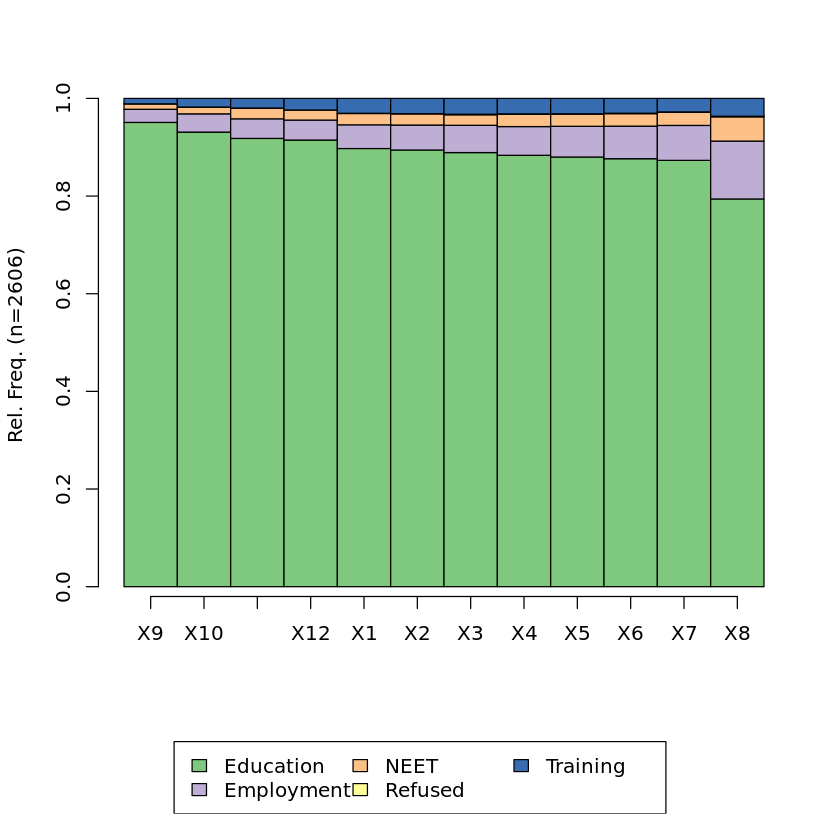

In [20]:
seqdplot(destinations_seq.seq)

In [21]:
# compute pairwise optimal matching (OM) distances 
destinations_seq.om <- seqdist(destinations_seq.seq, method = "OM", indel = 1, with.missing = TRUE, sm = submat)

 [>] including missing values as an additional state

 [>] 2606 sequences with 6 distinct states

 [>] checking 'sm' (size and triangle inequality)

Warning message:
“At least one substitution cost greater than twice the indel cost. Such substitution costs will never be used.”
 [>] 267 distinct  sequences 

 [>] min/max sequence lengths: 1/12

 [>] computing distances using the OM metric

 [>] elapsed time: 0.684 secs



In [22]:
# Check dimensions of distance matrix
#dim(destinations_seq.om)

## Find optimal K - on sample only

In [23]:
# Partitioning Around Medoids (PAM) algorithm for k target groups

In [24]:
install.packages("factoextra")
library(factoextra)

Installing package into ‘/home/jupyter/.R/library’
(as ‘lib’ is unspecified)

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



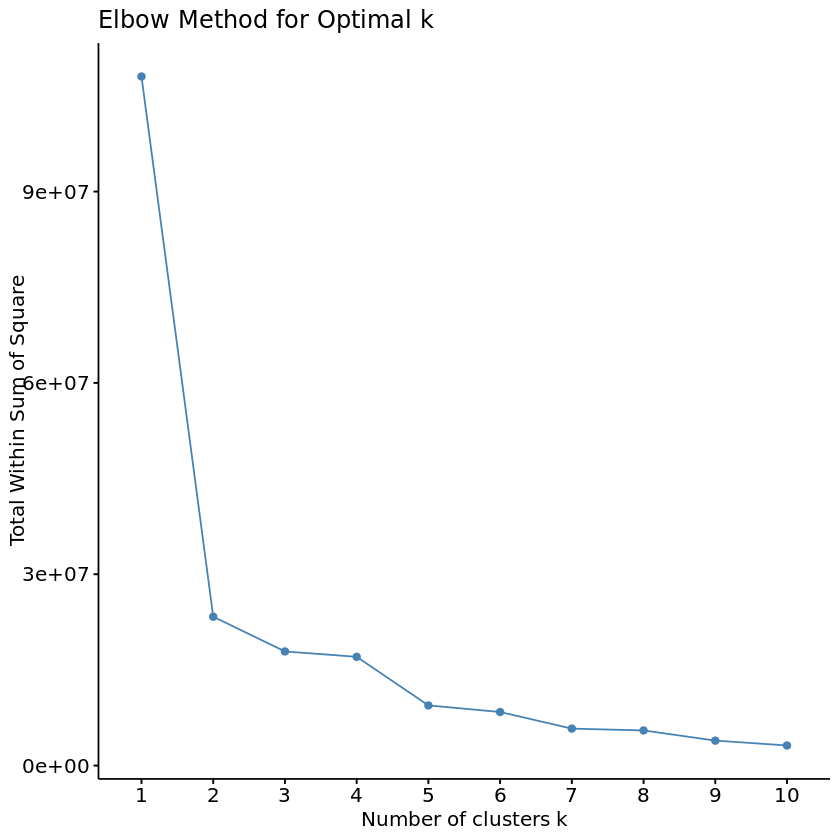

In [25]:
# Compute and plot WCSS (Within-cluster sum of squares) for different k
fviz_nbclust(destinations_seq.om, pam, method = "wss") +
  ggtitle("Elbow Method for Optimal k")

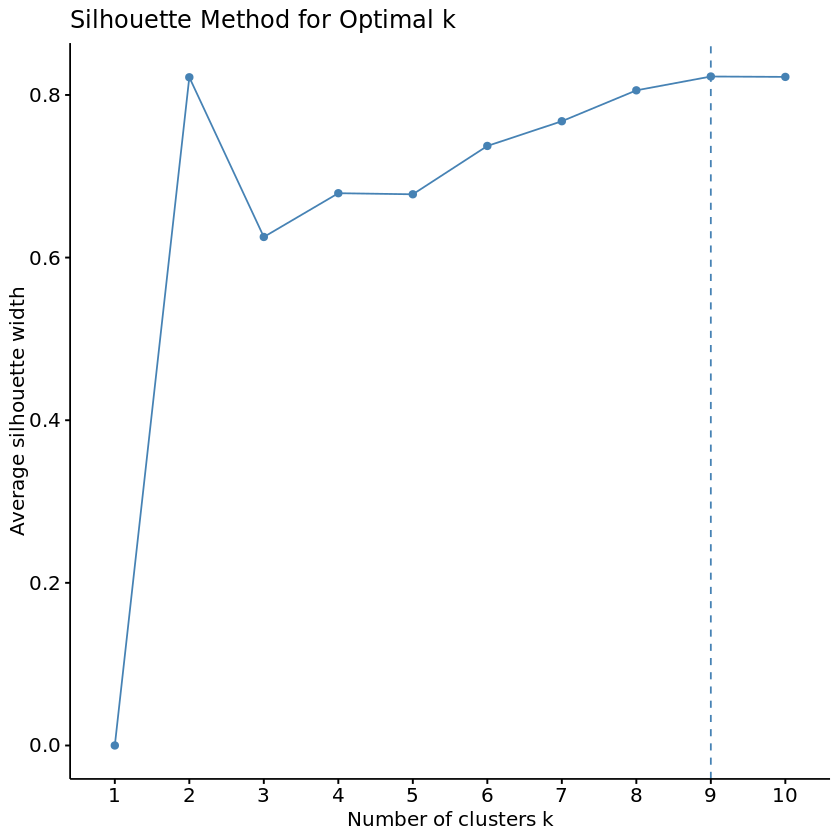

In [26]:
# Silhouette method to find optimal k (A higher average silhouette width suggests a better-defined clustering)
fviz_nbclust(destinations_seq.om, pam, method = "silhouette") +
  ggtitle("Silhouette Method for Optimal k")

## Straight PAM clustering - cannot compute!

In [ ]:

pam_cluster <- pam(destinations_seq.om, k = 4)


In [44]:
# View basic summary of the clustering
#summary(pam_cluster)

In [112]:
# Add cluster labels to the original data
destinations_sample$cluster <- pam_cluster$clustering

In [113]:
# Count how many records in each cluster
table(destinations_seq_17$cluster)


   1    2    3    4 
2326 1335  456  221 

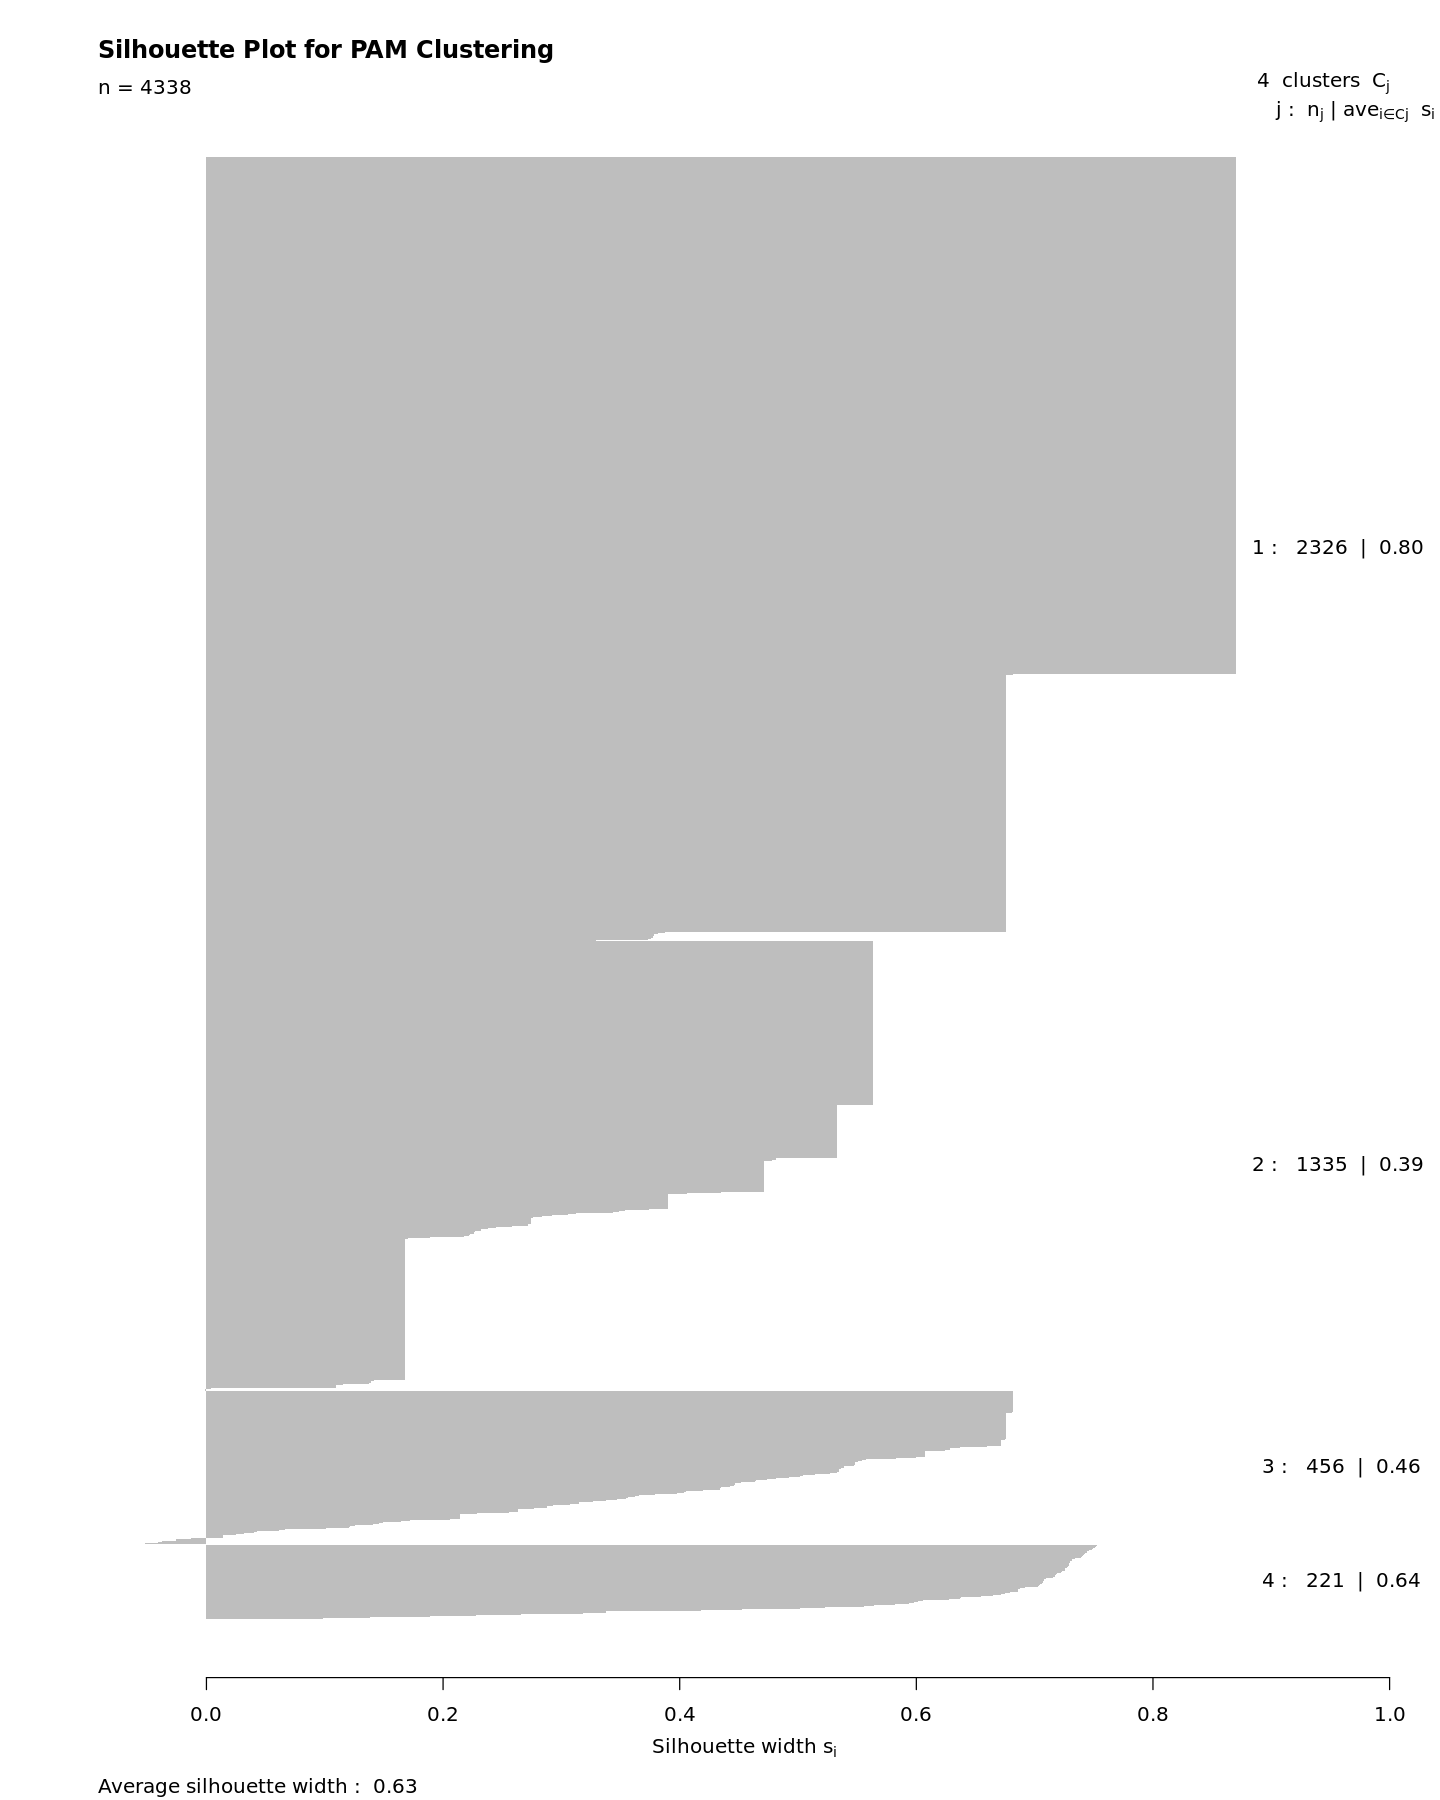

In [114]:
# Plot silhouette to evaluate cluster quality
silhouette_plot <- silhouette(pam_cluster)
plot(silhouette_plot, main = "Silhouette Plot for PAM Clustering")

## A higher silhouette width indicates that the clustering is well-defined.

In [115]:
# Summarize cluster characteristics
cluster_summary <- destinations_seq_17 |>
    select(-person_id) |>
  group_by(cluster) |>
  summarise(across(everything(), ~paste(unique(.), collapse = ", ")))

In [116]:
write.csv(cluster_summary, "data/cluster_summary_destinations_seq_17.csv", row.names = FALSE)

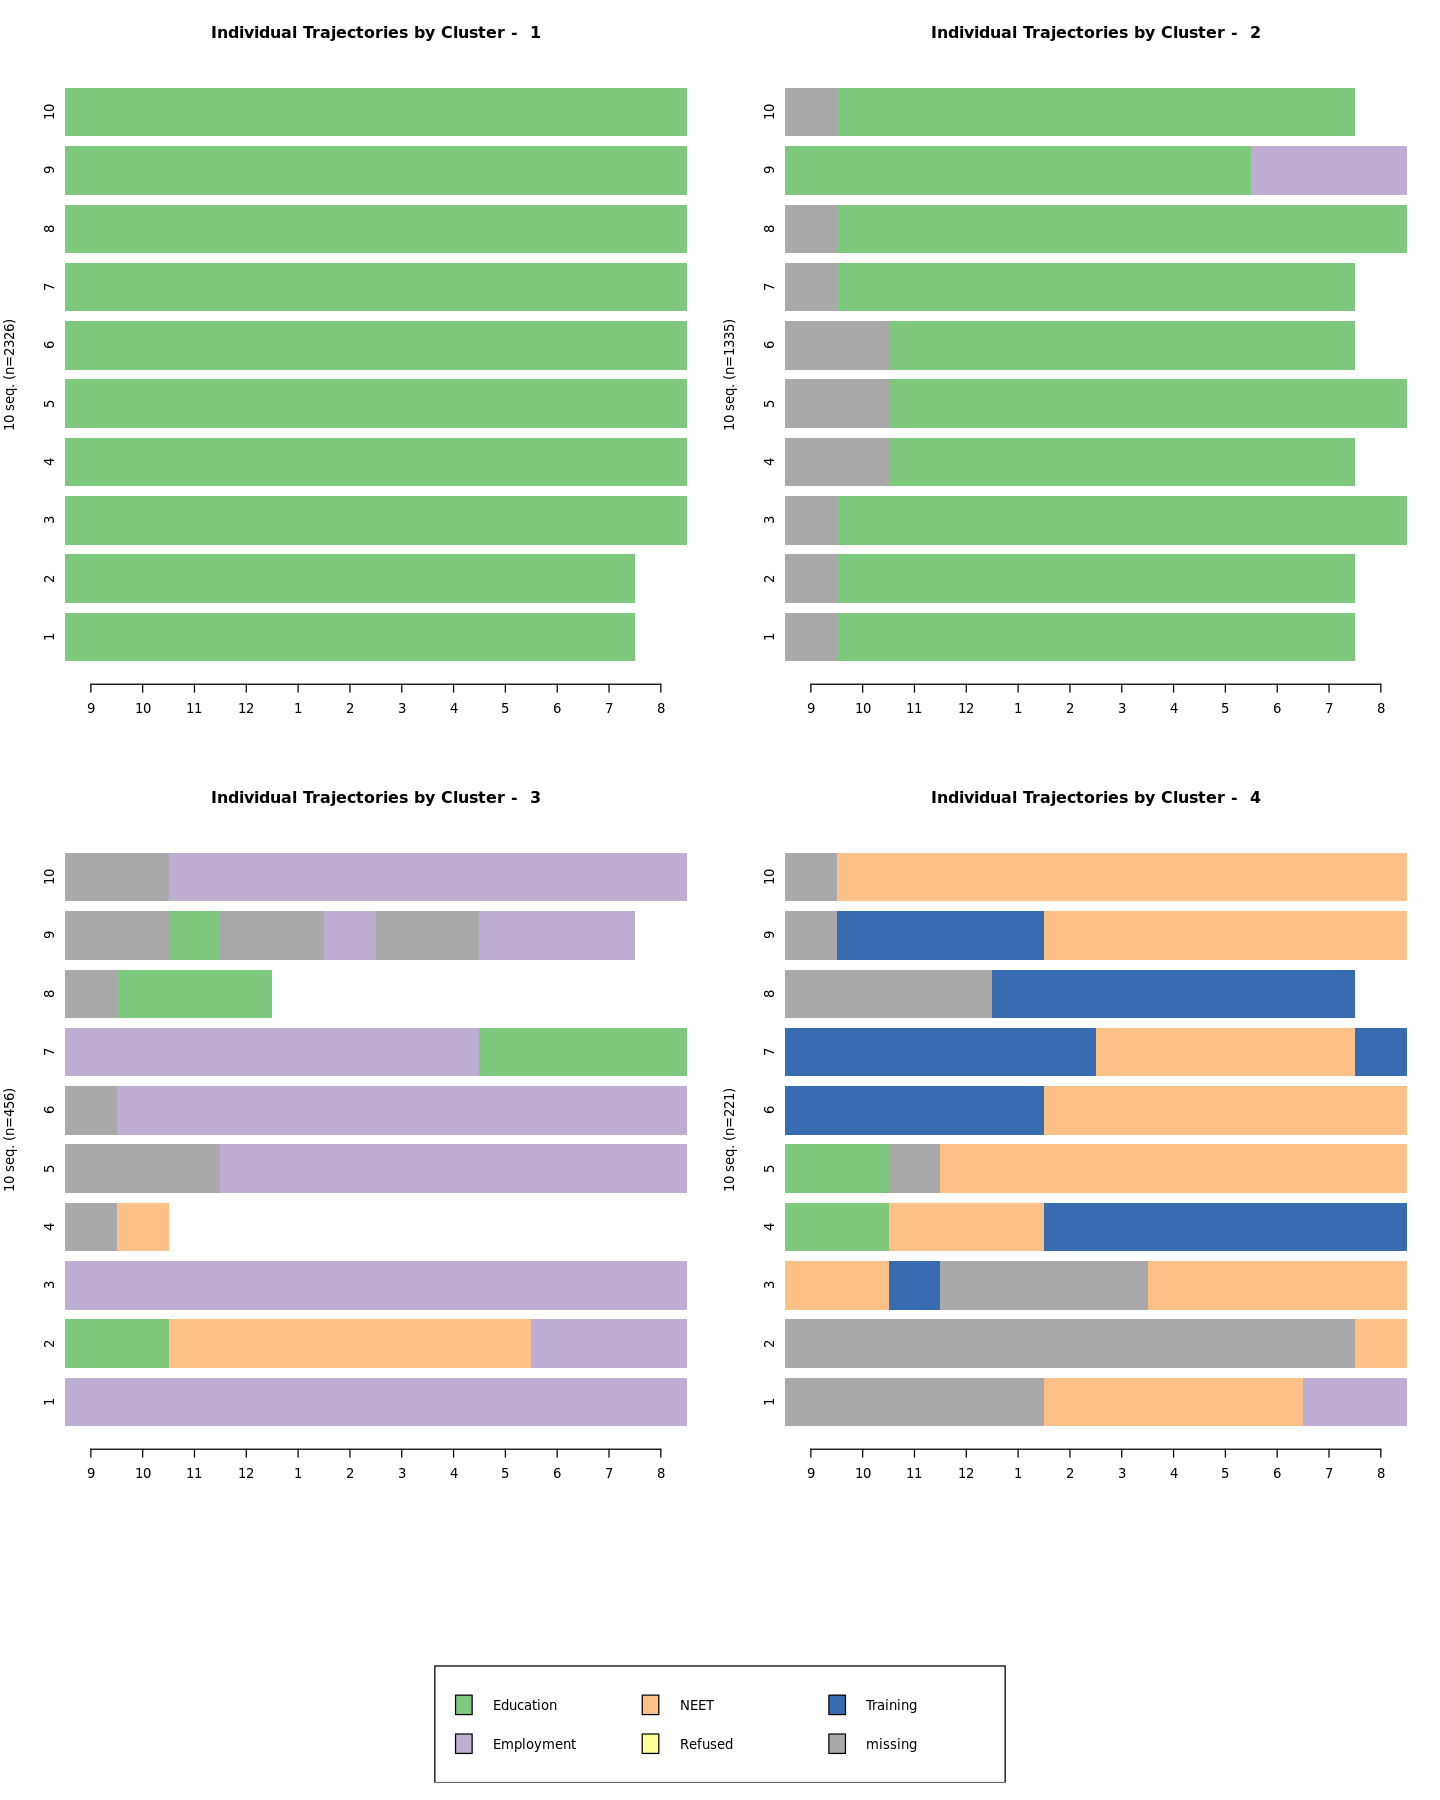

In [117]:
# Plot individual sequences per cluster
options(repr.plot.width = 12, repr.plot.height = 15)

seqiplot(destinations_seq.seq, group = destinations_seq_17$cluster, 
         border = NA, with.legend = TRUE, main = "Individual Trajectories by Cluster")

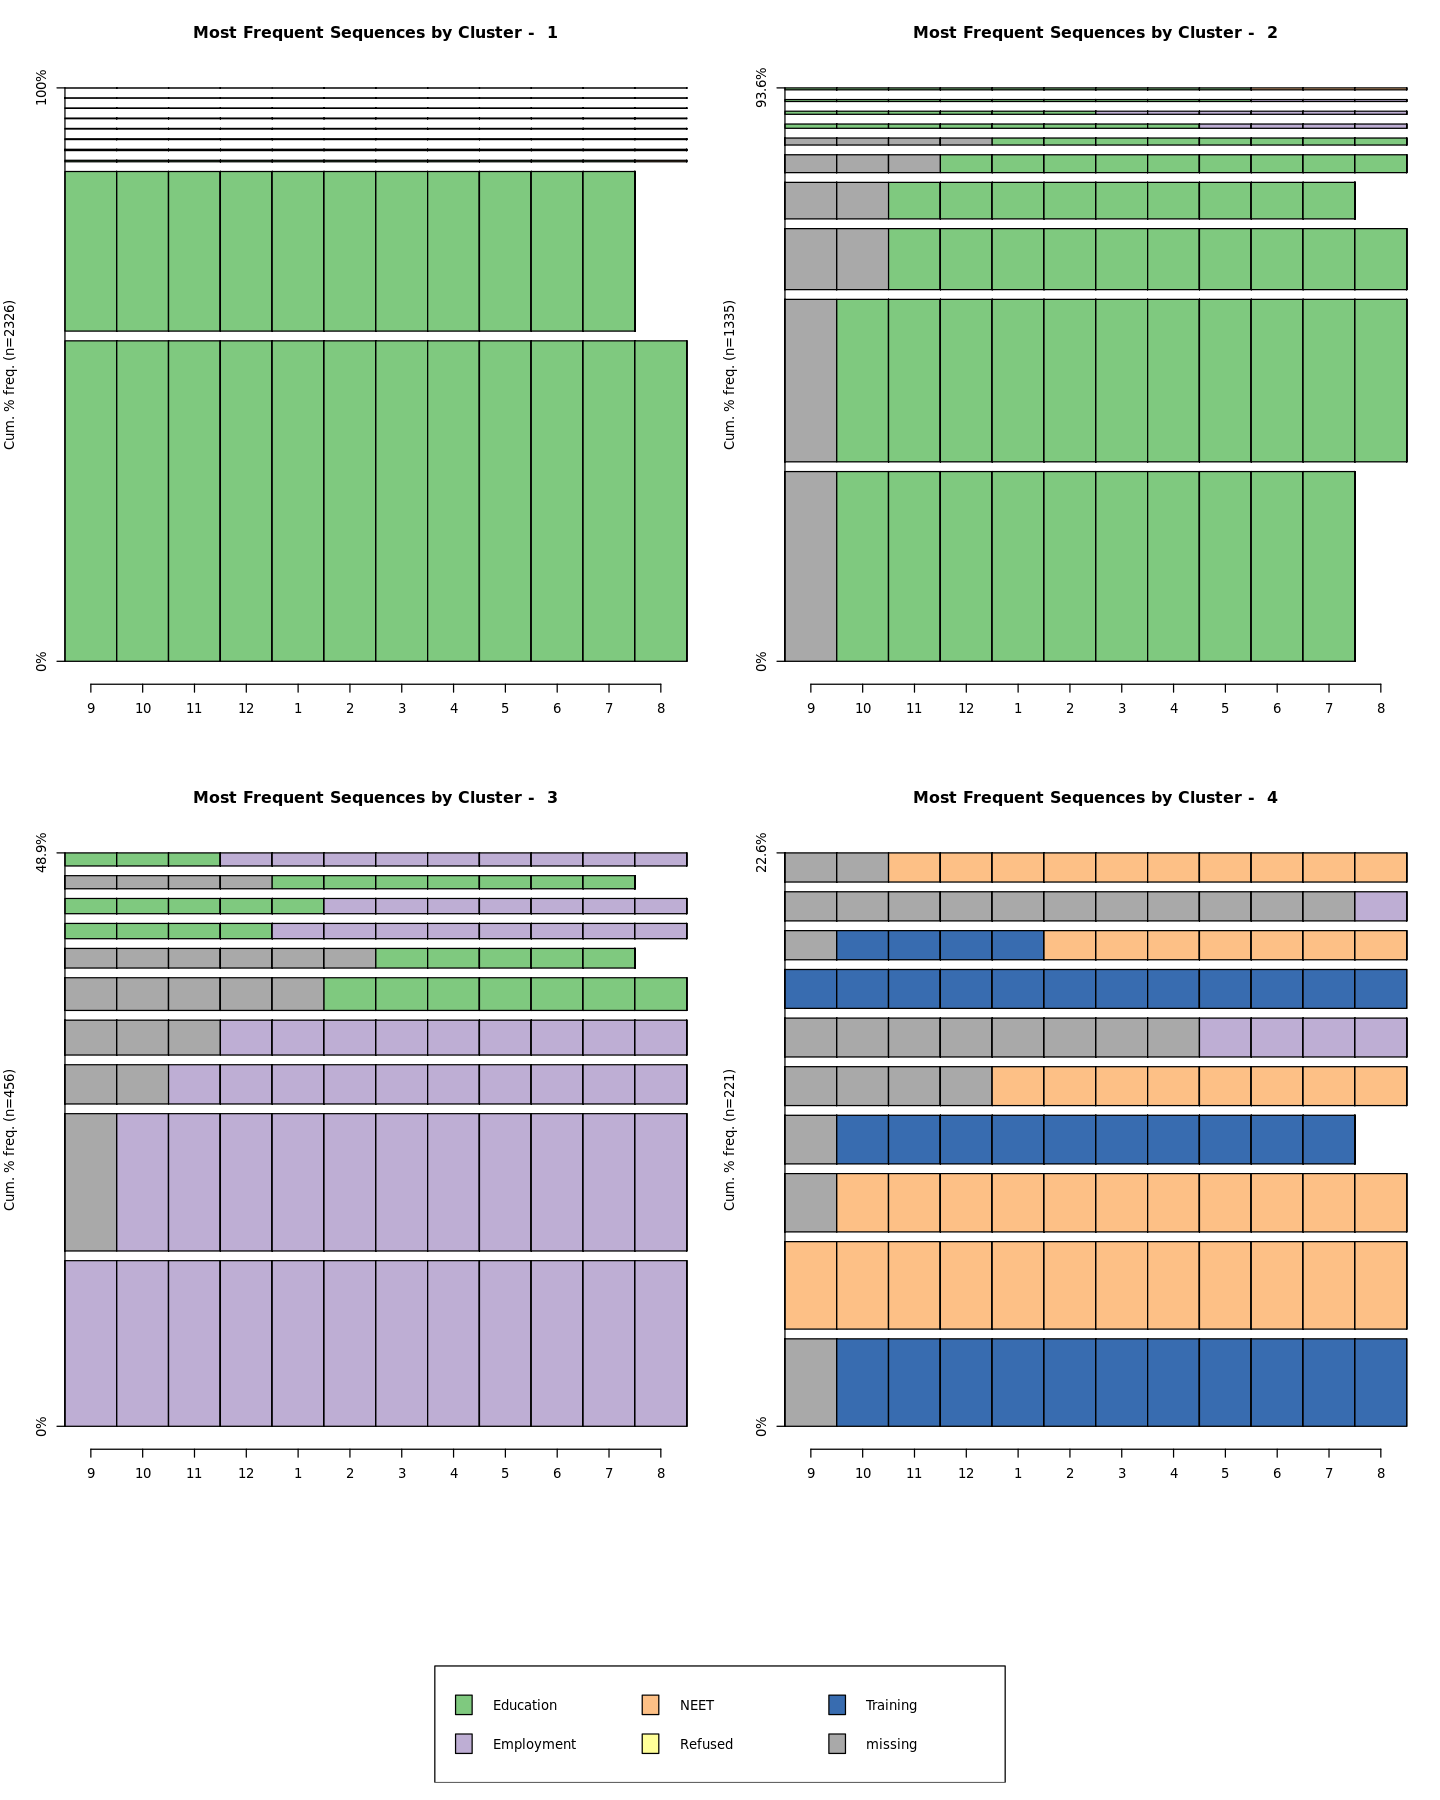

In [118]:
# Plot most frequent sequences per cluster
seqfplot(destinations_seq.seq, group = destinations_seq_17$cluster, 
         with.legend = TRUE, main = "Most Frequent Sequences by Cluster")

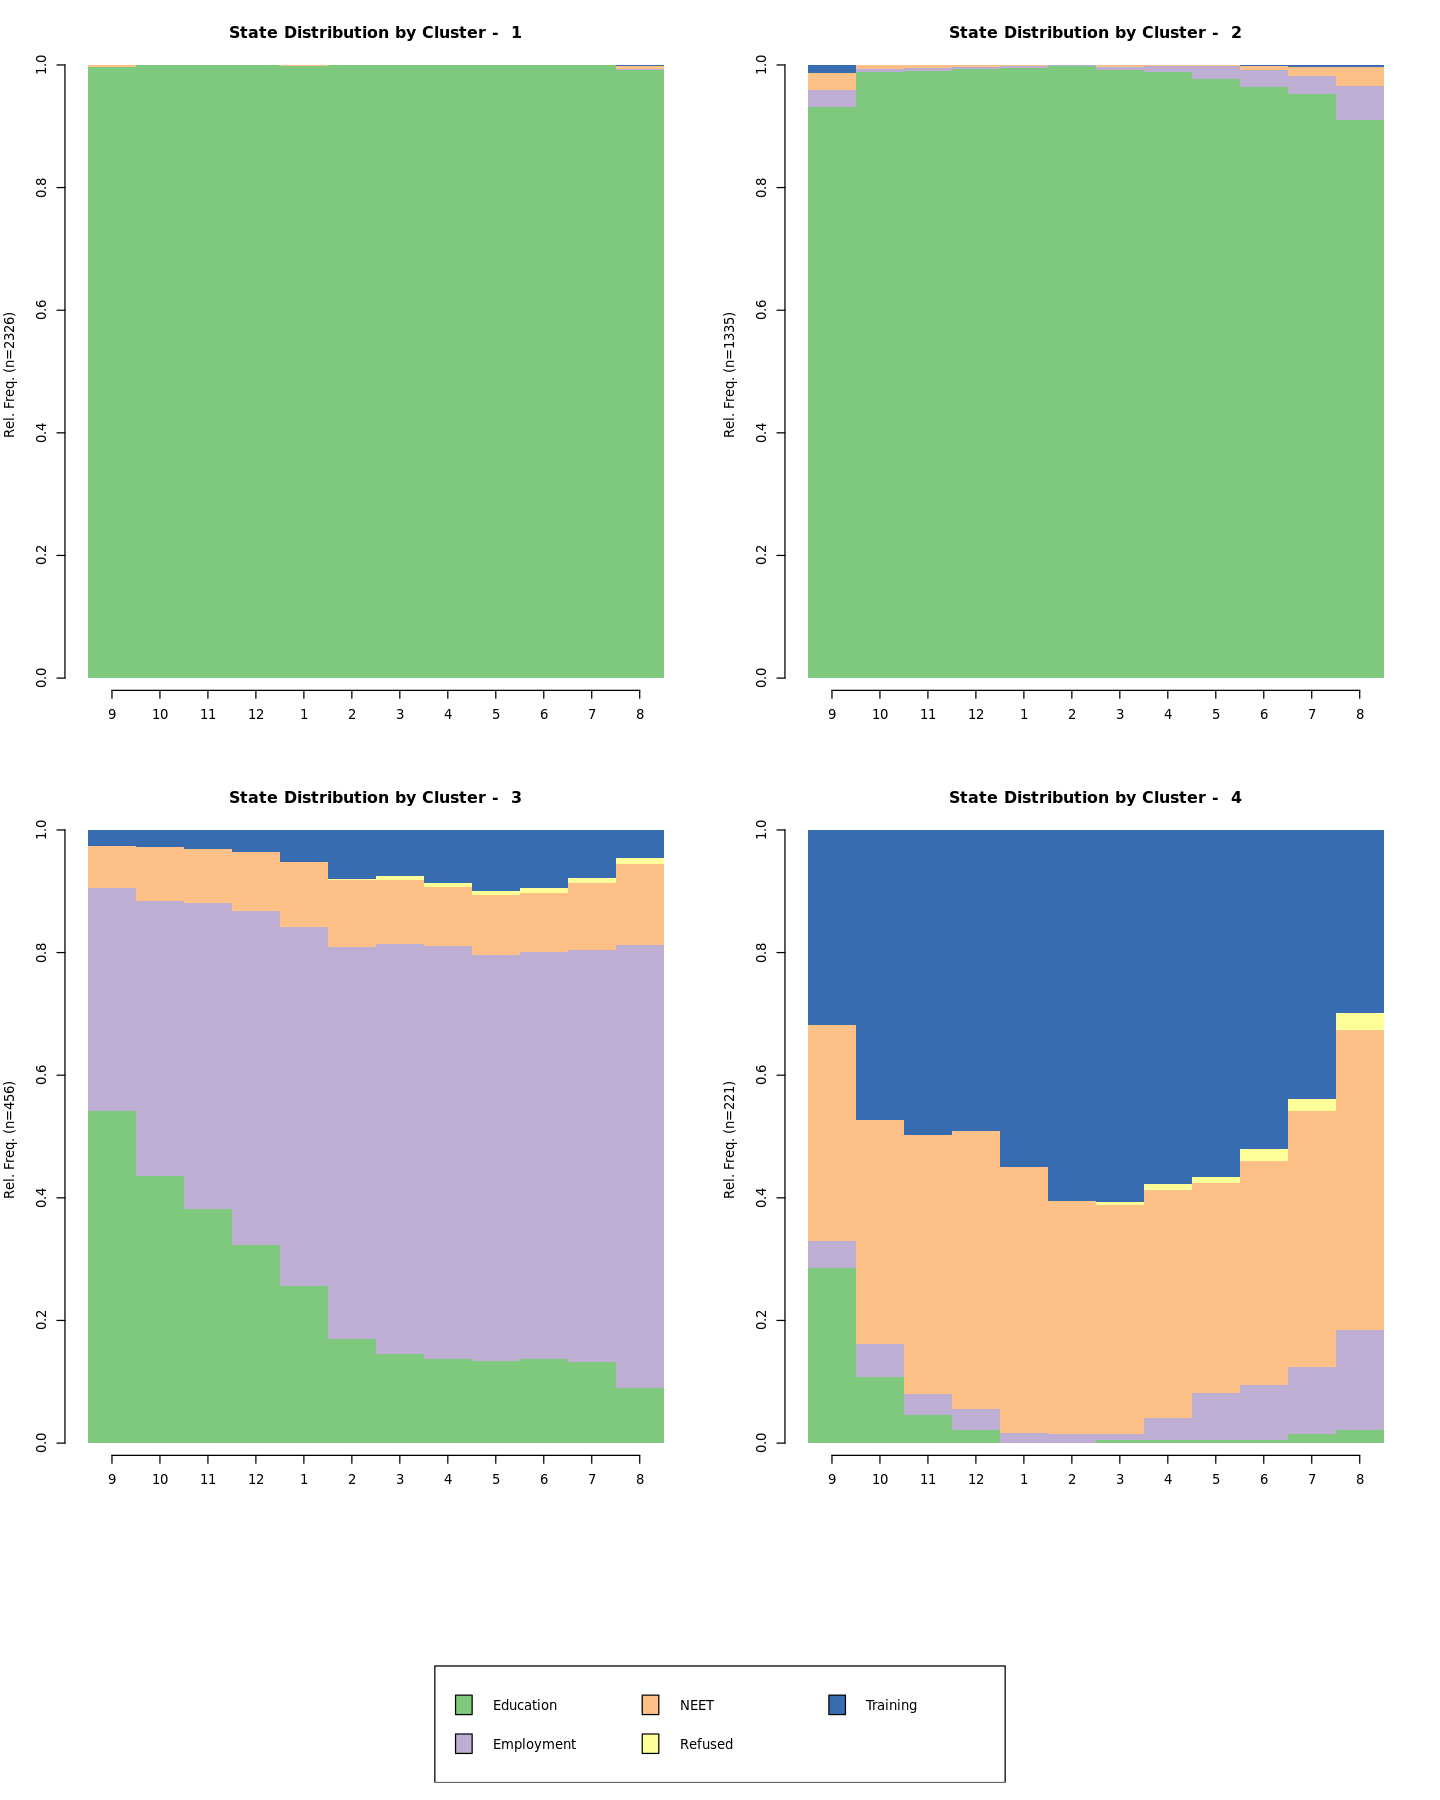

In [119]:
# Plot state distribution per cluster
seqdplot(destinations_seq.seq, group = destinations_seq_17$cluster, 
         with.legend = TRUE, border = NA, main = "State Distribution by Cluster")

## CLARA

To handle large datasets that are too big for PAM (Partitioning Around Medoids), you can use CLARA (Clustering Large Applications). CLARA runs PAM on multiple random subsets of the data and then combines the results to provide an approximation of PAM for large datasets.

#### 2017/18

In [27]:
# create a state sequence object from the status variables (columns 17 to 86)
# with missing TRUE treats missing values as a state
destinations_seq.seq <- seqdef(destinations_seq_17, 4:15, with.missing = TRUE)

 [>] found missing values ('NA') in sequence data

 [>] preparing 8686 sequences

 [>] coding void elements with '%' and missing values with '*'

 [>] 5 distinct states appear in the data: 

     1 = Education

     2 = Employment

     3 = NEET

     4 = Refused

     5 = Training

 [>] state coding:

       [alphabet]  [label]    [long label] 

     1  Education   Education  Education

     2  Employment  Employment Employment

     3  NEET        NEET       NEET

     4  Refused     Refused    Refused

     5  Training    Training   Training

 [>] 8686 sequences in the data set

 [>] min/max sequence length: 1/12



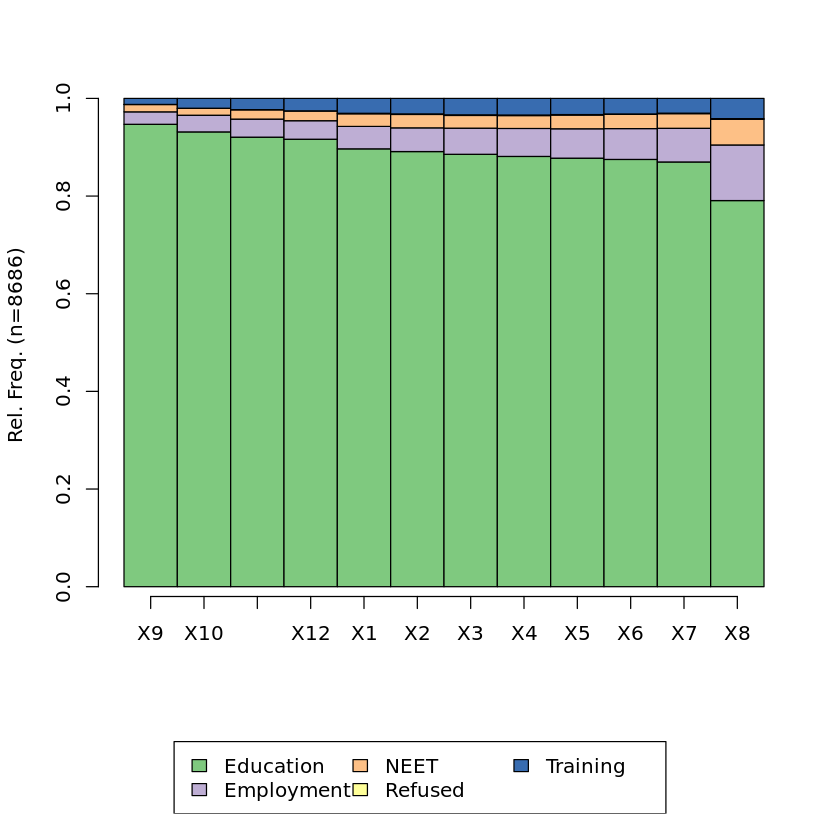

In [28]:
seqdplot(destinations_seq.seq)

In [29]:
# compute pairwise optimal matching (OM) distances 
destinations_seq.om <- seqdist(destinations_seq.seq, method = "OM", indel = 1, with.missing = TRUE, sm = submat)

 [>] including missing values as an additional state

 [>] 8686 sequences with 6 distinct states

 [>] checking 'sm' (size and triangle inequality)

Warning message:
“At least one substitution cost greater than twice the indel cost. Such substitution costs will never be used.”
 [>] 651 distinct  sequences 

 [>] min/max sequence lengths: 1/12

 [>] computing distances using the OM metric

 [>] elapsed time: 3.403 secs



In [30]:
# Run CLARA with 4 clusters and 50 samples
set.seed(123)  # For reproducibility
clara_cluster <- clara(
  destinations_seq.om,   # Dissimilarity matrix from seqdist()
  k = 9,                 # Number of clusters
  samples = 50,          # Number of random samples to draw
  pamLike = TRUE         # Uses PAM for each sample
)

In [31]:
# Check the cluster assignment
head(clara_cluster$clustering)

1 2 3 4 5 6 
1 1 2 1 3 1

In [32]:
clara_cluster$clusinfo

size,max_diss,av_diss,isolation
3049,131.38112,1.193754,1.4361381
1116,200.33472,6.274315,2.2273166
1840,93.18798,2.774774,1.0186456
307,396.22216,233.501849,1.0291797
947,76.86352,3.150302,0.8545667
482,212.97887,82.174050,1.2282020
455,356.54032,142.787072,0.9261069
127,392.83075,211.219864,0.5302398
363,353.88981,190.924651,0.9818990


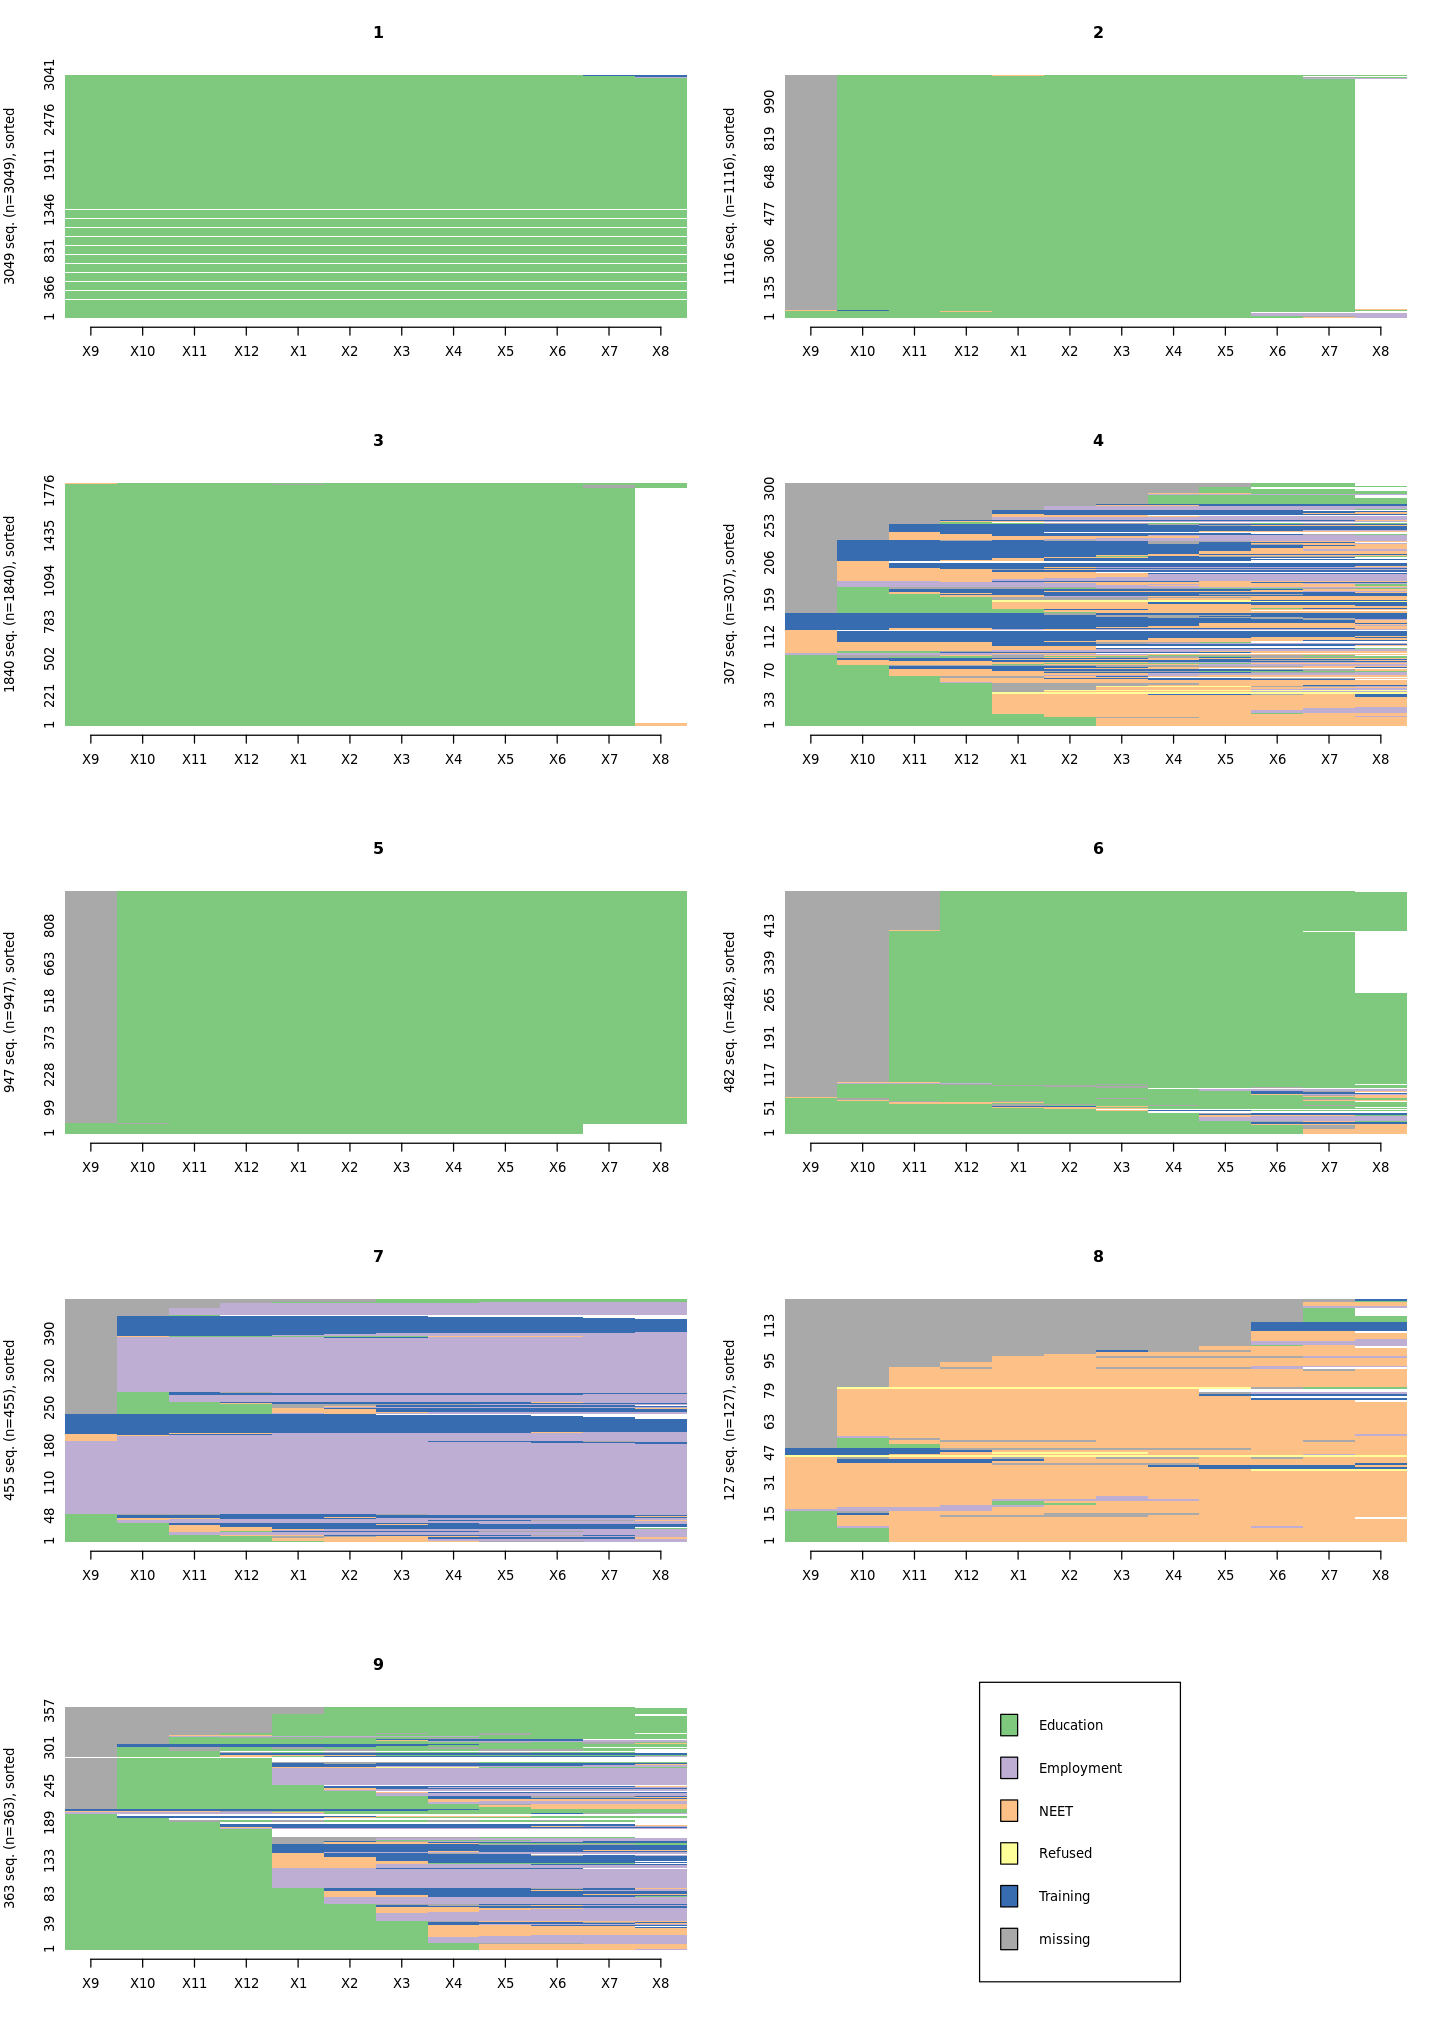

In [33]:
options(repr.plot.width = 12, repr.plot.height = 17)
# Plot individual trajectories per cluster
seqIplot(destinations_seq.seq, group = clara_cluster$clustering, sortv = "from.start")

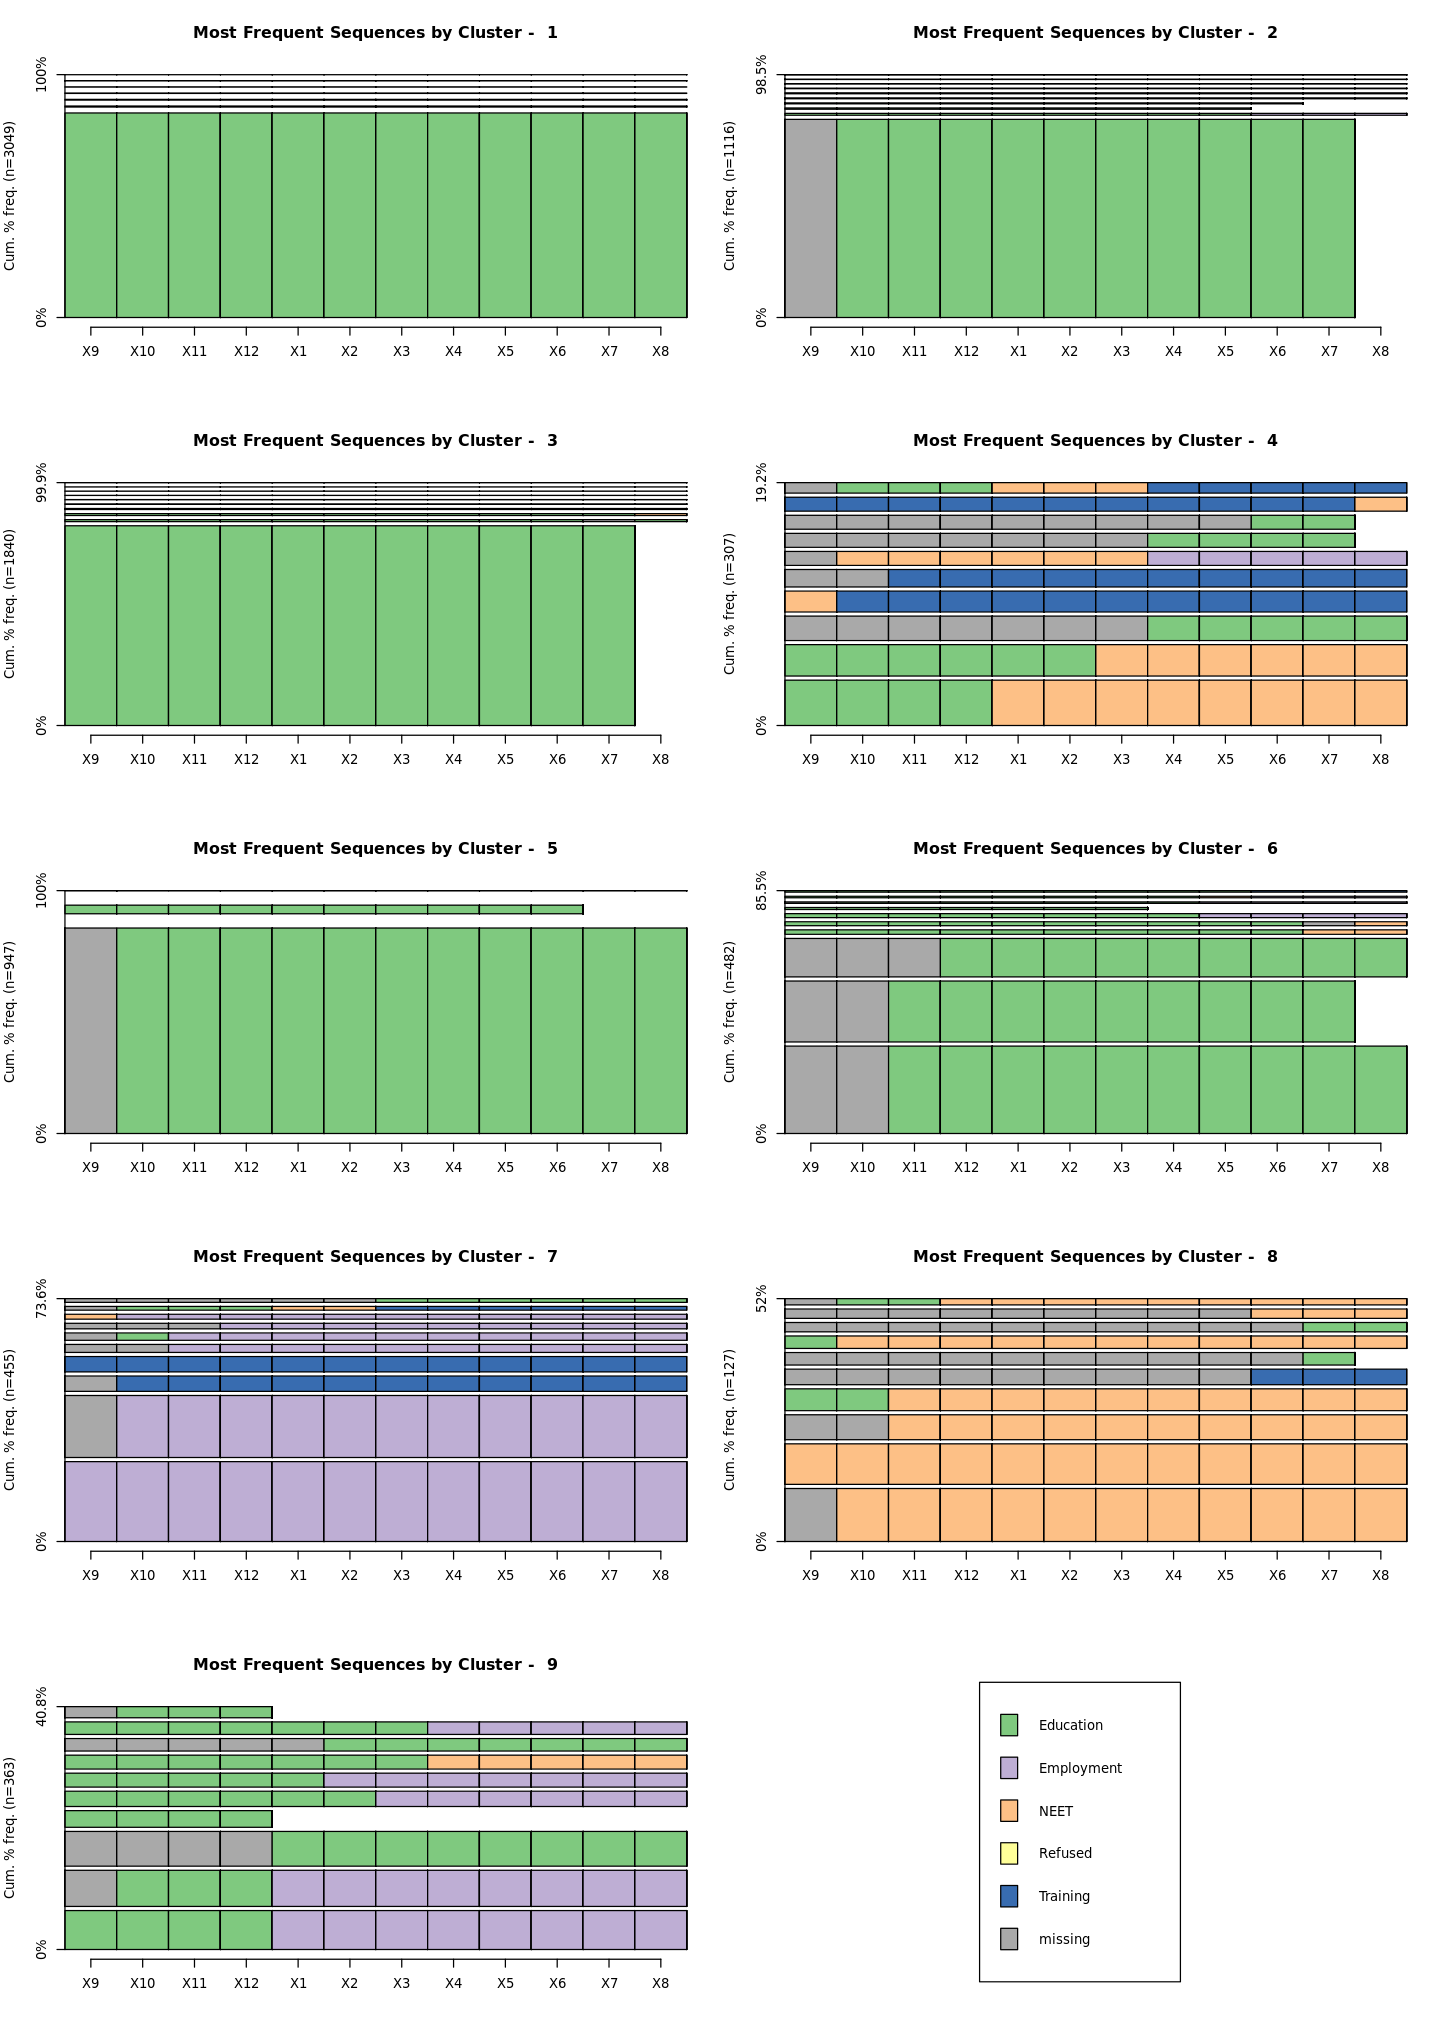

In [35]:
# Plot most frequent sequences per cluster
seqfplot(destinations_seq.seq, group = clara_cluster$clustering, 
         with.legend = TRUE, main = "Most Frequent Sequences by Cluster")

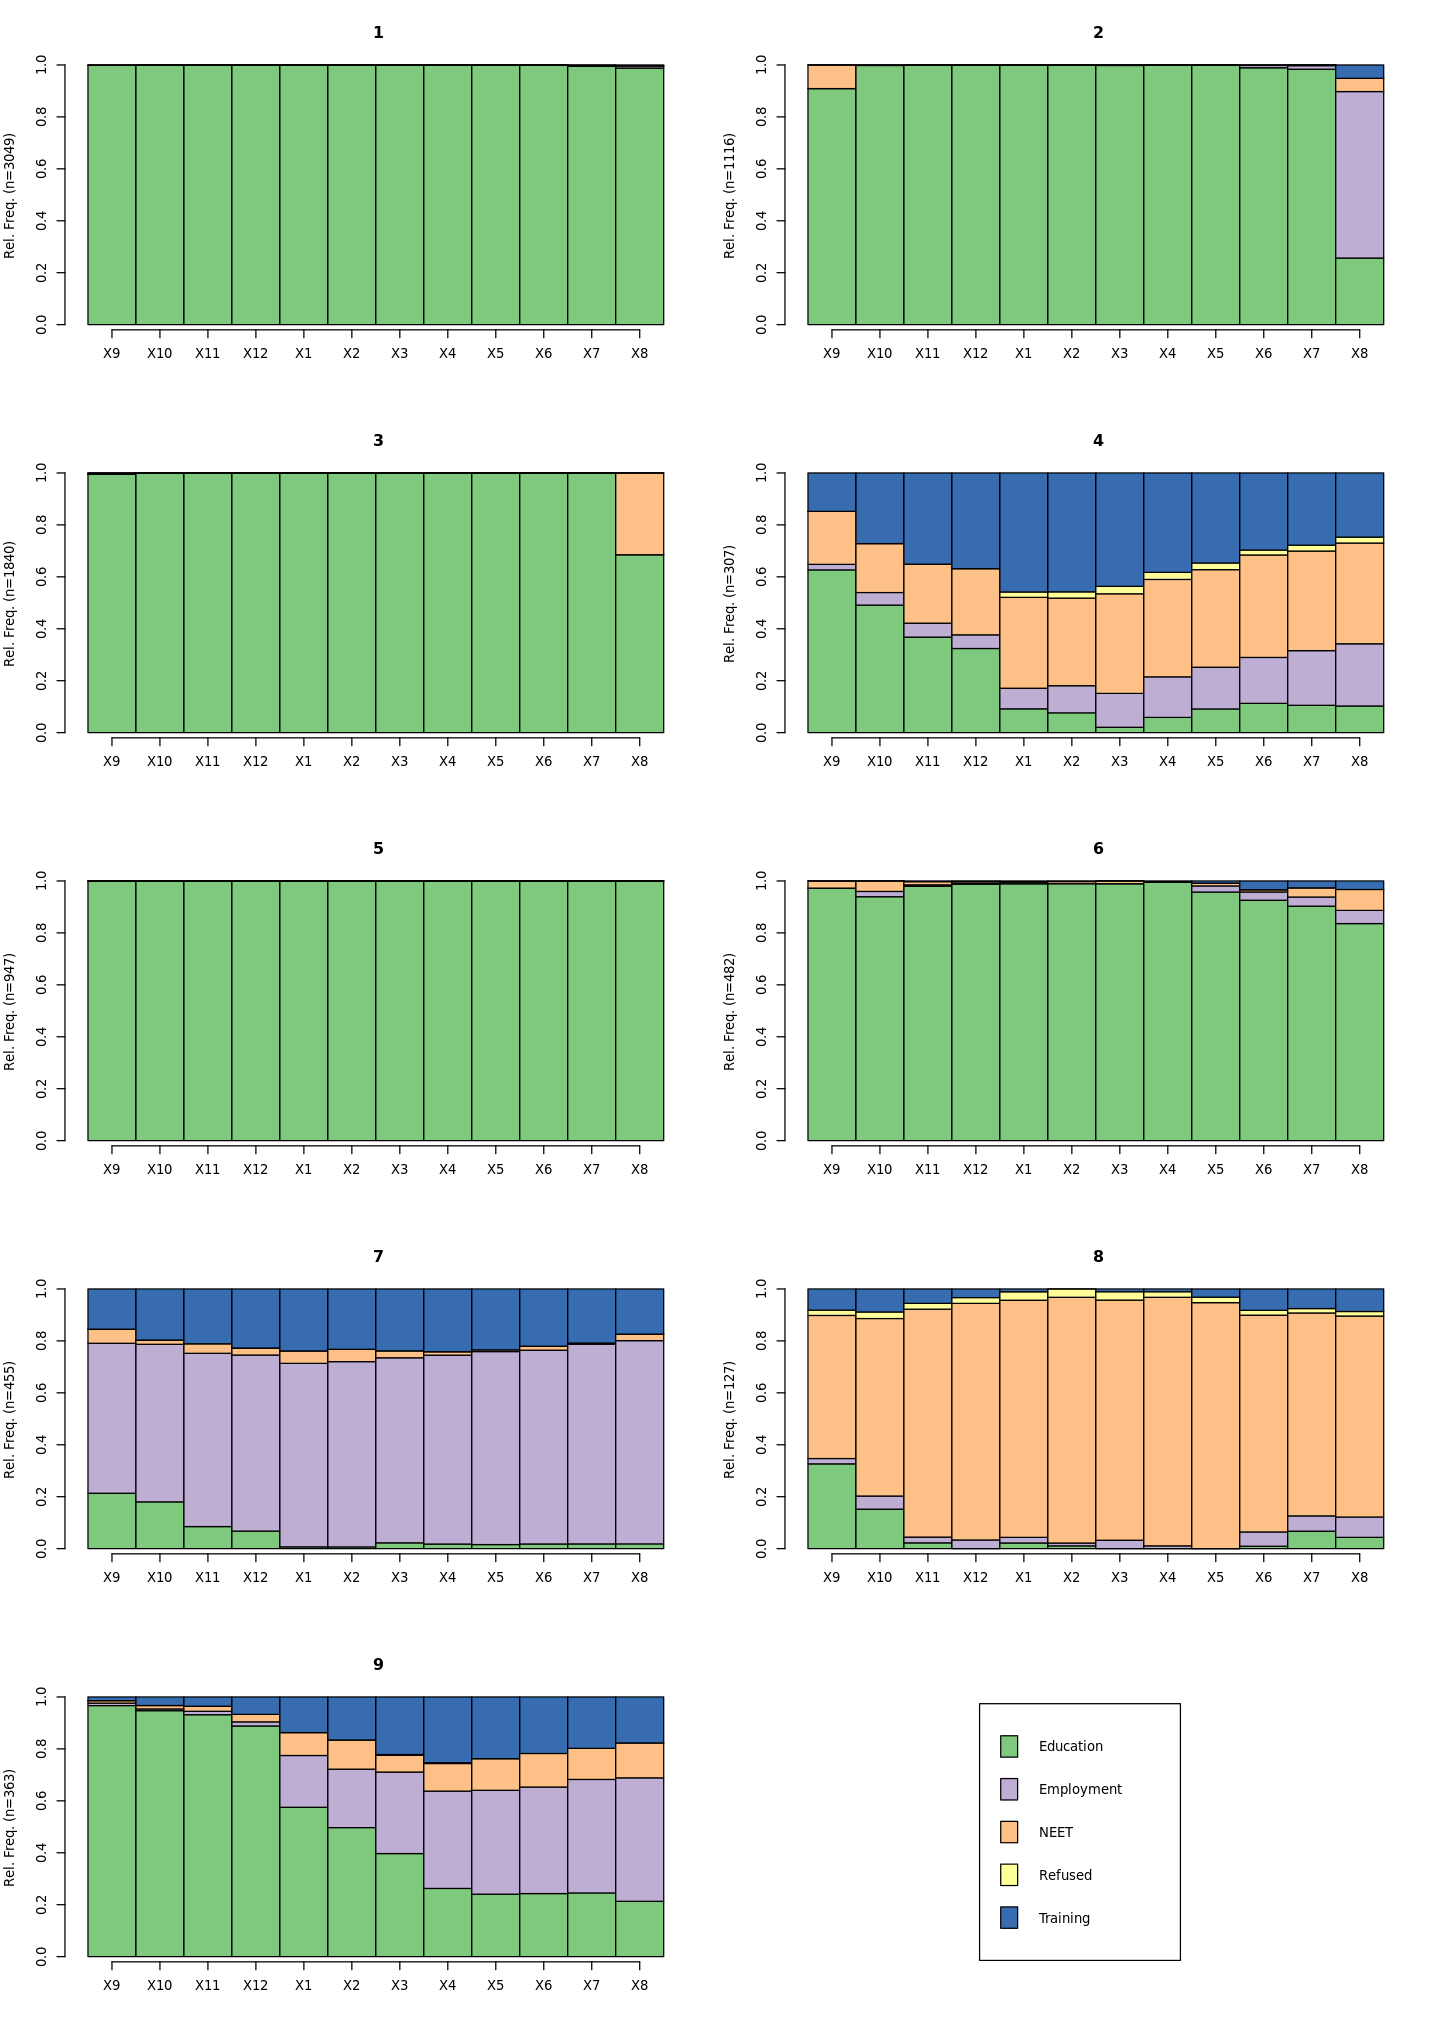

In [34]:
# Plot state distribution per cluster
seqdplot(destinations_seq.seq, group = clara_cluster$clustering)

In [36]:
# Get medoids (representative sequences for each cluster)
clara_cluster$medoids

,1,2,3,4,5,6,7,8,9,10,⋯,8677,8678,8679,8680,8681,8682,8683,8684,8685,8686
8686,0,0,3,0,1,0,0,0,1,1,⋯,0,6,1,14,4,14,13,1,0,0
6956,3,3,0,3,2,3,3,3,2,2,⋯,3,3,2,11,1,11,11,2,3,3
8661,1,1,2,1,0,1,1,1,0,0,⋯,1,5,0,13,3,13,12,0,1,1
1586,16,16,13,16,15,16,16,16,15,15,⋯,16,12,15,9,12,6,15,15,16,16
8472,2,2,1,2,1,2,2,2,1,1,⋯,2,4,1,12,2,12,11,1,2,2
1846,5,5,2,5,4,5,5,5,4,4,⋯,5,1,4,12,1,11,12,4,5,5
1775,13,13,11,13,12,13,13,13,12,12,⋯,13,13,12,12,12,12,0,12,13,13
6961,24,24,21,24,23,24,24,24,23,23,⋯,24,18,23,20,20,17,22,23,24,24
3864,8,8,7,8,7,8,8,8,7,7,⋯,8,9,7,14,8,12,10,7,8,8


In [37]:
# Get cluster assignments
cluster_labels <- clara_cluster$clustering

In [38]:
# Add cluster assignments to the original dataset
destinations_seq_17$cluster <- cluster_labels

In [39]:
head(destinations_seq_17)

,person_id,NCCIS_ACADYR,Intended_destination,X9,X10,X11,X12,X1,X2,X3,X4,X5,X6,X7,X8,cluster
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,1
2,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,1
3,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA,2
4,0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,1
5,001B7CEB7B4CC529920A0B9F5B83D1AC0019E5DC44B3FBB3CEF665C331C0C3B6,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA,3
6,001E539C263734CC355646811C93CF85B0C587D2EBA8B0D79290FDE8A75D6267,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,1


In [40]:
write.csv(destinations_seq_17, "data/destinations_seq_17.csv", row.names = FALSE)

#### 2018/19

In [41]:
# create a state sequence object from the status variables (columns 17 to 86)
# with missing TRUE treats missing values as a state
destinations_seq.seq <- seqdef(destinations_seq_18, 4:15, with.missing = TRUE)

 [>] found missing values ('NA') in sequence data

 [>] preparing 8675 sequences

 [>] coding void elements with '%' and missing values with '*'

 [>] 5 distinct states appear in the data: 

     1 = Education

     2 = Employment

     3 = NEET

     4 = Refused

     5 = Training

 [>] state coding:

       [alphabet]  [label]    [long label] 

     1  Education   Education  Education

     2  Employment  Employment Employment

     3  NEET        NEET       NEET

     4  Refused     Refused    Refused

     5  Training    Training   Training

 [>] 8675 sequences in the data set

 [>] min/max sequence length: 1/12



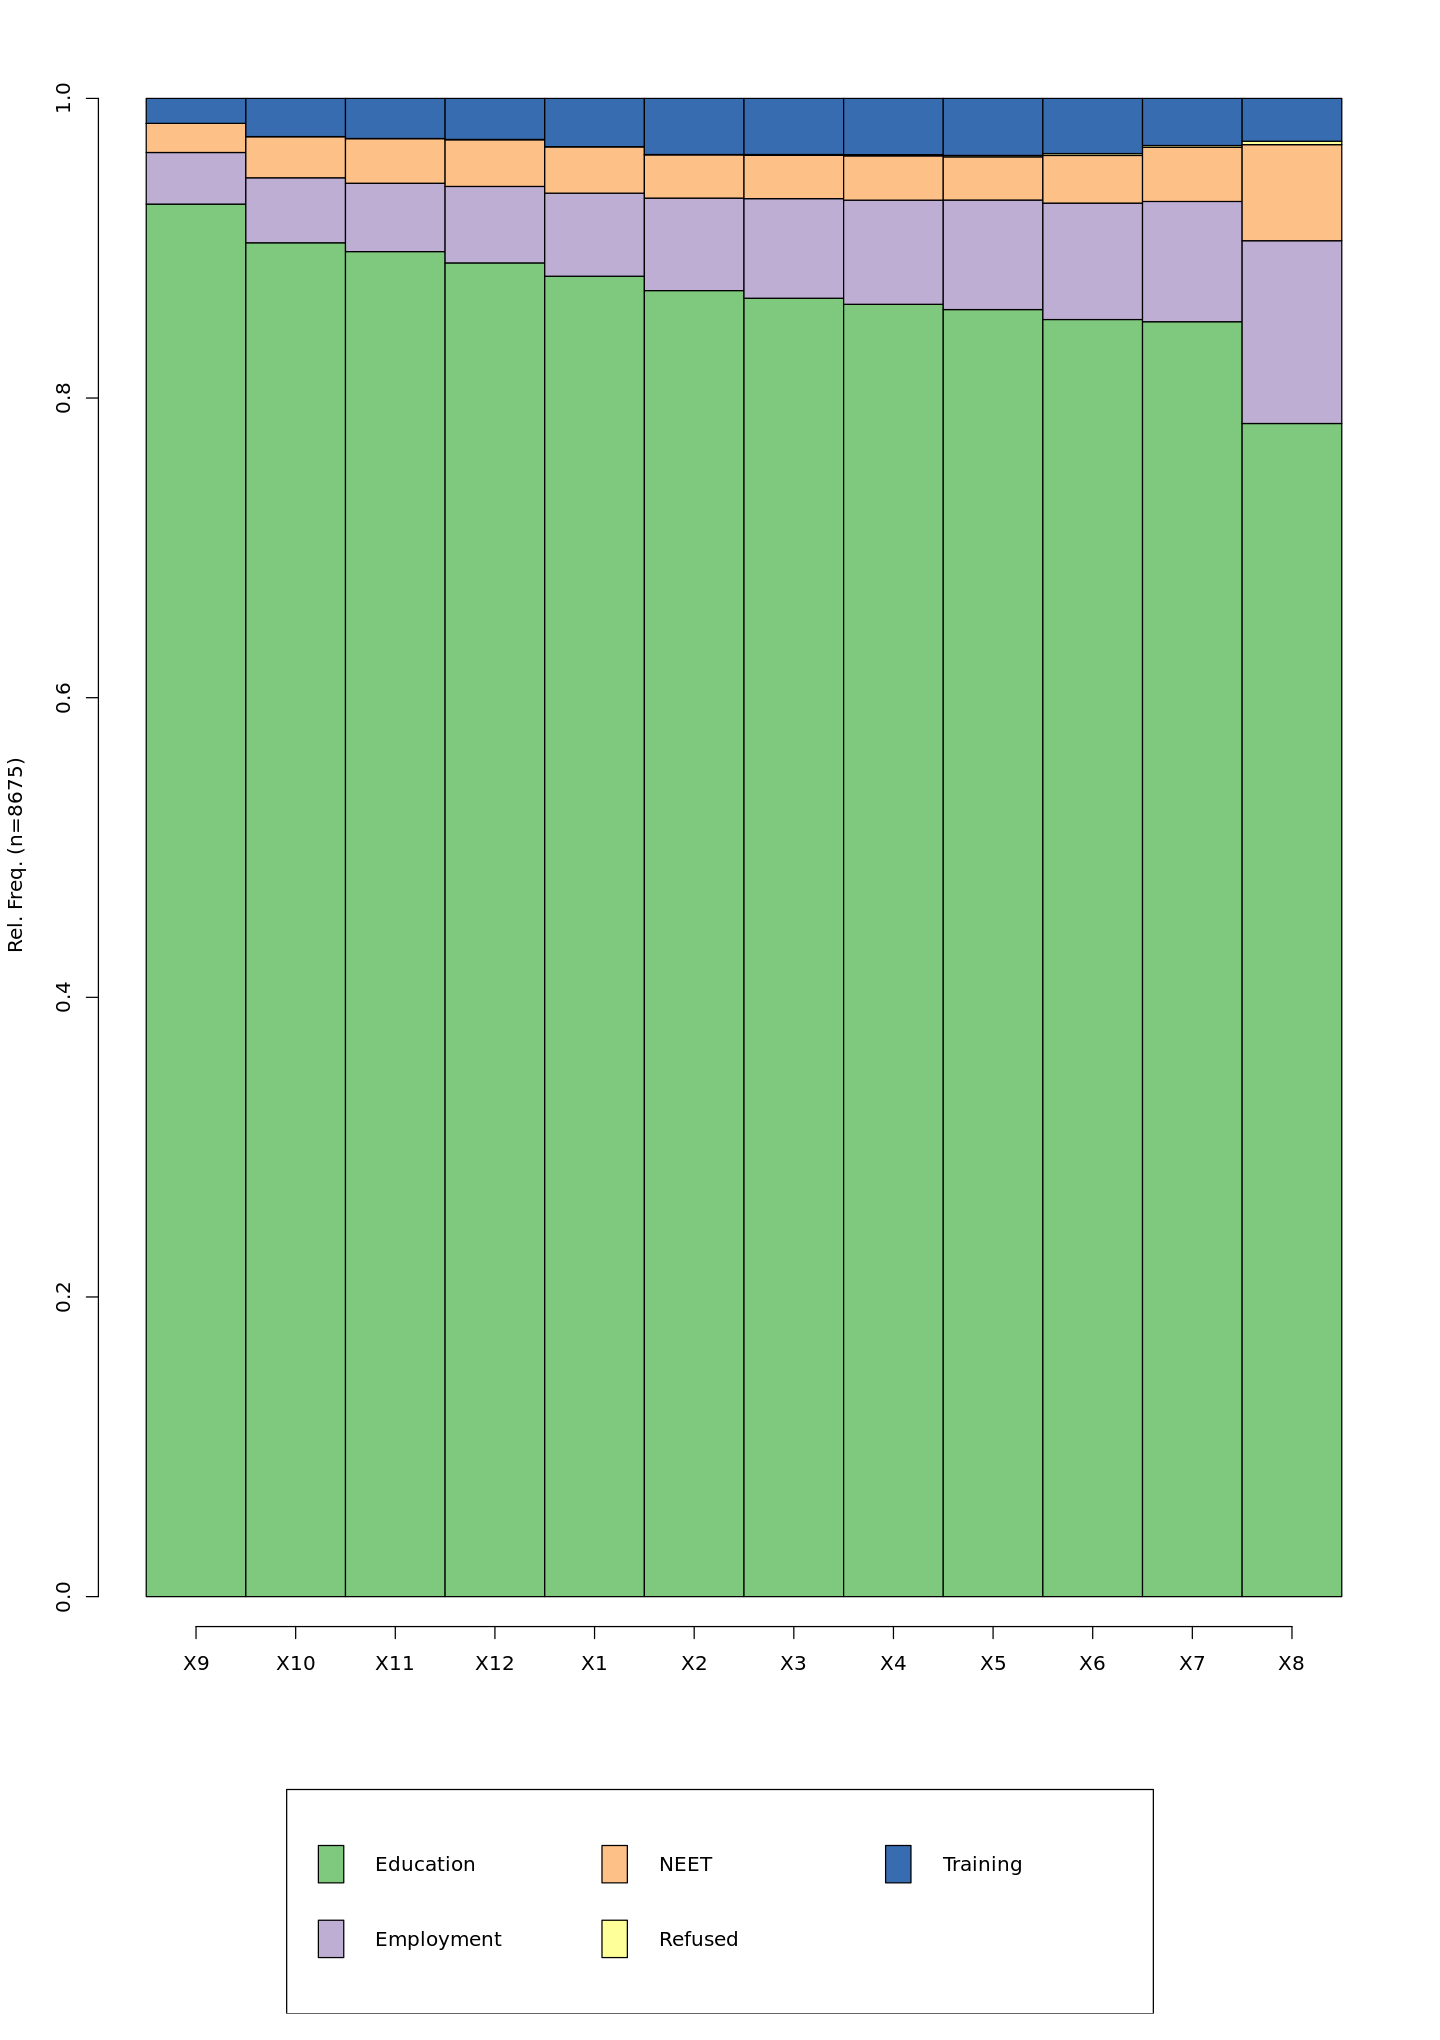

In [42]:
seqdplot(destinations_seq.seq)

In [43]:
# compute pairwise optimal matching (OM) distances 
destinations_seq.om <- seqdist(destinations_seq.seq, method = "OM", indel = 1, with.missing = TRUE, sm = submat)

 [>] including missing values as an additional state

 [>] 8675 sequences with 6 distinct states

 [>] checking 'sm' (size and triangle inequality)

Warning message:
“At least one substitution cost greater than twice the indel cost. Such substitution costs will never be used.”
 [>] 734 distinct  sequences 

 [>] min/max sequence lengths: 1/12

 [>] computing distances using the OM metric

 [>] elapsed time: 1.887 secs



In [44]:
# Run CLARA with 4 clusters and 50 samples
set.seed(123)  # For reproducibility
clara_cluster <- clara(
  destinations_seq.om,   # Dissimilarity matrix from seqdist()
  k = 9,                 # Number of clusters
  samples = 50,          # Number of random samples to draw
  pamLike = TRUE         # Uses PAM for each sample
)

In [45]:
# Check the cluster assignment
head(clara_cluster$clustering)

1 2 3 4 5 6 
1 2 3 4 3 3

In [46]:
clara_cluster$clusinfo

size,max_diss,av_diss,isolation
409,348.40781,209.5568331,0.7831841
3088,61.85467,0.3127638,0.6774349
979,113.32255,0.6623093,1.2613214
823,148.26328,0.7356780,1.6502245
1592,129.28264,3.3509388,1.4159089
701,311.27640,76.8309336,3.3422312
429,419.09903,238.6326777,1.0601307
477,333.62404,118.9175198,0.8439177
177,411.90412,198.4294907,0.5472414


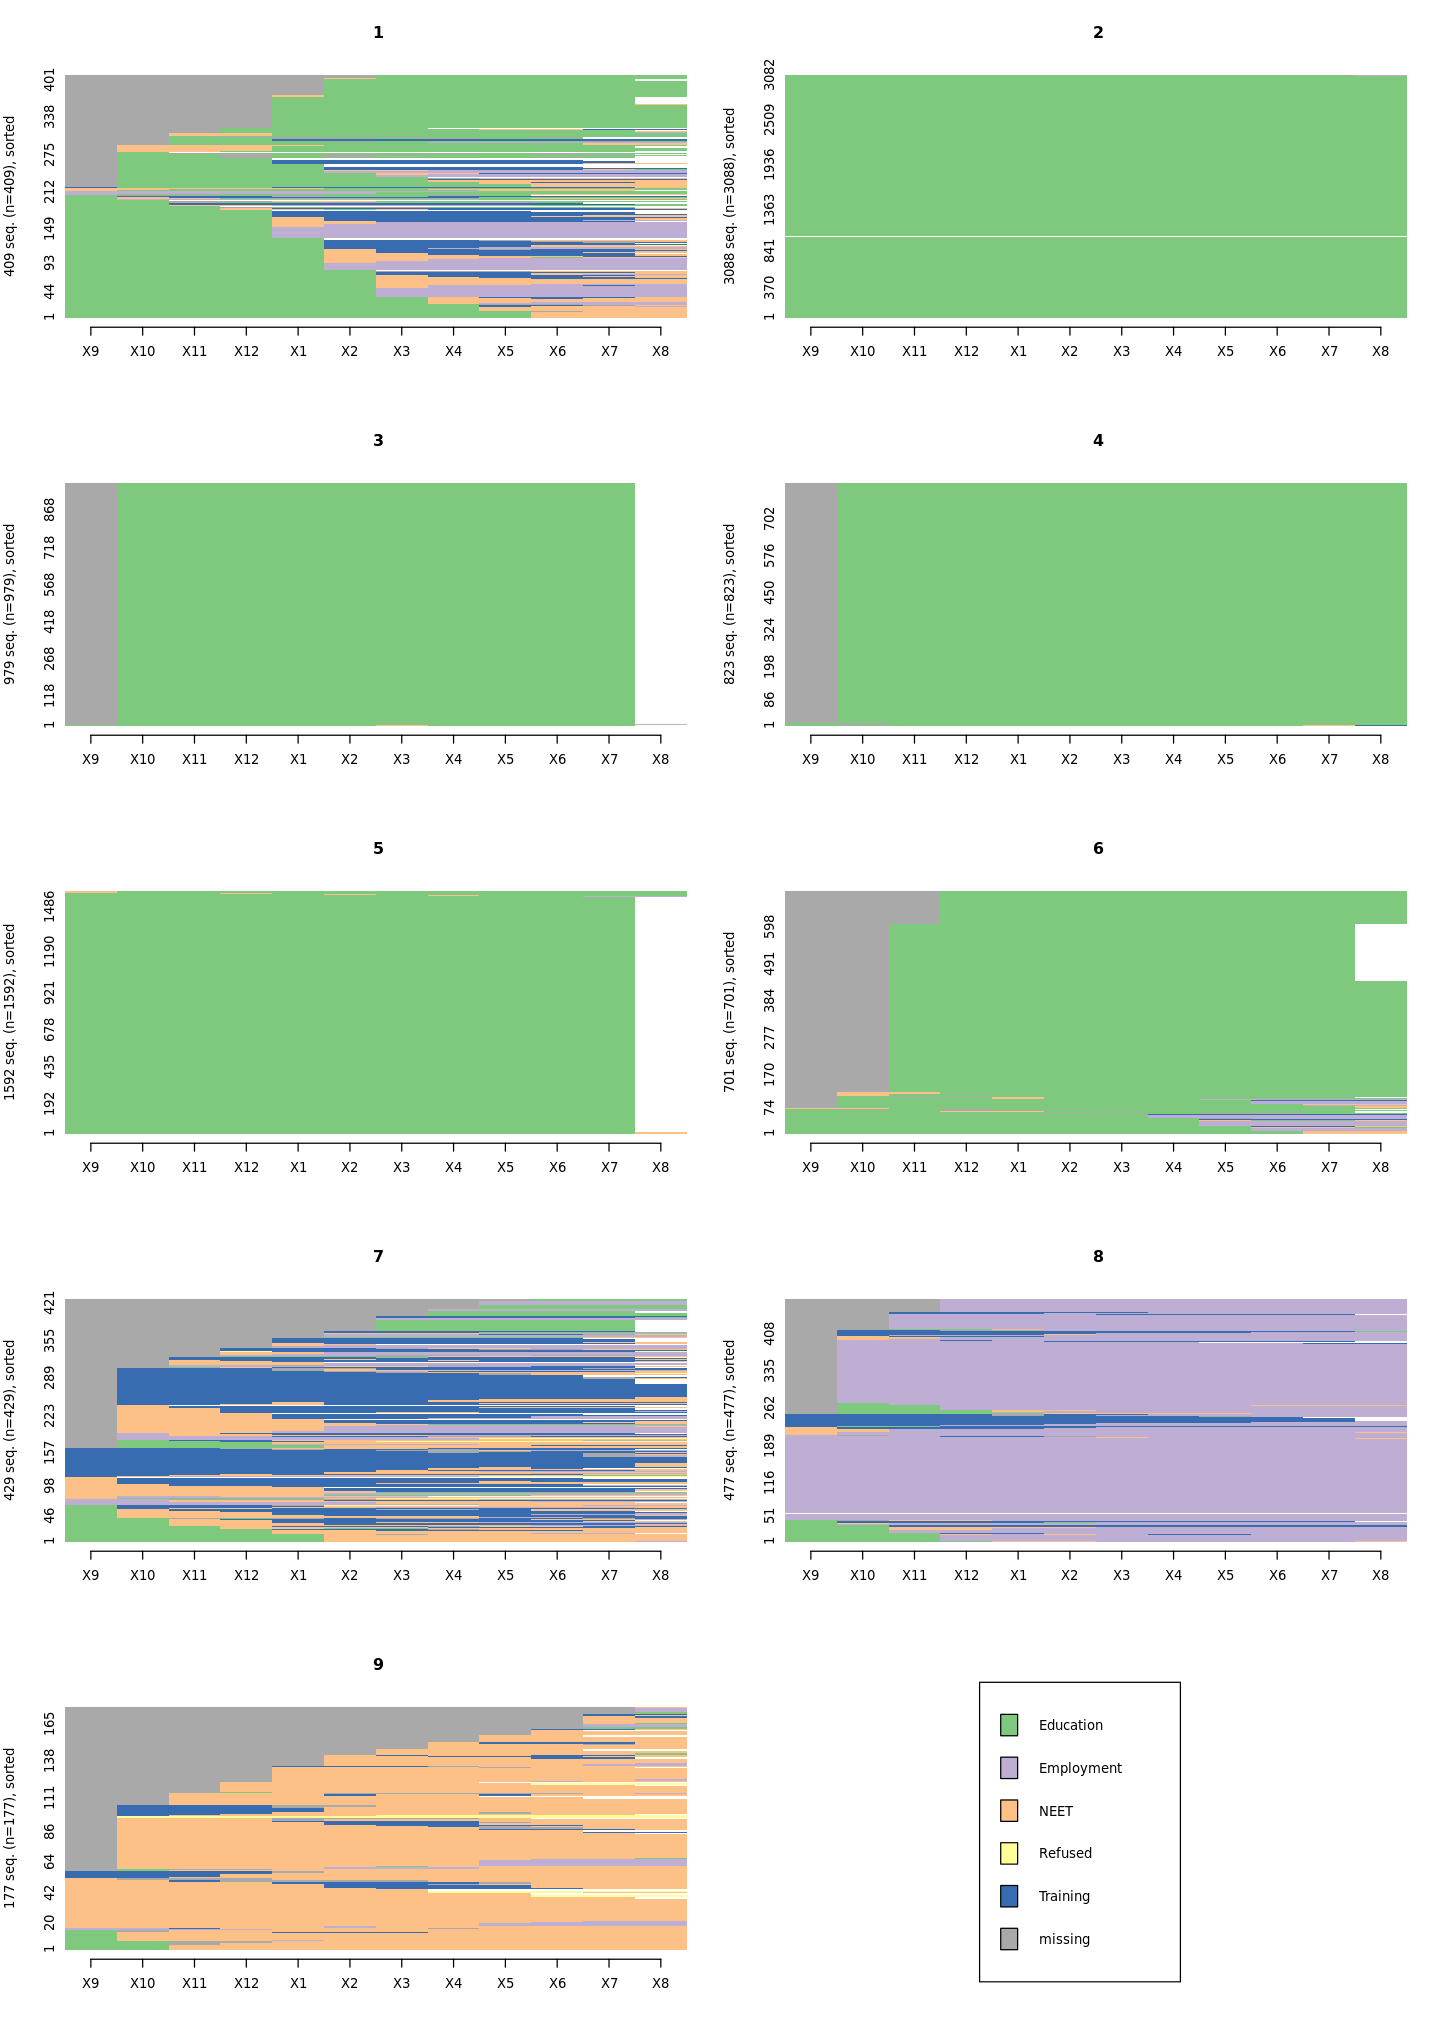

In [47]:
options(repr.plot.width = 12, repr.plot.height = 17)
# Plot individual trajectories per cluster
seqIplot(destinations_seq.seq, group = clara_cluster$clustering, sortv = "from.start")

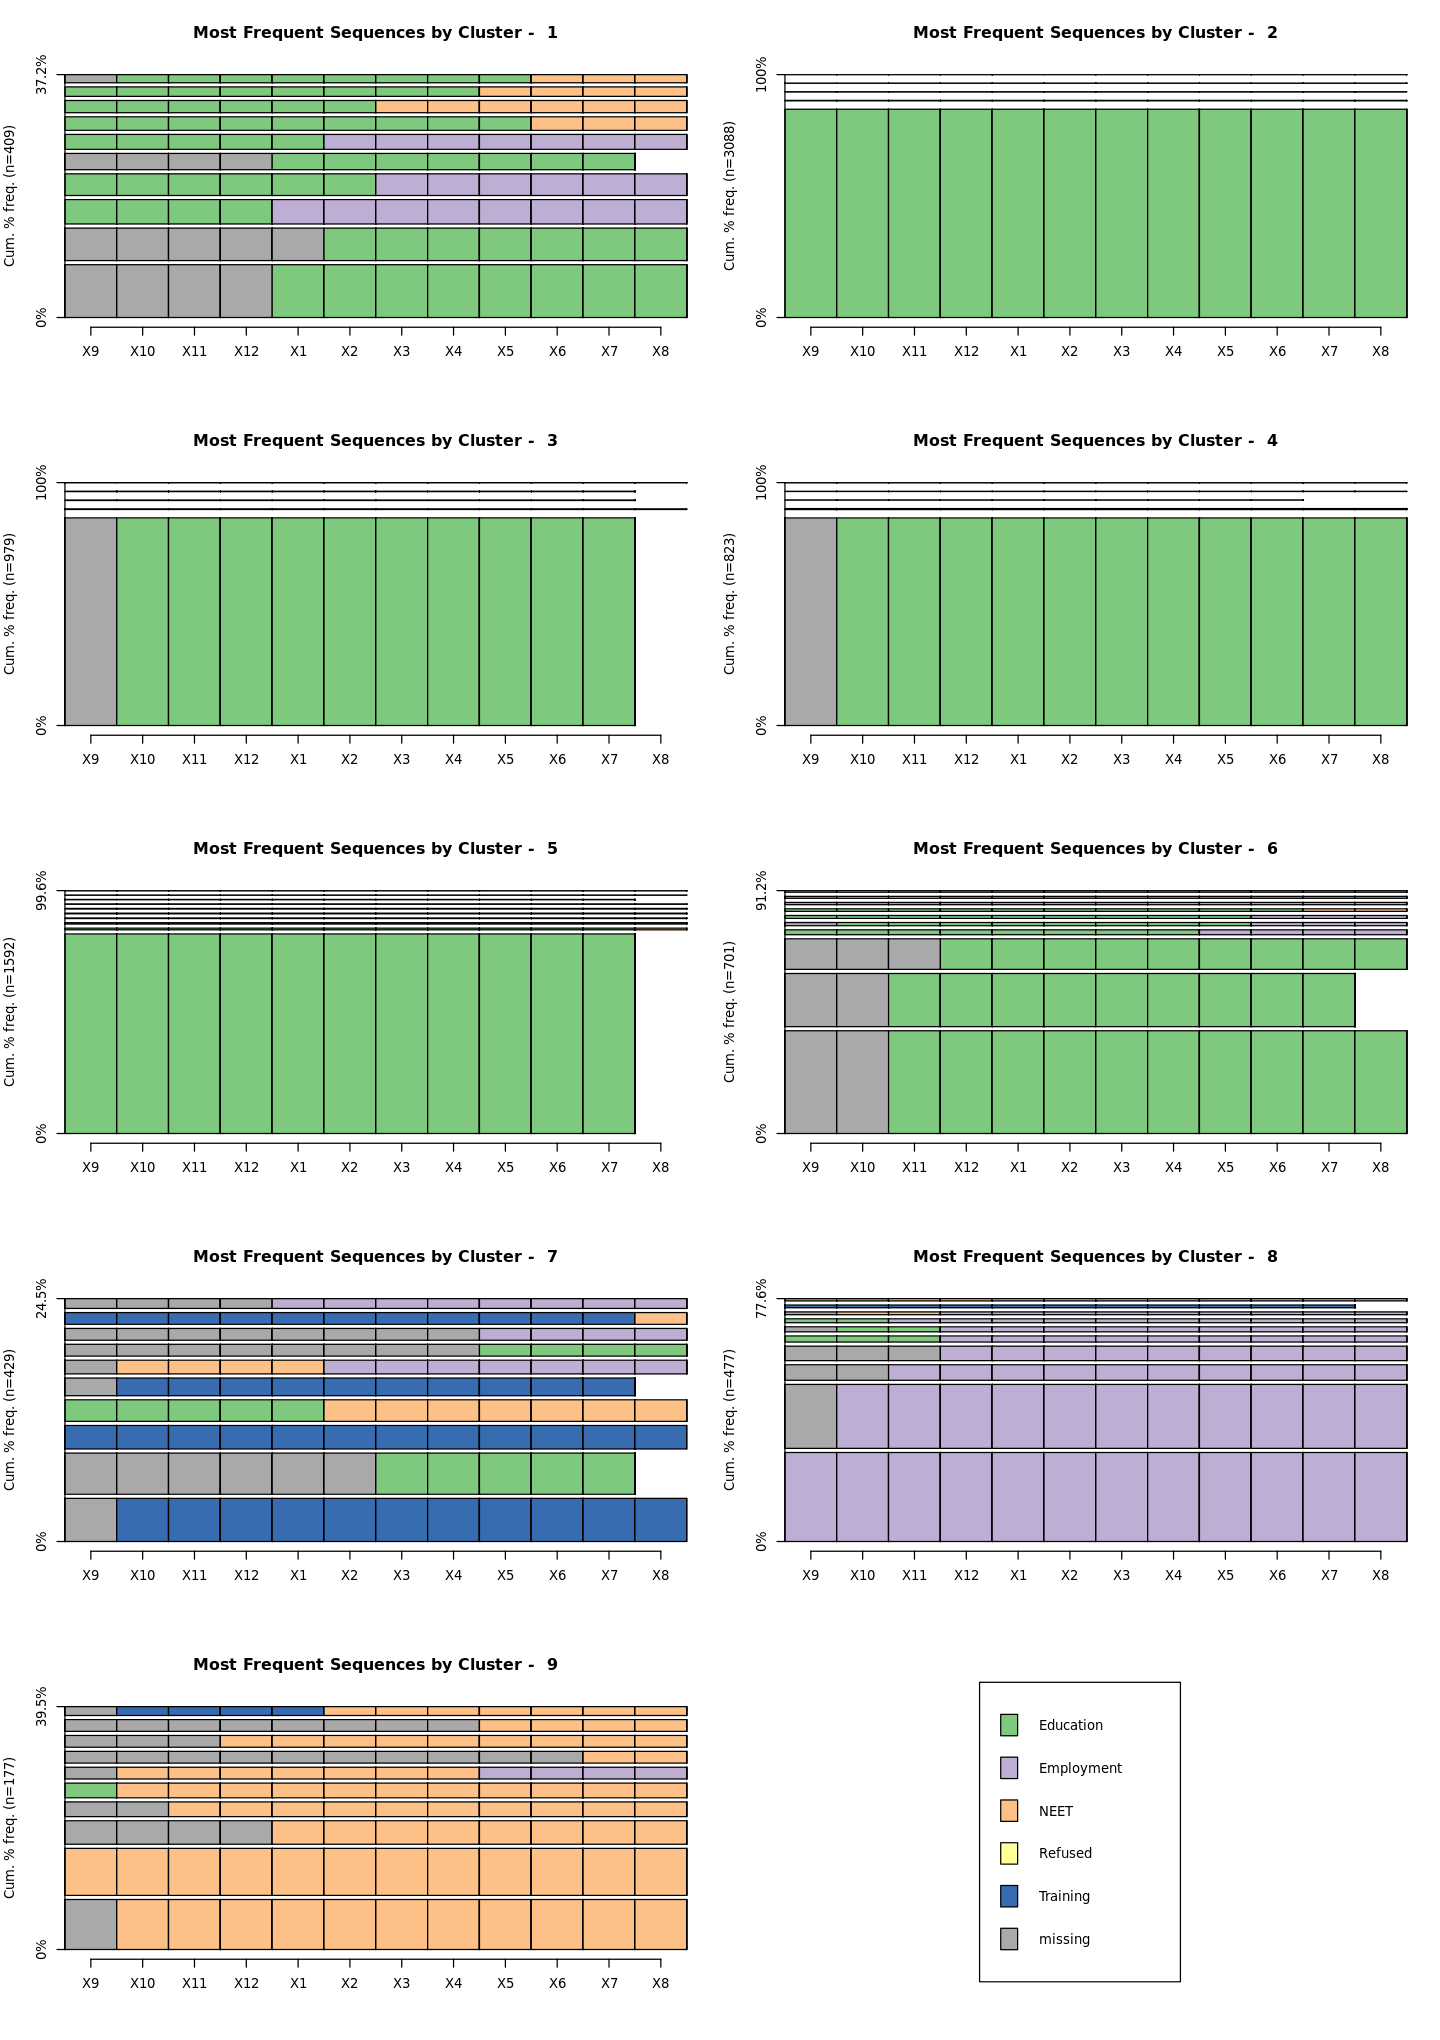

In [48]:
# Plot most frequent sequences per cluster
seqfplot(destinations_seq.seq, group = clara_cluster$clustering, 
         with.legend = TRUE, main = "Most Frequent Sequences by Cluster")

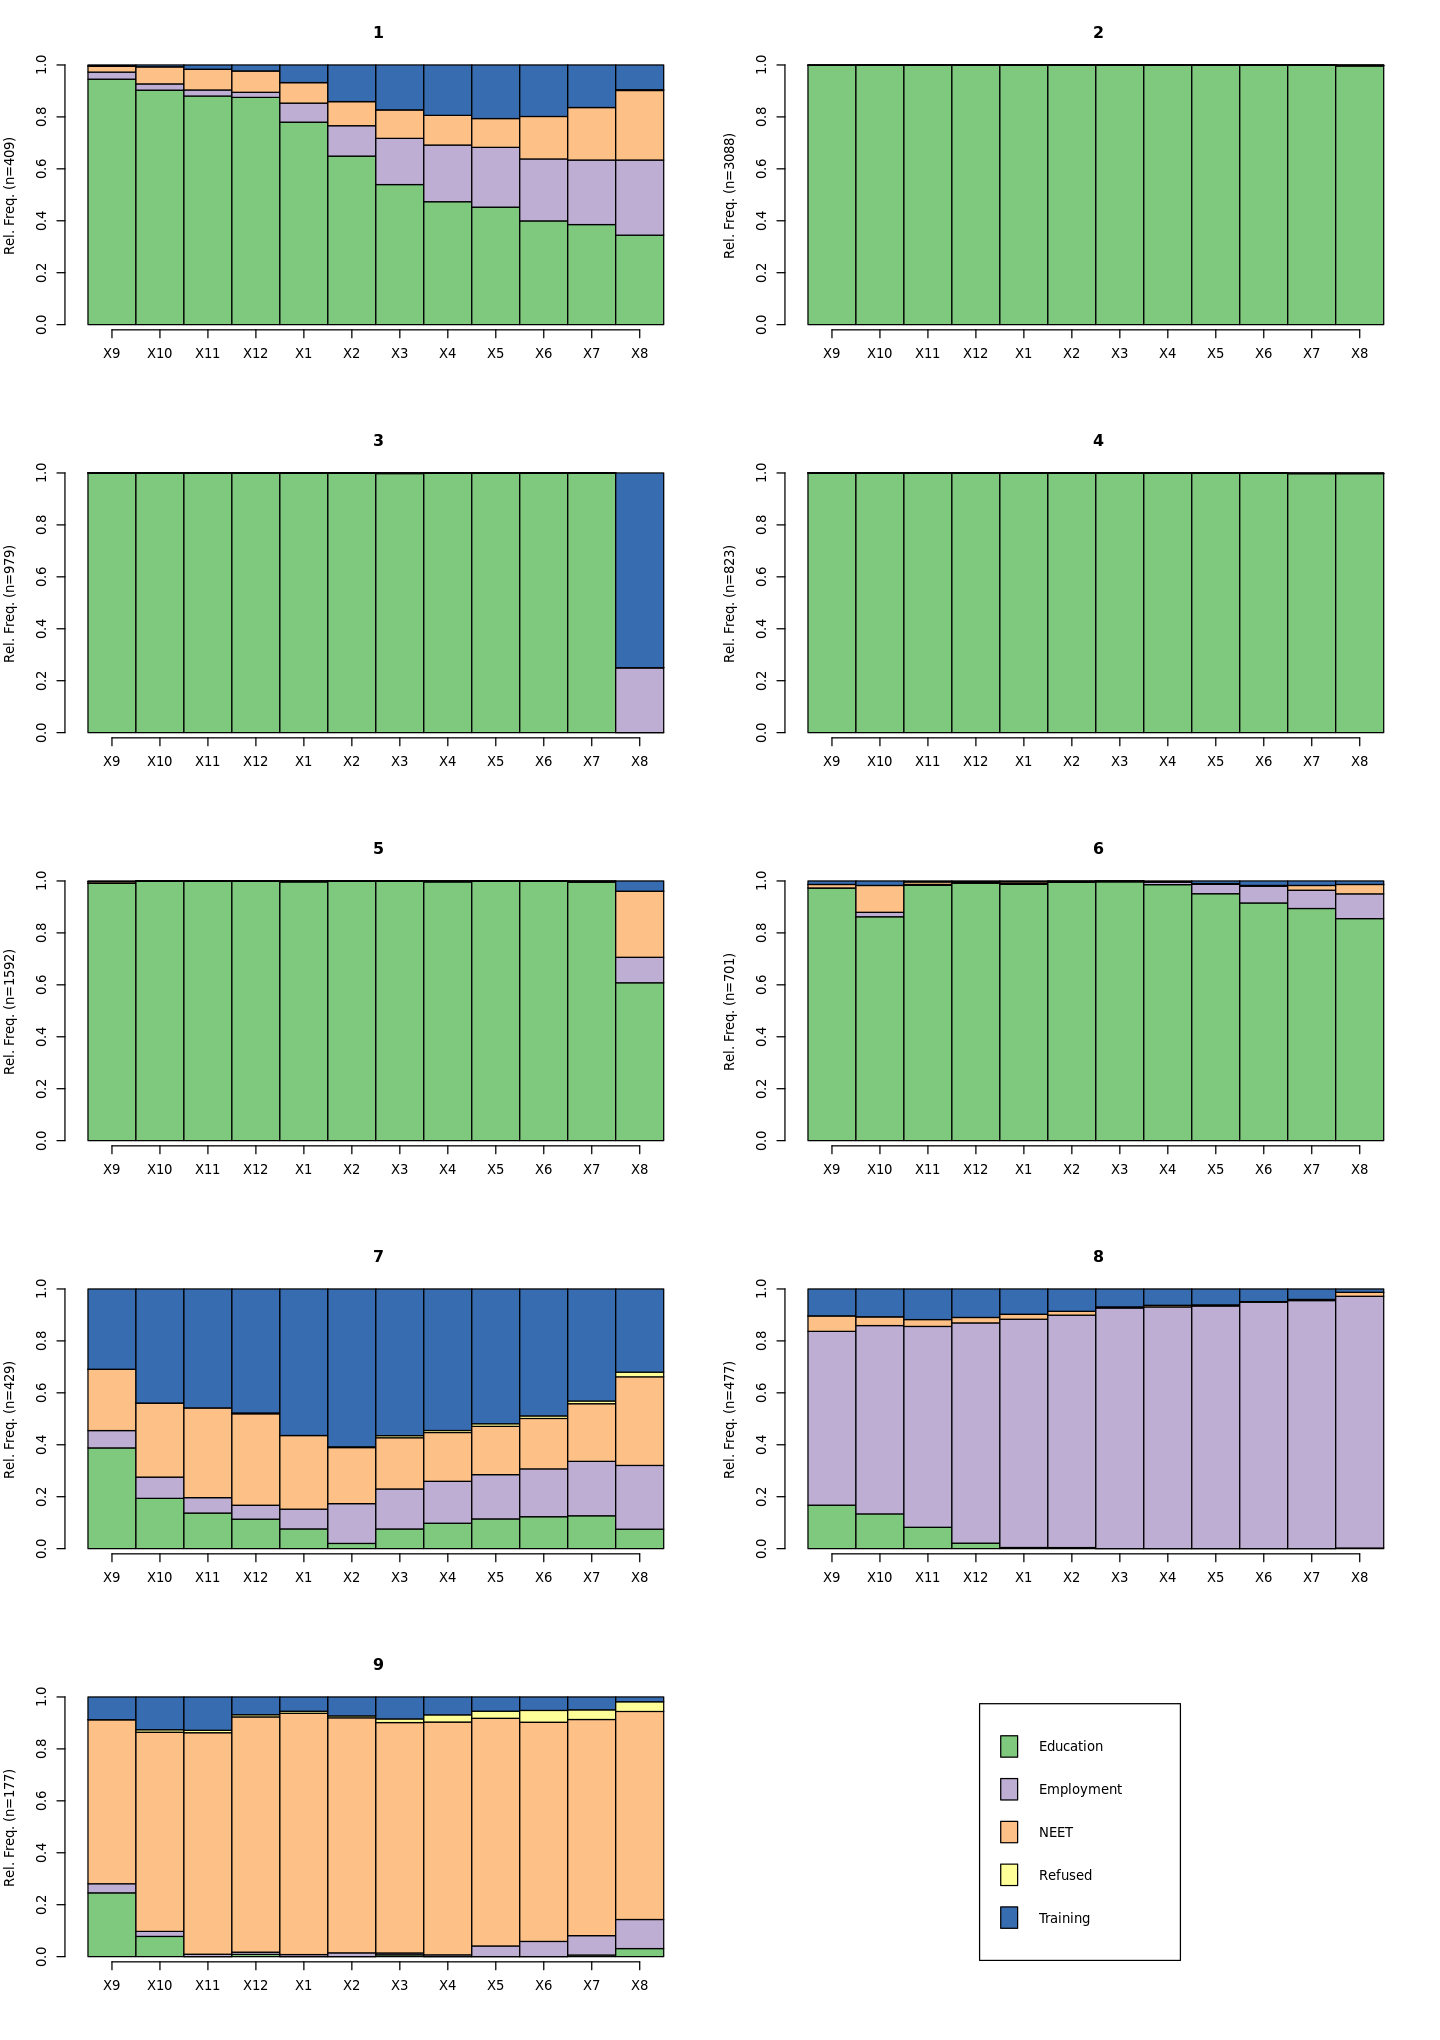

In [49]:
# Plot state distribution per cluster
seqdplot(destinations_seq.seq, group = clara_cluster$clustering)

In [50]:
# Get medoids (representative sequences for each cluster)
clara_cluster$medoids

,1,2,3,4,5,6,7,8,9,10,⋯,8666,8667,8668,8669,8670,8671,8672,8673,8674,8675
8237,6,9,6,7,6,6,8,6,7,9,⋯,7,8,6,8,9,7,8,6,6,7
8521,12,0,3,2,3,3,1,3,7,0,⋯,2,1,3,1,0,2,1,3,3,2
8309,11,3,0,1,0,0,2,0,6,3,⋯,1,2,0,2,3,1,2,0,0,1
8636,12,2,1,0,1,1,1,1,7,2,⋯,0,1,1,1,2,0,1,1,1,0
8606,11,1,2,1,2,2,0,2,6,1,⋯,1,0,2,0,1,1,0,2,2,1
7449,12,4,1,2,1,1,3,1,7,4,⋯,2,3,1,3,4,2,3,1,1,2
8202,16,16,13,14,13,13,15,13,12,16,⋯,14,15,13,15,16,14,15,13,13,14
169,18,13,11,11,11,11,12,11,12,13,⋯,11,12,11,12,13,11,12,11,11,11
3821,12,24,21,22,21,21,23,21,17,24,⋯,22,23,21,23,24,22,23,21,21,22


In [51]:
# Get cluster assignments
cluster_labels <- clara_cluster$clustering

In [52]:
cluster_labels

1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
   1    2    3    4    3    3    5    3    1    2    6    3    7    3    3    6 
  17   18   19   20   21   22   23   24   25   26   27   28   29   30   31   32 
   2    2    5    3    3    3    6    3    5    5    4    1    4    2    2    5 
  33   34   35   36   37   38   39   40   41   42   43   44   45   46   47   48 
   3    2    2    7    2    6    5    4    6    2    3    3    3    5    3    2 
  49   50   51   52   53   54   55   56   57   58   59   60   61   62   63   64 
   6    5    6    2    2    5    5    4    6    8    4    7    6    3    2    7 
  65   66   67   68   69   70   71   72   73   74   75   76   77   78   79   80 
   5    1    5    2    2    2    2    2    2    5    2    2    6    6    7    7 
  81   82   83   84   85   86   87   88   89   90   91   92   93   94   95   96 
   5    5    7    4    4    7    9    8    2    1    5    4    6    6    4    8 
  97   98   99  100  101  102  103  104  105  106  107  108  109  110  111  112 
   2    2    2    5    2    3    5    5    3    2    2    4    5    3    4    2 
 113  114  115  116  117  118  119  120  121  122  123  124  125  126  127  128 
   8    5    7    2    5    2    6    2    8    1    2    5    7    3    2    8 
 129  130  131  132  133  134  135  136  137  138  139  140  141  142  143  144 
   7    5    4    5    2    4    2    2    2    4    2    6    2    2    2    4 
 145  146  147  148  149  150  151  152  153  154  155  156  157  158  159  160 
   4    3    2    3    1    2    6    5    5    7    2    5    5    4    6    2 
 161  162  163  164  165  166  167  168  169  170  171  172  173  174  175  176 
   5    7    2    6    3    5    2    1    8    2    4    2    3    4    2    5 
 177  178  179  180  181  182  183  184  185  186  187  188  189  190  191  192 
   3    5    2    2    9    3    6    5    7    2    2    2    2    5    2    5 
 193  194  195  196  197  198  199  200  201  202  203  204  205  206  207  208 
   5    2    2    2    1    2    8    8    2    4    6    2    2    6    7    2 
 209  210  211  212  213  214  215  216  217  218  219  220  221  222  223  224 
   4    2    3    7    2    2    2    2    2    4    3    2    7    6    5    3 
 225  226  227  228  229  230  231  232  233  234  235  236  237  238  239  240 
   1    3    2    2    8    2    3    5    5    5    3    6    5    3    5    6 
 241  242  243  244  245  246  247  248  249  250  251  252  253  254  255  256 
   3    8    8    9    2    2    5    2    5    2    5    5    5    2    2    3 
 257  258  259  260  261  262  263  264  265  266  267  268  269  270  271  272 
   2    2    5    3    4    1    8    8    5    4    4    2    4    1    7    2 
 273  274  275  276  277  278  279  280  281  282  283  284  285  286  287  288 
   1    5    1    2    2    2    7    2    2    6    2    2    7    4    5    4 
 289  290  291  292  293  294  295  296  297  298  299  300  301  302  303  304 
   2    2    3    2    2    2    3    2    1    5    5    5    2    2    2    2 
 305  306  307  308  309  310  311  312  313  314  315  316  317  318  319  320 
   4    2    2    2    2    5    8    2    5    2    2    5    2    7    2    8 
 321  322  323  324  325  326  327  328  329  330  331  332  333  334  335  336 
   4    3    2    5    2    2    2    2    6    7    5    6    3    2    2    7 
 337  338  339  340  341  342  343  344  345  346  347  348  349  350  351  352 
   8    2    2    2    2    7    2    4    2    2    2    8    6    2    4    6 
 353  354  355  356  357  358  359  360  361  362  363  364  365  366  367  368 
   2    7    6    2    5    8    2    3    1    2    4    4    2    1    3    2 
 369  370  371  372  373  374  375  376  377  378  379  380  381  382  383  384 
   6    5    4    5    2    5    2    2    2    1    5    2    7    7    5    3 
 385  386  387  388  389  390  391  392  393  394  395  396  397  398  399  400 
   2    2    6    3    5    5    8

In [53]:
# Add cluster assignments to the original dataset
destinations_seq_18$cluster_dummy <- cluster_labels

In [54]:
head(destinations_seq_18)

,person_id,NCCIS_ACADYR,Intended_destination,X9,X10,X11,X12,X1,X2,X3,X4,X5,X6,X7,X8,cluster_dummy
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019,NA,Education,Education,Education,Education,Education,Education,NEET,NEET,NEET,NEET,NEET,NEET,1
2,0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,2
3,0018E26A40A6299391164D4918658B0B1248367C762DCE6D2FDF1AE131A9138C,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA,3
4,0019031CD62586D59268772800516ED50CDF1EF7DE46488542BB031850F6E68A,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,4
5,001E5C1FFA964716BF5E84562BC0B5D64F7742B1E8126718A5C0157D485F215D,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA,3
6,001F566795F57F5D8DD92430D868A38B757699844E3E09569B33253527012932,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA,3


In [48]:
destinations_seq_18 <- destinations_seq_18 |>
    mutate(cluster = case_when(
            cluster_dummy == 1 ~ 3,
            cluster_dummy == 2 ~ 1,
            cluster_dummy == 3 ~ 2,
            cluster_dummy == 4 ~ 4
            )
           ) |>
    select(-cluster_dummy)

In [49]:
destinations_seq_18

person_id,NCCIS_ACADYR,Intended_destination,9,10,11,12,1,2,3,4,5,6,7,8,cluster
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019,NA,Education,Education,Education,Education,Education,Education,NEET,NEET,NEET,NEET,NEET,NEET,3
0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,1
0018E26A40A6299391164D4918658B0B1248367C762DCE6D2FDF1AE131A9138C,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA,2
0019031CD62586D59268772800516ED50CDF1EF7DE46488542BB031850F6E68A,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,2
001E5C1FFA964716BF5E84562BC0B5D64F7742B1E8126718A5C0157D485F215D,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA,2
001F566795F57F5D8DD92430D868A38B757699844E3E09569B33253527012932,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA,2
001FFD3AA96B7E4FC5BB9A2F7502CD45BFCC35882335F1C34F78DD9AE5667225,2018/2019,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA,1
002AB68E0EC9459837DD6159160BF8C592504B5F0EE3160A22051398D20C3FFC,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA,2
002EF3F17C7981C3D6FD842C559E9AA0626E06B3940B670DDA2B71F7070ADF7D,2018/2019,NA,Education,Education,Education,Education,Education,NA,NA,NA,NA,NA,NA,NA,2


In [51]:
write.csv(destinations_seq_18, "data/destinations_seq_18.csv", row.names = FALSE)

### Both years

#### add activity counts per row

In [24]:
destinations_counts <- destinations_seq |>
    rowwise() |>
    mutate(
    Education = sum(c_across(`X9`:`X8`) == "Education", na.rm = TRUE),
    Employment = sum(c_across(`X9`:`X8`) == "Employment", na.rm = TRUE),
    Training = sum(c_across(`X9`:`X8`) == "Training", na.rm = TRUE),
    Refused = sum(c_across(`X9`:`X8`) == "Refused", na.rm = TRUE),
    # check starts with 
    NEET = sum(grepl("^NEET", c_across(`X9`:`X8`)), na.rm = TRUE),
    NA_count = sum(is.na(c_across(`X9`:`X8`)))
        ) |>
    ungroup()

In [25]:
head(destinations_counts)

person_id,NCCIS_ACADYR,Intended_destination,X9,X10,X11,X12,X1,X2,X3,⋯,X5,X6,X7,X8,Education,Employment,Training,Refused,NEET,NA_count
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,Education,12,0,0,0,0,0
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,Education,12,0,0,0,0,0
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019,NA,Education,Education,Education,Education,Education,Education,NEET,⋯,NEET,NEET,NEET,NEET,6,0,0,0,6,0
0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,Education,12,0,0,0,0,0
00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018,NA,NA,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,NA,10,0,0,0,0,2
0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,Education,12,0,0,0,0,0


#### Extract 'Steady EET' and non-NEET incomplete records

In [75]:
destinations_counts_labelled <- destinations_counts |>
    mutate(Label = case_when(
        NEET == 0 & Refused == 0 & NA_count <= 4 ~ 'Steady EET',
        NEET == 0 & Refused == 0 & NA_count >= 5 ~ 'DROP',
        TRUE ~ NA
    )
          )

In [76]:
destinations_counts_labelled |>
    group_by(Label) |>
    tally()

Label,n
<chr>,<int>
DROP,294
Steady EET,15665
NA,1402


In [77]:
destinations_counts_labelled |>
    filter(is.na(Label) & NEET == 0)

person_id,NCCIS_ACADYR,Intended_destination,X9,X10,X11,X12,X1,X2,X3,⋯,X6,X7,X8,Education,Employment,Training,Refused,NEET,NA_count,Label
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1AB1CE9EC6E66FE7AFA68117E2A68108ECDBE88D303D3DC990326F290A9307BA,2017/2018,NA,Education,Education,Education,Education,Refused,Refused,Refused,⋯,Refused,Refused,Refused,4,0,0,8,0,0,NA
1F77576ED8F4C24558692B27B4717F6779380FCA6F010A2E7F7401E857283179,2017/2018,NA,NA,Education,Education,Education,Refused,Refused,Refused,⋯,Refused,Refused,Refused,3,0,0,8,0,1,NA
402A241C1BB40BADFDEB24A77E8776CEAAB5BEB9AE3CD10C1840682231B2E36E,2018/2019,NA,NA,NA,NA,Refused,Training,Training,Training,⋯,Training,Training,Refused,0,0,7,2,0,3,NA
601CE11C72BFCB98DC741A0DD195D71C767B49A46FB9EEC36A64B0DF82B29714,2017/2018,NA,Education,Education,Education,Education,NA,NA,Refused,⋯,NA,NA,Employment,4,1,0,3,0,4,NA
68B7A6200CB6CAD83698D2591E505FA67E69DC991E837279F965185BD3FC1D7E,2017/2018,NA,NA,Refused,Refused,Refused,Refused,Refused,Refused,⋯,NA,Education,Education,2,0,0,8,0,2,NA
6A484E7E45ECA7A7722DB9289200E93EA4445A6FD11E219F5C2FE0222184F0B2,2017/2018,NA,NA,Education,Education,Education,Refused,Refused,Refused,⋯,Refused,Refused,Refused,3,0,0,8,0,1,NA
777D714DF89FD429075F60E0F8EDB810CC49467AD3891259D90F8AB68AB17365,2017/2018,NA,Education,Education,Education,Education,Refused,Refused,Refused,⋯,Refused,Refused,Refused,4,0,0,8,0,0,NA
A4B7D2DC9425FE8F9088407BA82C1CF976DED7ABC36B0CECE39685D1859DBA29,2018/2019,NA,NA,Employment,Employment,Employment,Employment,Employment,Employment,⋯,Refused,Refused,Refused,0,7,0,4,0,1,NA
DFE6DC1F10564F67A7895787CF0DF02D675A6FD7D2B065E29C95B68D1287D6B3,2017/2018,NA,NA,Education,Education,Education,Refused,Refused,Refused,⋯,Training,Training,Training,3,0,3,5,0,1,NA


In [78]:
destinations_counts_labelled |>
    filter(Label == 'DROP')

person_id,NCCIS_ACADYR,Intended_destination,X9,X10,X11,X12,X1,X2,X3,⋯,X6,X7,X8,Education,Employment,Training,Refused,NEET,NA_count,Label
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
002EF3F17C7981C3D6FD842C559E9AA0626E06B3940B670DDA2B71F7070ADF7D,2018/2019,NA,Education,Education,Education,Education,Education,NA,NA,⋯,NA,NA,NA,5,0,0,0,0,7,DROP
004E9574803B8B9BCE83304FE77D4DEF97CBE5F974323B03A9626E3F58F2C894,2017/2018,NA,NA,NA,NA,NA,NA,Employment,Employment,⋯,Employment,Employment,Education,1,6,0,0,0,5,DROP
01B91479C3300D9C39E229F7F1990B46E9D9DA0E3F4205A4C4CED14633ABD8B0,2018/2019,NA,NA,NA,NA,NA,NA,NA,Employment,⋯,Employment,Employment,Employment,0,6,0,0,0,6,DROP
0315ACB6F9A641359527404B5A4EC62CA5477FFDBB03C58B30C46D06568D639F,2017/2018,NA,NA,NA,Education,Education,Education,Education,NA,⋯,NA,Education,NA,7,0,0,0,0,5,DROP
044919D425DE85D81C1046FDAFE278E591091A68171074C95468B20BFDABD389,2017/2018,NA,Education,Education,Education,Education,NA,NA,NA,⋯,NA,NA,NA,4,0,0,0,0,8,DROP
0490C312D6353B1C2BFA7058BDC82A246C73C13E5D7BBF1E53B76A74A5E4FEB7,2018/2019,NA,NA,NA,Education,NA,NA,Employment,NA,⋯,Employment,Employment,NA,1,4,0,0,0,7,DROP
050256C32FE3E4063EE4D8514F6C37761F2E7188725A2562A2E74DEDB88AE42C,2017/2018,NA,NA,Education,Education,Education,NA,NA,NA,⋯,NA,NA,NA,3,0,0,0,0,9,DROP
080B2DB605D3C9059A866068983D4A6F1D3951AC13D8CB5E7C9A8BE572FC49EB,2018/2019,NA,NA,NA,NA,NA,NA,Education,Education,⋯,Education,Education,Education,7,0,0,0,0,5,DROP
0872BAD4BD1E51EB06A5C190DCC62828E02314B6471CD4DE591C4569F2EC1B41,2018/2019,NA,NA,NA,NA,NA,NA,NA,NA,⋯,Education,Education,NA,4,0,0,0,0,8,DROP


In [80]:
destinations_counts_labelled |>
    filter(Label == 'Steady EET')

person_id,NCCIS_ACADYR,Intended_destination,X9,X10,X11,X12,X1,X2,X3,⋯,X6,X7,X8,Education,Employment,Training,Refused,NEET,NA_count,Label
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,12,0,0,0,0,0,Steady EET
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,12,0,0,0,0,0,Steady EET
0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,12,0,0,0,0,0,Steady EET
00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018,NA,NA,Education,Education,Education,Education,Education,Education,⋯,Education,Education,NA,10,0,0,0,0,2,Steady EET
0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,12,0,0,0,0,0,Steady EET
0018E26A40A6299391164D4918658B0B1248367C762DCE6D2FDF1AE131A9138C,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,⋯,Education,Education,NA,10,0,0,0,0,2,Steady EET
0019031CD62586D59268772800516ED50CDF1EF7DE46488542BB031850F6E68A,2018/2019,NA,NA,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,11,0,0,0,0,1,Steady EET
001B7CEB7B4CC529920A0B9F5B83D1AC0019E5DC44B3FBB3CEF665C331C0C3B6,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,NA,11,0,0,0,0,1,Steady EET
001E539C263734CC355646811C93CF85B0C587D2EBA8B0D79290FDE8A75D6267,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,12,0,0,0,0,0,Steady EET


In [81]:
destinations_counts_cut <- destinations_counts_labelled |>
    filter(is.na(Label))

In [82]:
destinations_counts_cut |>
    nrow()

[1] 1402

#### Find optimal K

In [83]:
# create a state sequence object from the status variables (columns 17 to 86)
# with missing TRUE treats missing values as a state
destinations_seq.seq <- seqdef(destinations_counts_cut, 4:15, with.missing = TRUE)

 [>] found missing values ('NA') in sequence data

 [>] preparing 1402 sequences

 [>] coding void elements with '%' and missing values with '*'

 [>] 5 distinct states appear in the data: 

     1 = Education

     2 = Employment

     3 = NEET

     4 = Refused

     5 = Training

 [>] state coding:

       [alphabet]  [label]    [long label] 

     1  Education   Education  Education

     2  Employment  Employment Employment

     3  NEET        NEET       NEET

     4  Refused     Refused    Refused

     5  Training    Training   Training

 [>] 1402 sequences in the data set

 [>] min/max sequence length: 1/12



In [87]:
options(repr.plot.width = 12, repr.plot.height = 10)

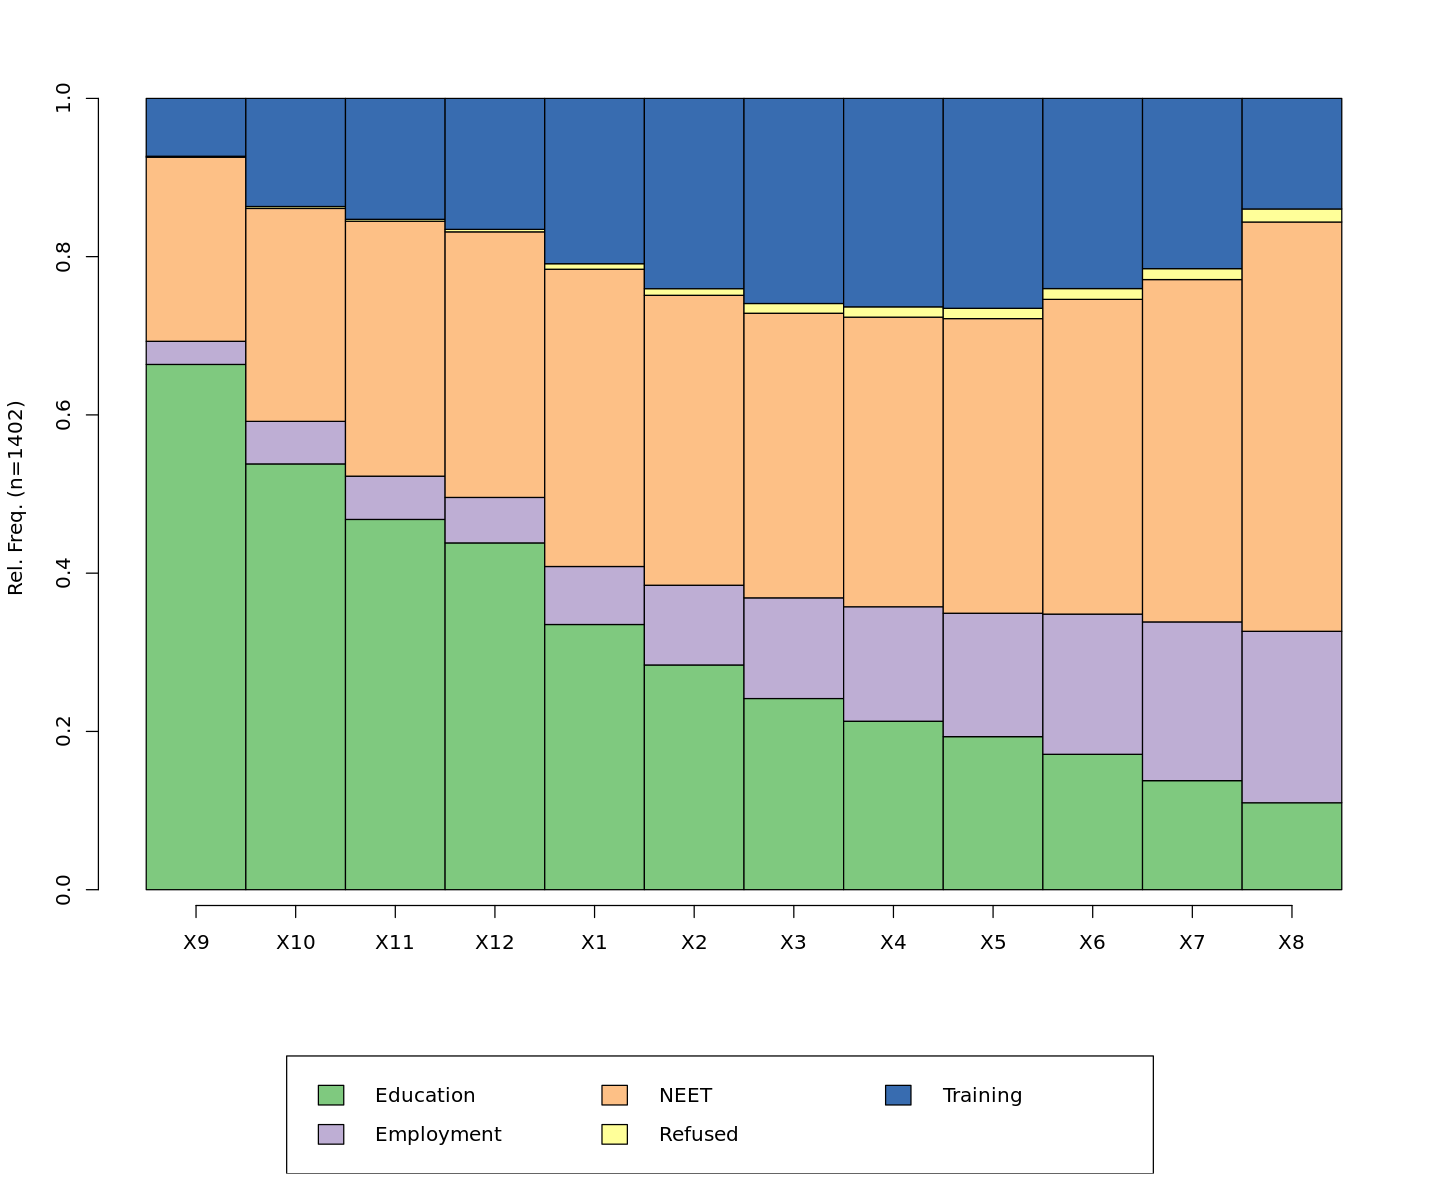

In [88]:
seqdplot(destinations_seq.seq)

In [85]:
# compute pairwise optimal matching (OM) distances 
destinations_seq.om <- seqdist(destinations_seq.seq, method = "OM", indel = 1, with.missing = TRUE, sm = submat)

 [>] including missing values as an additional state

 [>] 1402 sequences with 6 distinct states

 [>] checking 'sm' (size and triangle inequality)

Warning message:
“At least one substitution cost greater than twice the indel cost. Such substitution costs will never be used.”
 [>] 798 distinct  sequences 

 [>] min/max sequence lengths: 1/12

 [>] computing distances using the OM metric

 [>] elapsed time: 0.372 secs



In [45]:
install.packages("factoextra")
library(factoextra)

Installing package into ‘/home/jupyter/.R/library’
(as ‘lib’ is unspecified)

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



In [92]:
library(scales) # so i can use 'comma' in y axis scale below


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




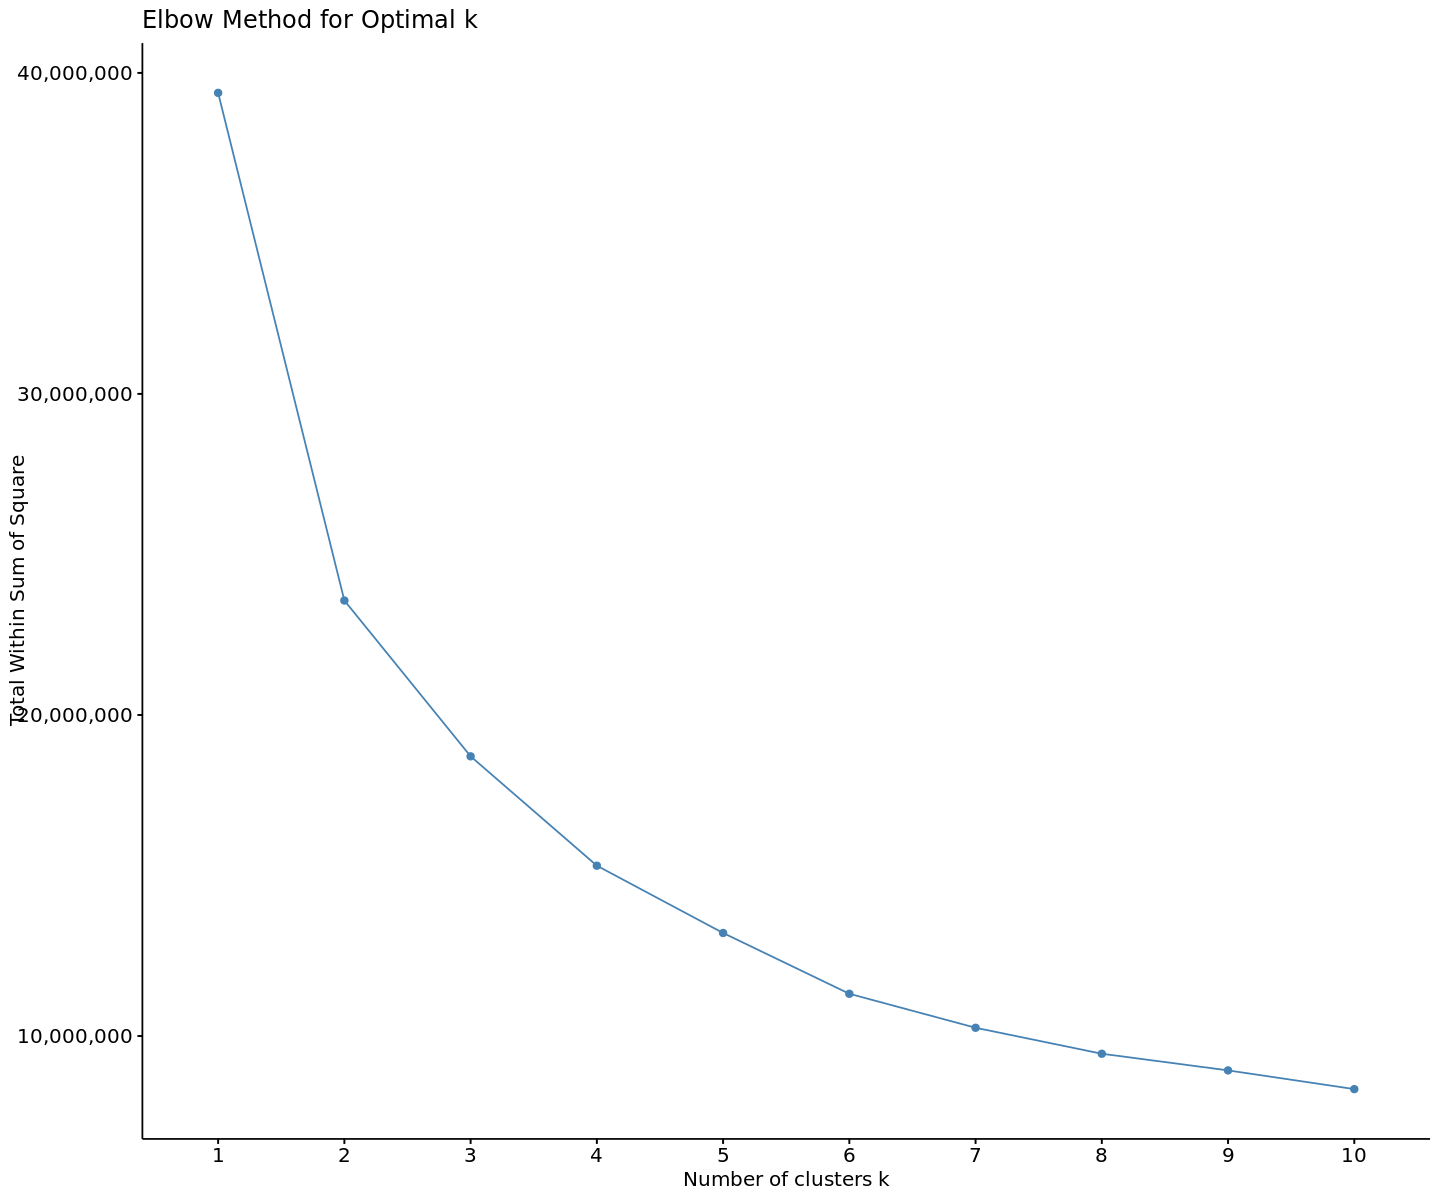

In [93]:
# Compute and plot WCSS (Within-cluster sum of squares) for different k
fviz_nbclust(destinations_seq.om, pam, method = "wss") +
  ggtitle("Elbow Method for Optimal k") +
  scale_y_continuous(labels = comma)

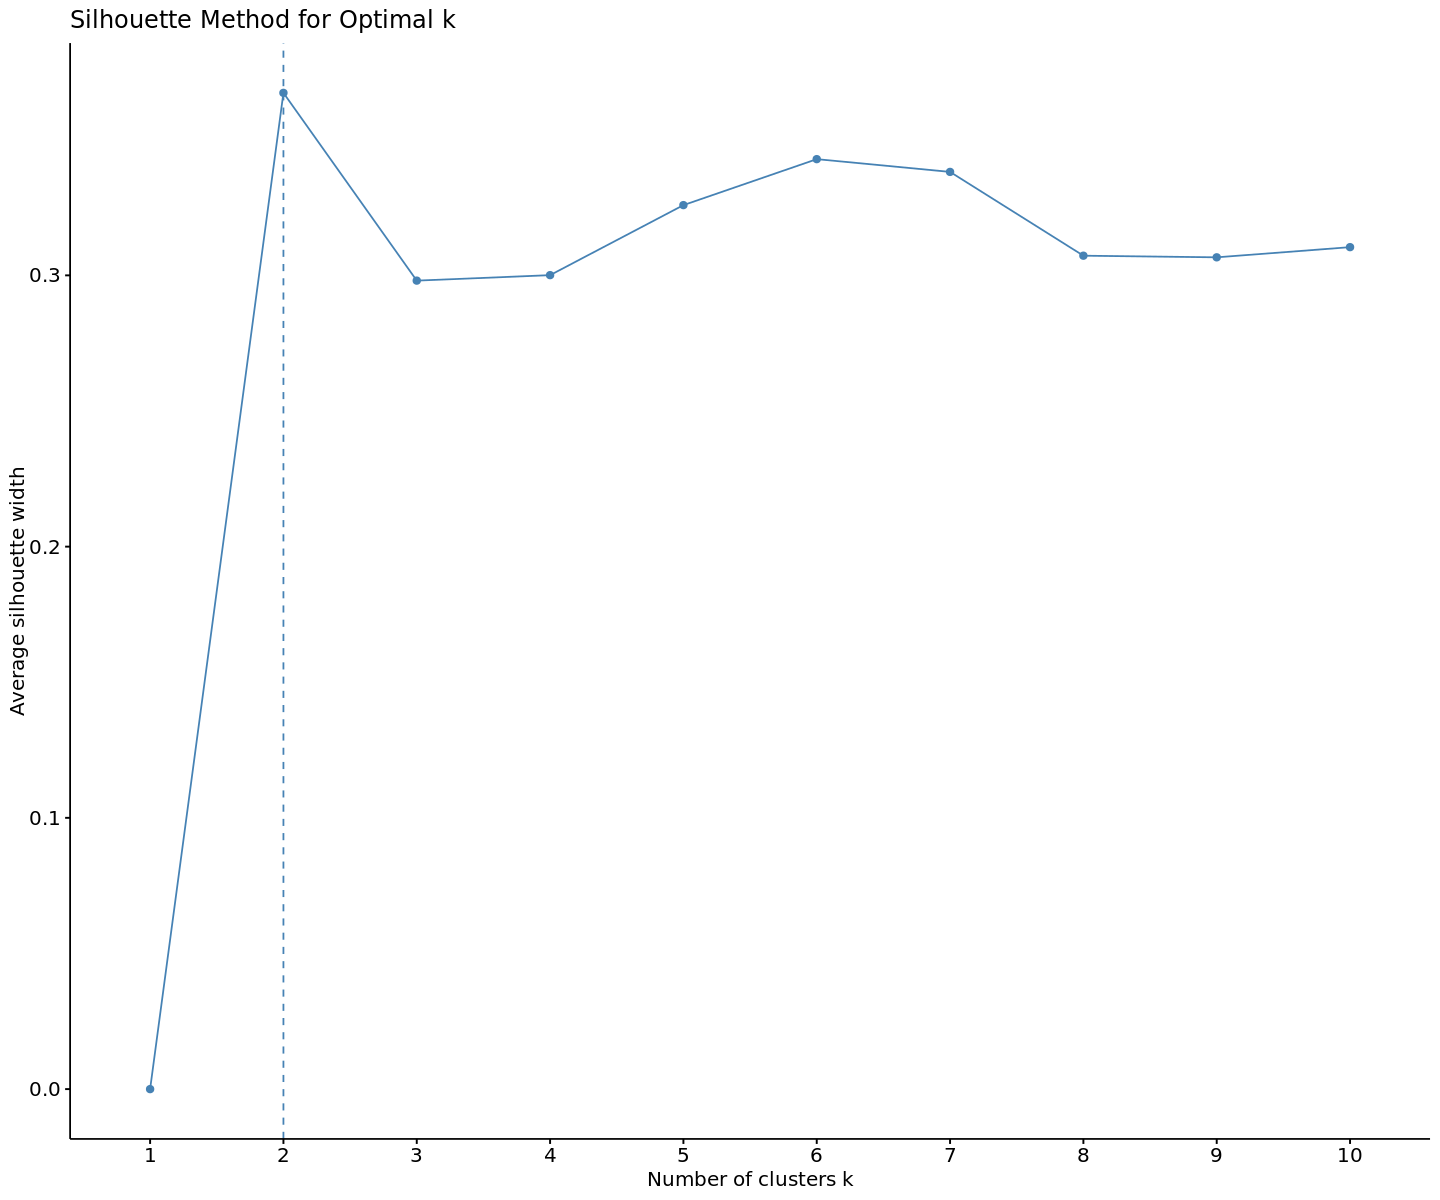

In [90]:
# Silhouette method to find optimal k (A higher average silhouette width suggests a better-defined clustering)
fviz_nbclust(destinations_seq.om, pam, method = "silhouette") +
  ggtitle("Silhouette Method for Optimal k")

#### PAM clustering

In [94]:
set.seed(123)
pam_cluster <- pam(destinations_seq.om, k = 6)

In [95]:
pam_cluster$clusinfo

size,max_diss,av_diss,diameter,separation
245,172.4152,99.23693,234.2541,29.05168
321,176.4115,97.69954,256.5210,25.07987
338,157.9019,84.44399,201.1567,25.07987
240,174.9714,81.32604,223.9509,35.04283
182,195.8903,102.27523,245.1122,34.52535
76,317.5689,109.10227,437.4471,34.39477


In [96]:
pam_cluster$clustering

1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
   1    2    1    1    2    3    4    3    3    1    1    1    2    5    2    2 
  17   18   19   20   21   22   23   24   25   26   27   28   29   30   31   32 
   4    4    3    2    1    1    1    4    3    1    1    6    2    3    2    1 
  33   34   35   36   37   38   39   40   41   42   43   44   45   46   47   48 
   1    5    4    3    5    2    2    3    5    6    3    3    2    2    5    2 
  49   50   51   52   53   54   55   56   57   58   59   60   61   62   63   64 
   1    2    2    3    1    3    3    2    4    3    4    4    3    6    2    1 
  65   66   67   68   69   70   71   72   73   74   75   76   77   78   79   80 
   6    1    2    4    5    2    5    3    1    5    3    4    2    3    2    4 
  81   82   83   84   85   86   87   88   89   90   91   92   93   94   95   96 
   1    2    3    6    3    1    2    2    4    6    1    4    5    2    2    2 
  97   98   99  100  101  102  103  104  105  106  107  108  109  110  111  112 
   5    2    1    2    2    3    6    5    2    5    3    2    4    2    4    4 
 113  114  115  116  117  118  119  120  121  122  123  124  125  126  127  128 
   5    3    3    3    3    3    2    3    2    1    6    2    6    6    3    2 
 129  130  131  132  133  134  135  136  137  138  139  140  141  142  143  144 
   3    4    5    4    3    2    5    2    5    2    3    2    3    1    2    3 
 145  146  147  148  149  150  151  152  153  154  155  156  157  158  159  160 
   1    2    3    2    6    6    3    3    1    5    3    3    1    1    3    3 
 161  162  163  164  165  166  167  168  169  170  171  172  173  174  175  176 
   4    1    2    2    3    1    6    1    3    5    5    4    1    3    1    1 
 177  178  179  180  181  182  183  184  185  186  187  188  189  190  191  192 
   4    4    1    3    2    5    6    3    2    5    5    2    4    4    6    5 
 193  194  195  196  197  198  199  200  201  202  203  204  205  206  207  208 
   6    3    1    1    2    4    3    1    2    1    5    4    4    3    4    5 
 209  210  211  212  213  214  215  216  217  218  219  220  221  222  223  224 
   6    2    4    4    3    3    2    2    5    4    3    5    4    3    6    6 
 225  226  227  228  229  230  231  232  233  234  235  236  237  238  239  240 
   3    3    2    2    3    4    2    1    4    2    3    3    5    1    4    4 
 241  242  243  244  245  246  247  248  249  250  251  252  253  254  255  256 
   4    2    2    4    3    5    2    6    3    2    3    3    5    2    4    3 
 257  258  259  260  261  262  263  264  265  266  267  268  269  270  271  272 
   4    2    3    4    1    2    1    5    4    3    5    3    5    4    1    2 
 273  274  275  276  277  278  279  280  281  282  283  284  285  286  287  288 
   2    2    5    6    1    3    6    1    5    3    3    4    1    3    3    3 
 289  290  291  292  293  294  295  296  297  298  299  300  301  302  303  304 
   4    6    3    1    3    4    2    4    6    1    2    3    4    4    2    3 
 305  306  307  308  309  310  311  312  313  314  315  316  317  318  319  320 
   3    5    3    2    1    2    6    2    5    1    1    4    3    5    4    3 
 321  322  323  324  325  326  327  328  329  330  331  332  333  334  335  336 
   5    3    5    2    1    1    2    2    4    3    3    2    4    3    3    4 
 337  338  339  340  341  342  343  344  345  346  347  348  349  350  351  352 
   1    5    2    2    4    1    2    1    2    2    2    5    1    3    4    6 
 353  354  355  356  357  358  359  360  361  362  363  364  365  366  367  368 
   3    1    2    1    5    2    4    6    3    3    4    2    1    5    2    4 
 369  370  371  372  373  374  375  376  377  378  379  380  381  382  383  384 
   3    3    2    4    2    2    2    4    4    3    2    5    2    1    3    5 
 385  386  387  388  389  390  391  392  393  394  395  396  397  398  399  400 
   6    5    5    3    2    2    5

In [97]:
options(repr.plot.width = 12, repr.plot.height = 16)

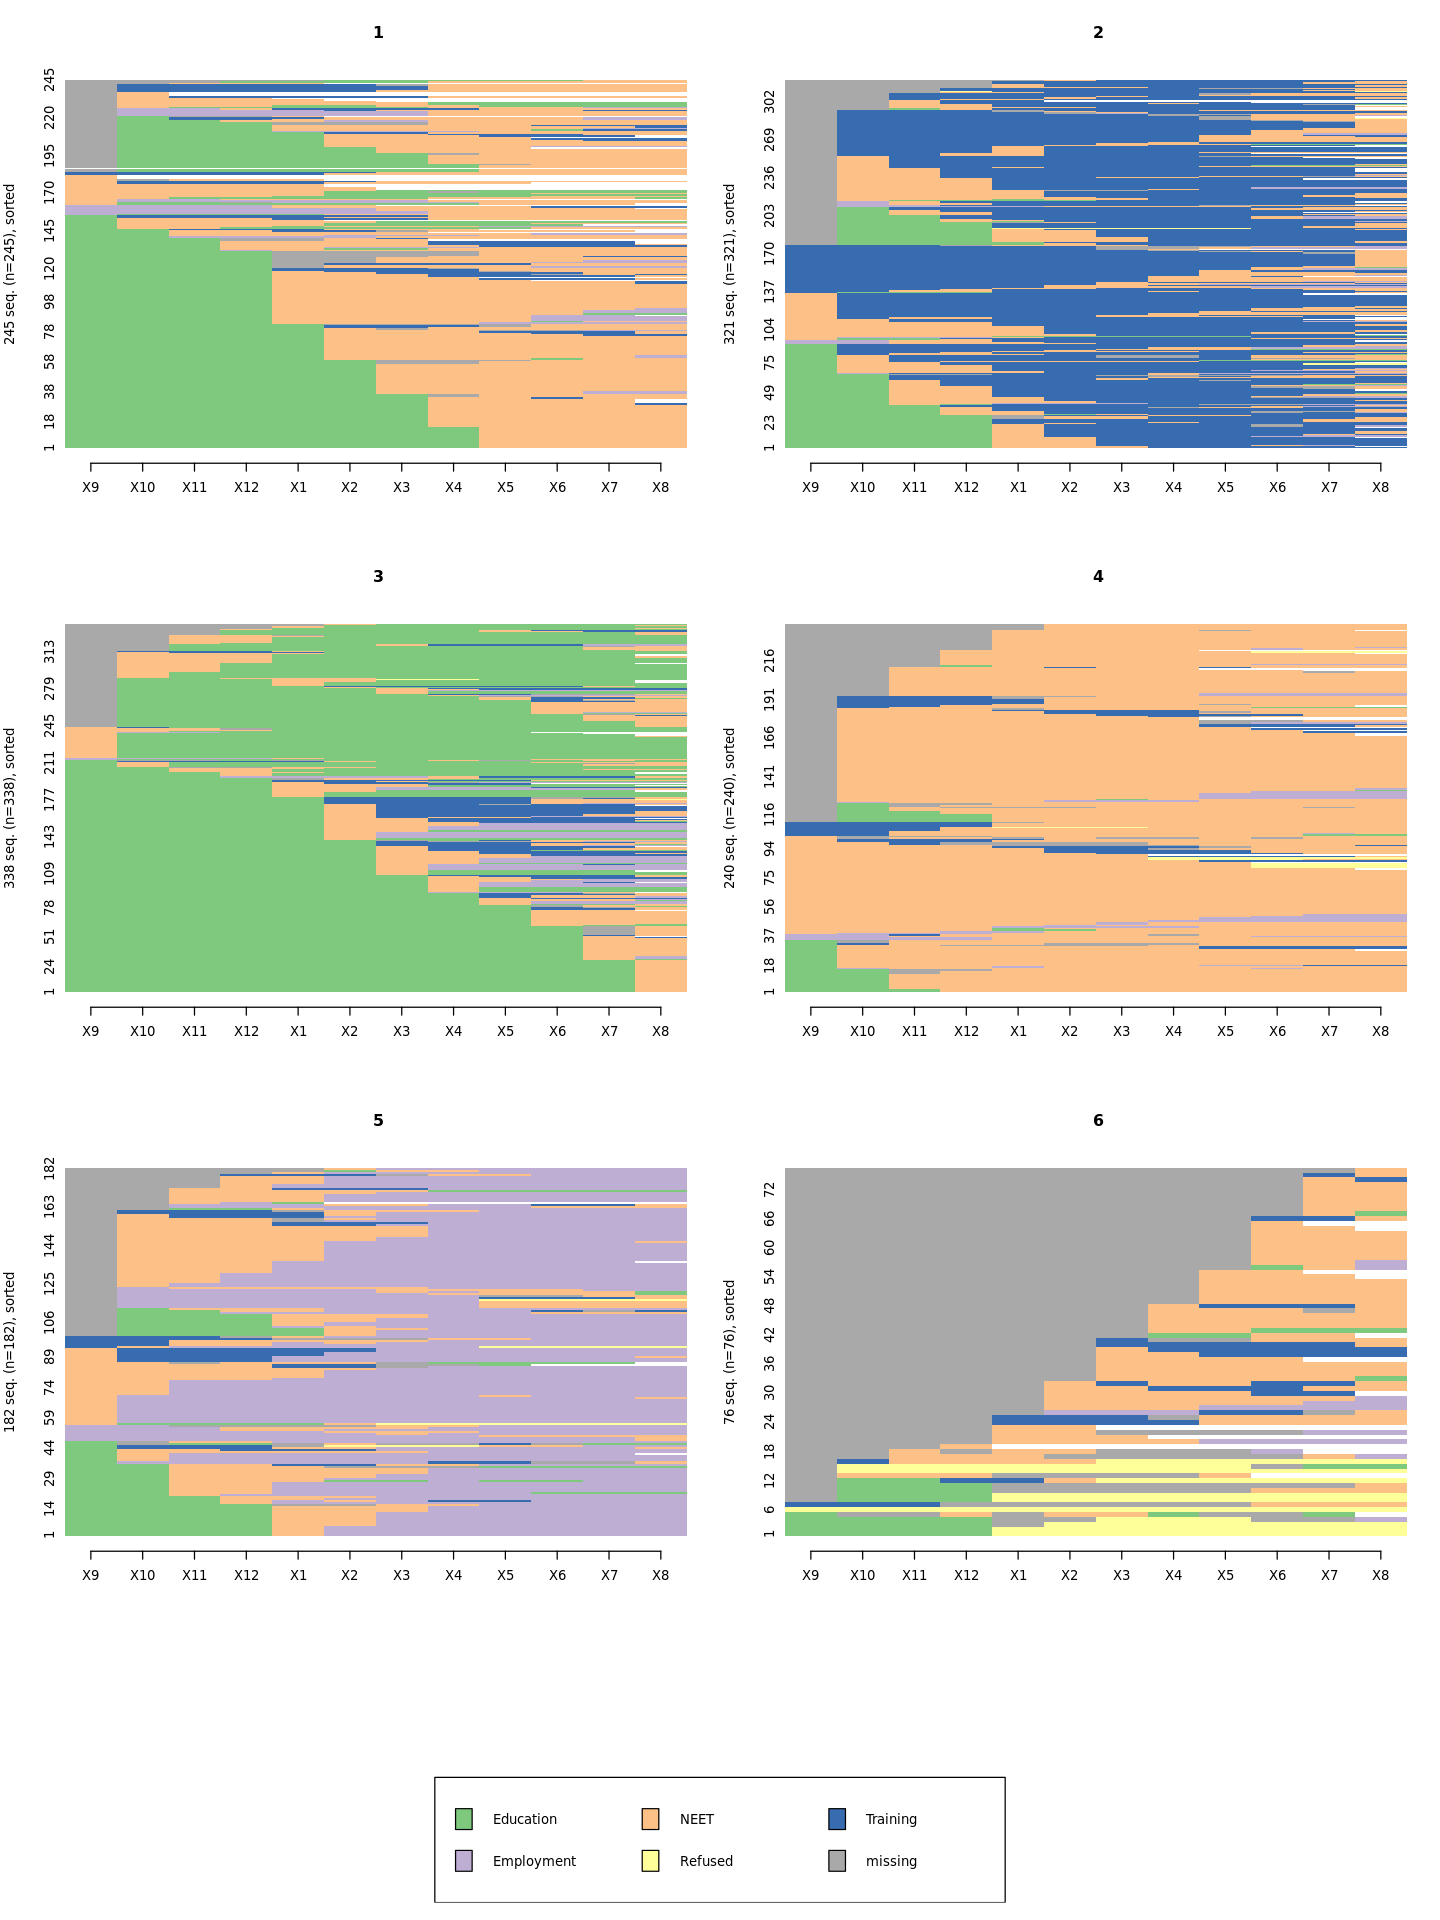

In [98]:
# Plot individual trajectories per cluster
seqIplot(destinations_seq.seq, group = pam_cluster$clustering, sortv = "from.start")

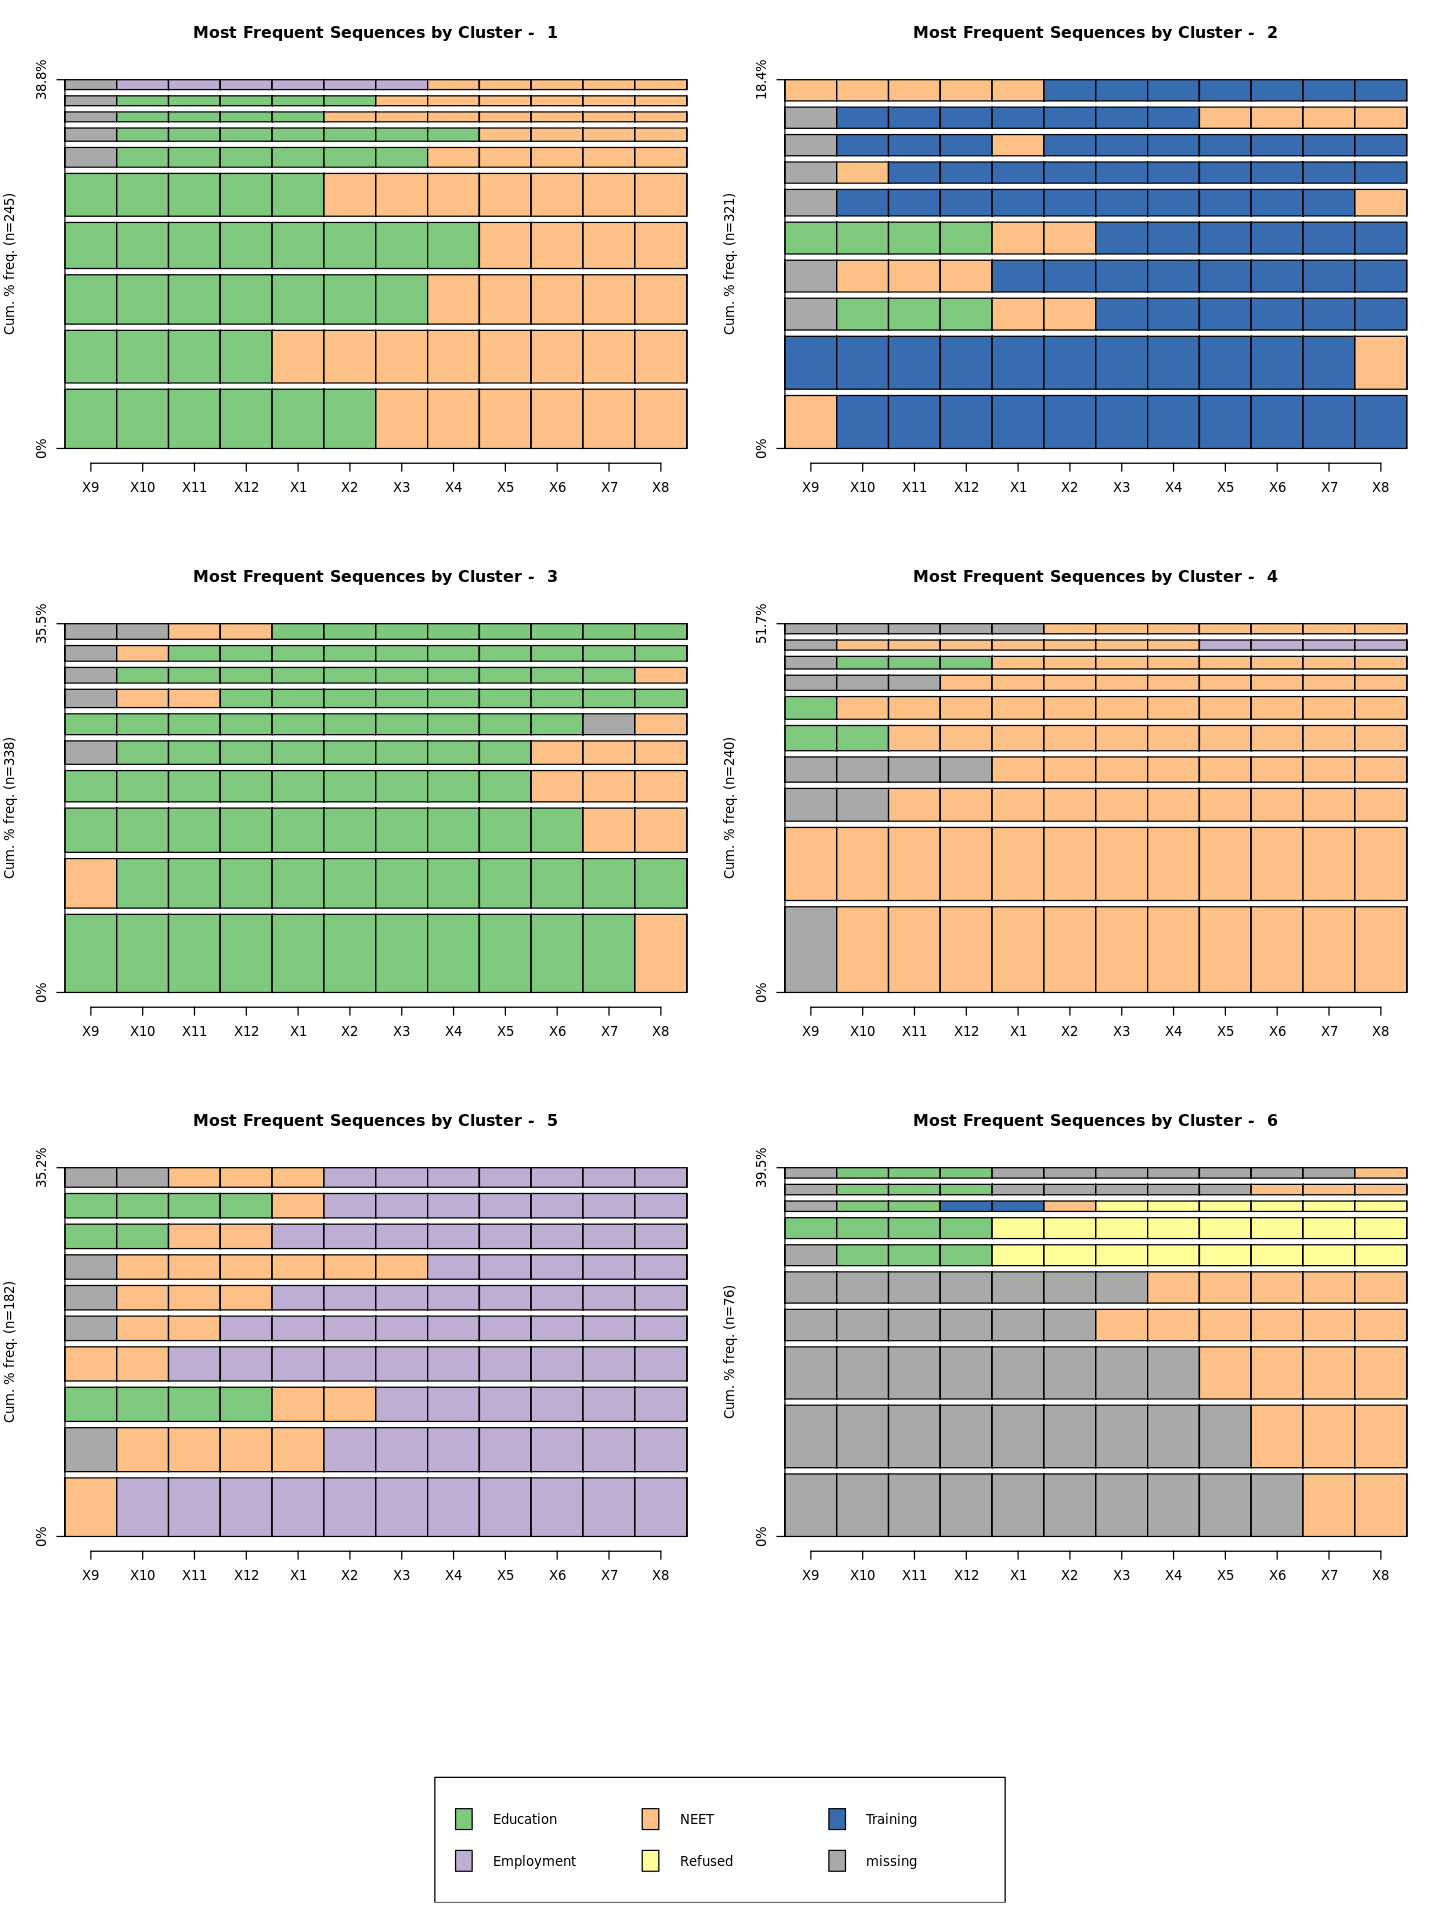

In [99]:
# Plot most frequent sequences per cluster
seqfplot(destinations_seq.seq, group = pam_cluster$clustering, 
         with.legend = TRUE, main = "Most Frequent Sequences by Cluster")

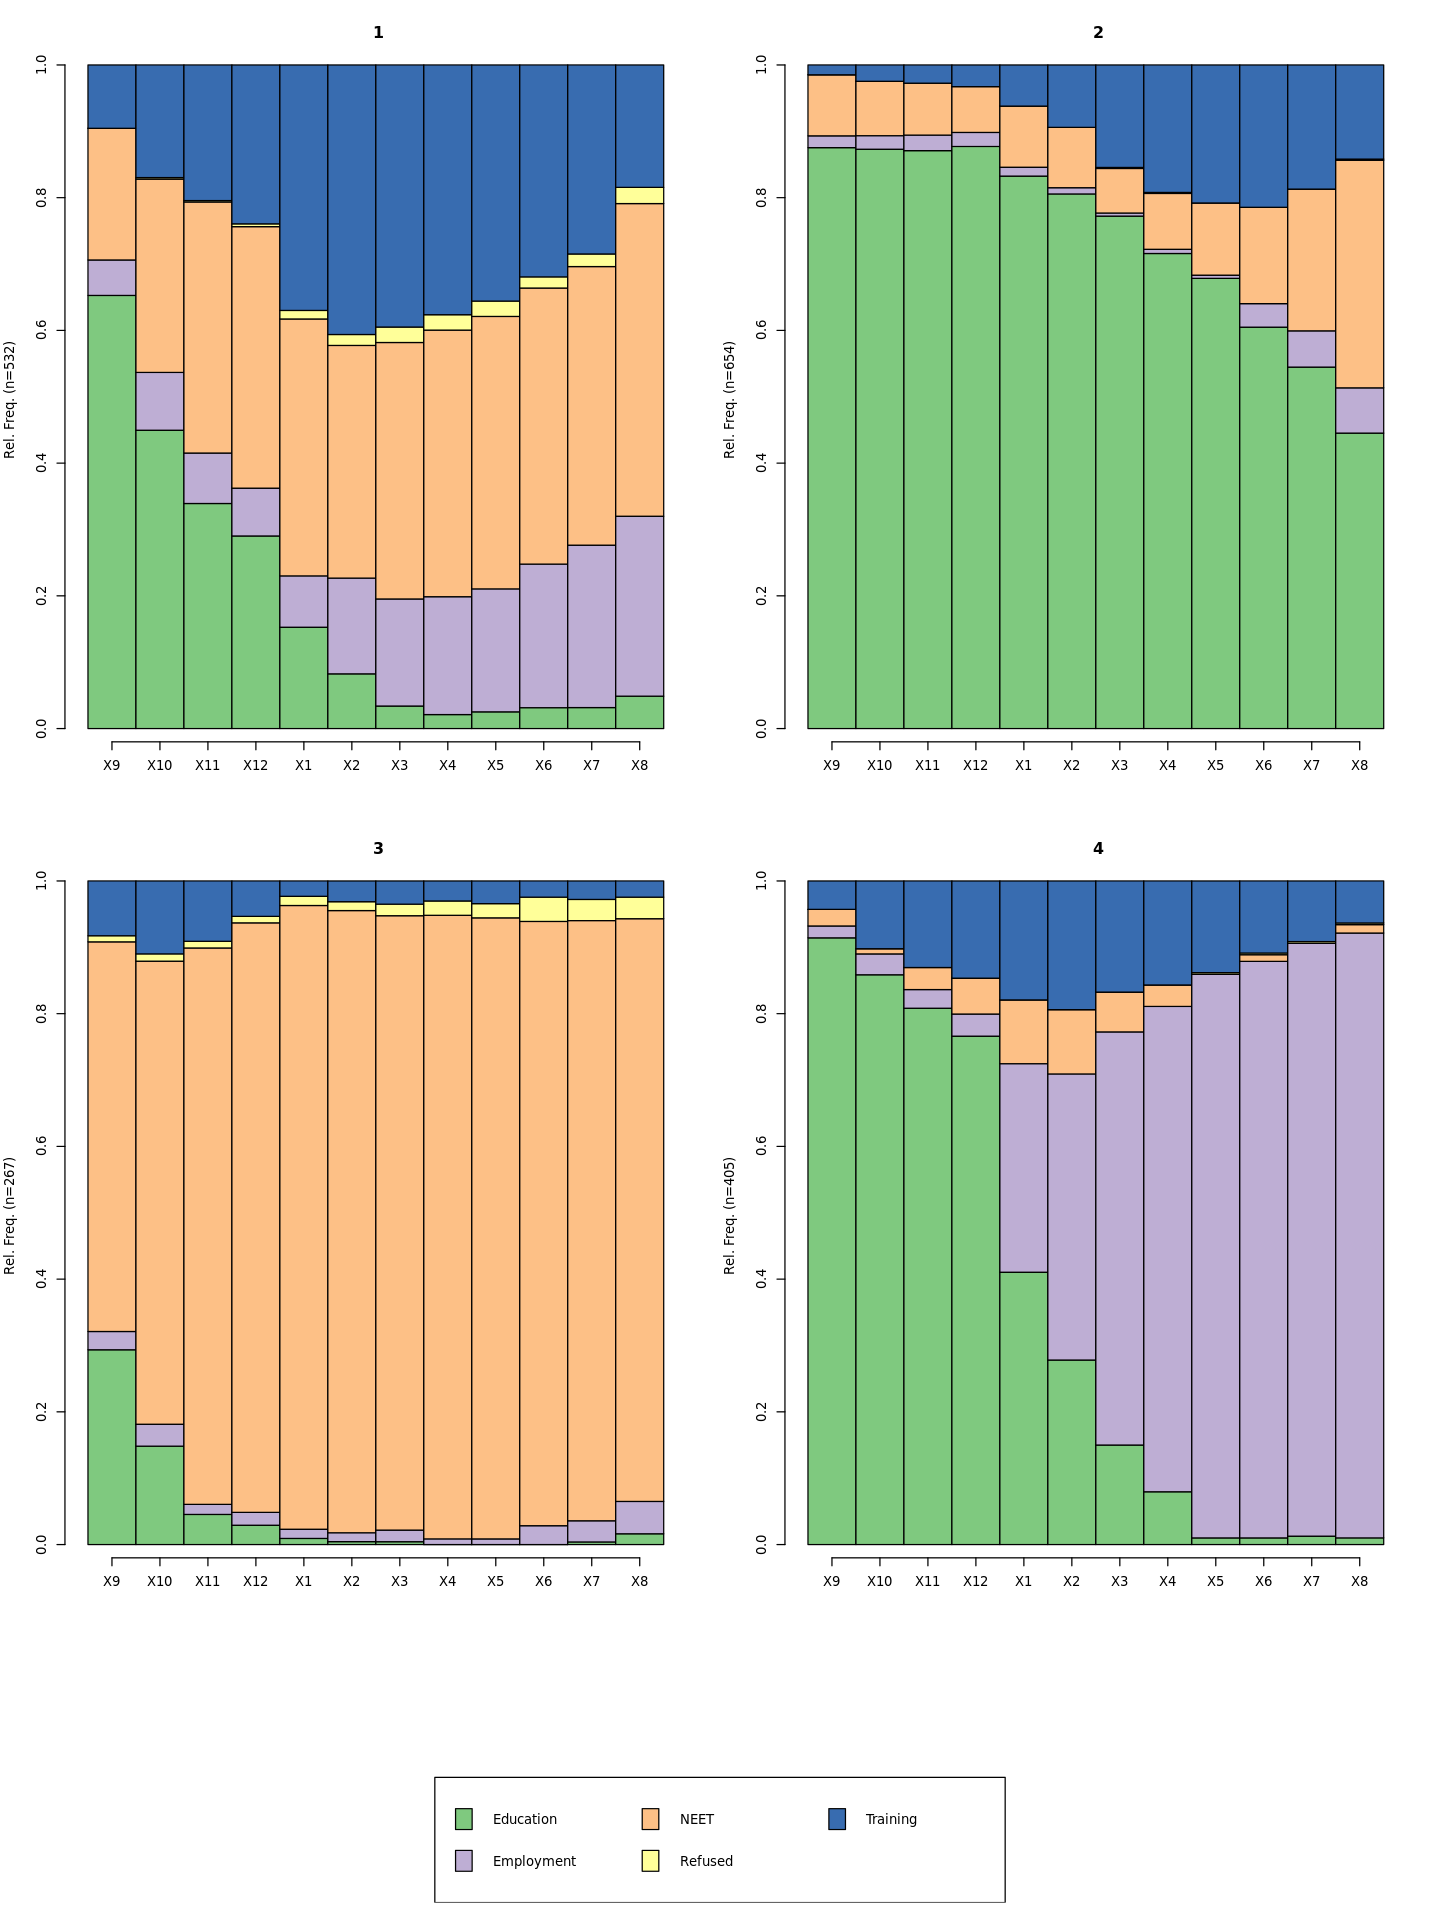

In [64]:
# Plot state distribution per cluster
seqdplot(destinations_seq.seq, group = pam_cluster$clustering)

#### CLARA

In [55]:
# Run CLARA with 4 clusters and 50 samples
set.seed(123)  # For reproducibility
clara_cluster <- clara(
  destinations_seq.om,   # Dissimilarity matrix from seqdist()
  k = 2,                 # Number of clusters
  samples = 50,          # Number of random samples to draw
  pamLike = TRUE         # Uses PAM for each sample
)

In [56]:
# Check the cluster assignment
head(clara_cluster$clustering)

1 2 3 4 5 6 
1 2 1 1 2 1

In [57]:
clara_cluster$clusinfo

size,max_diss,av_diss,isolation
1376,282.3030,152.4255,0.7915166
482,411.7171,162.0322,1.1543658


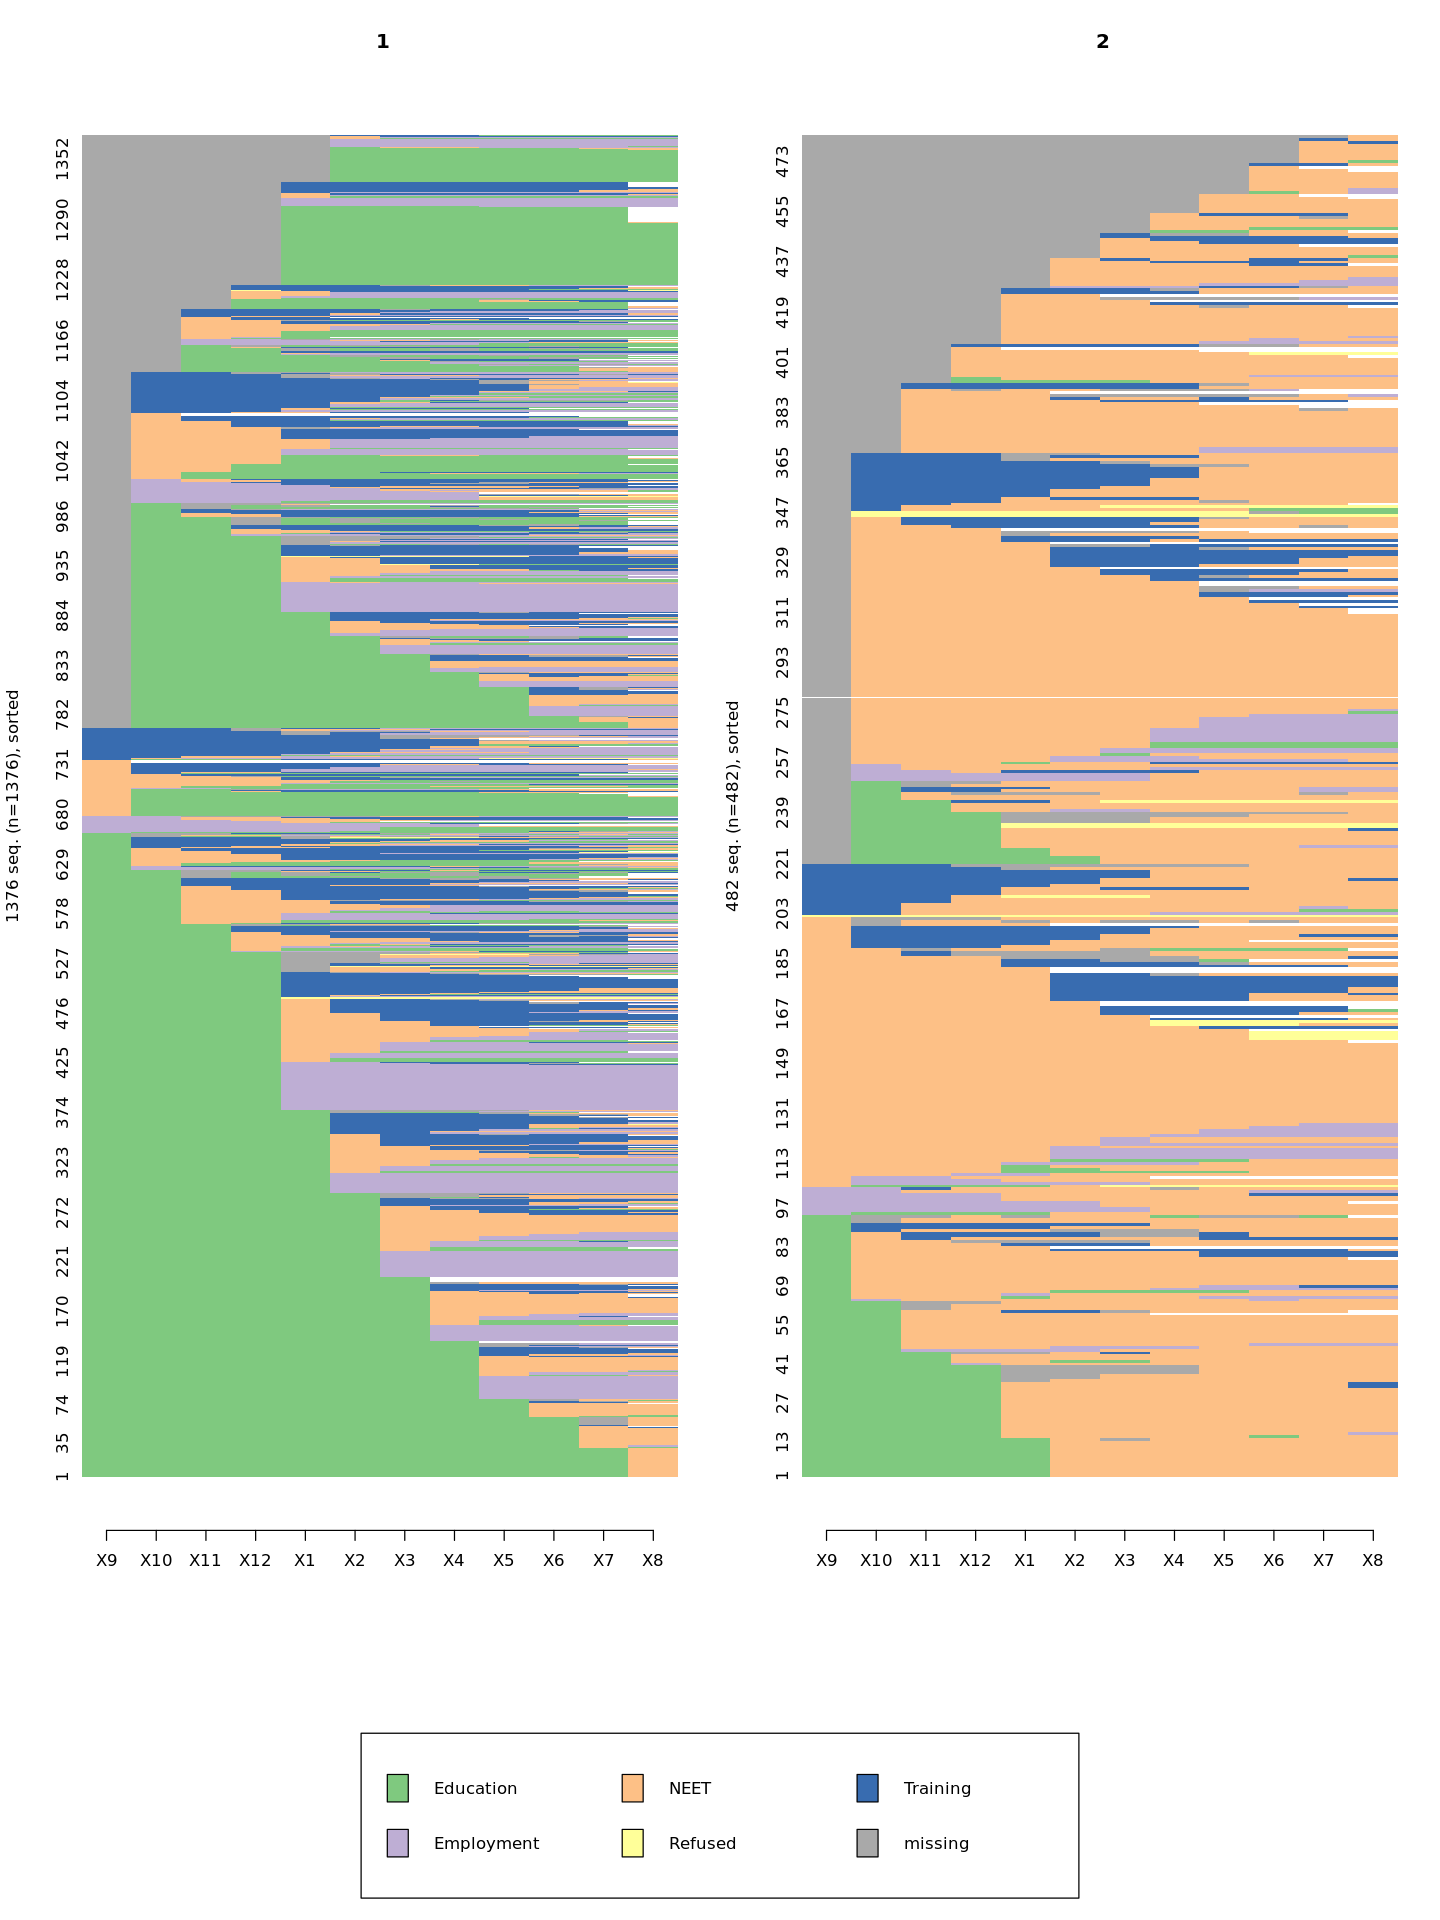

In [58]:
options(repr.plot.width = 12, repr.plot.height = 16)
# Plot individual trajectories per cluster
seqIplot(destinations_seq.seq, group = clara_cluster$clustering, sortv = "from.start")

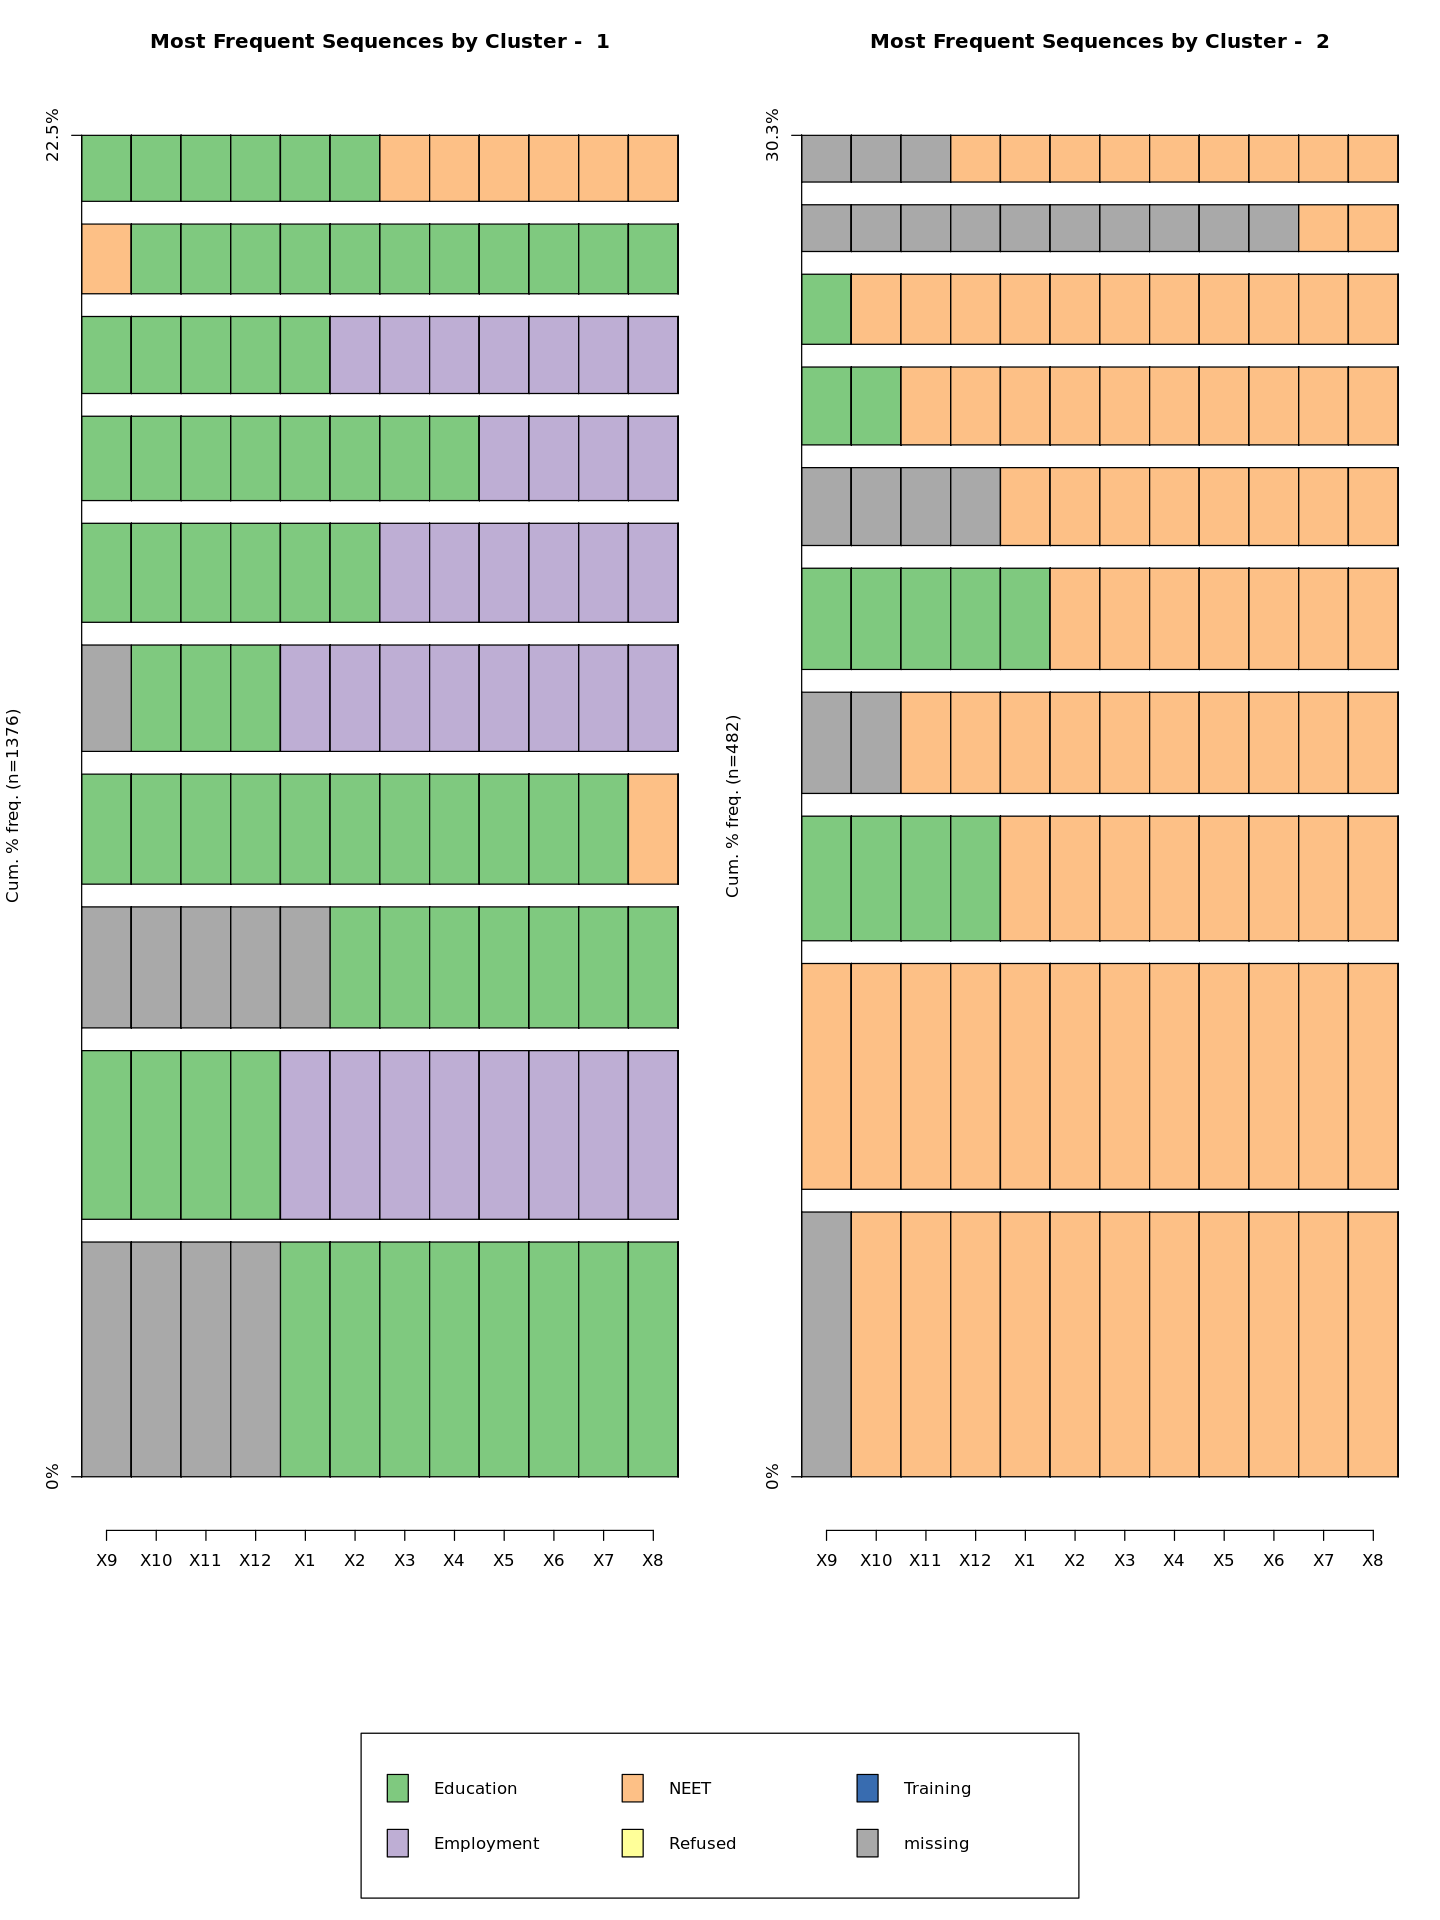

In [65]:
# Plot most frequent sequences per cluster
seqfplot(destinations_seq.seq, group = clara_cluster$clustering, 
         with.legend = TRUE, main = "Most Frequent Sequences by Cluster")

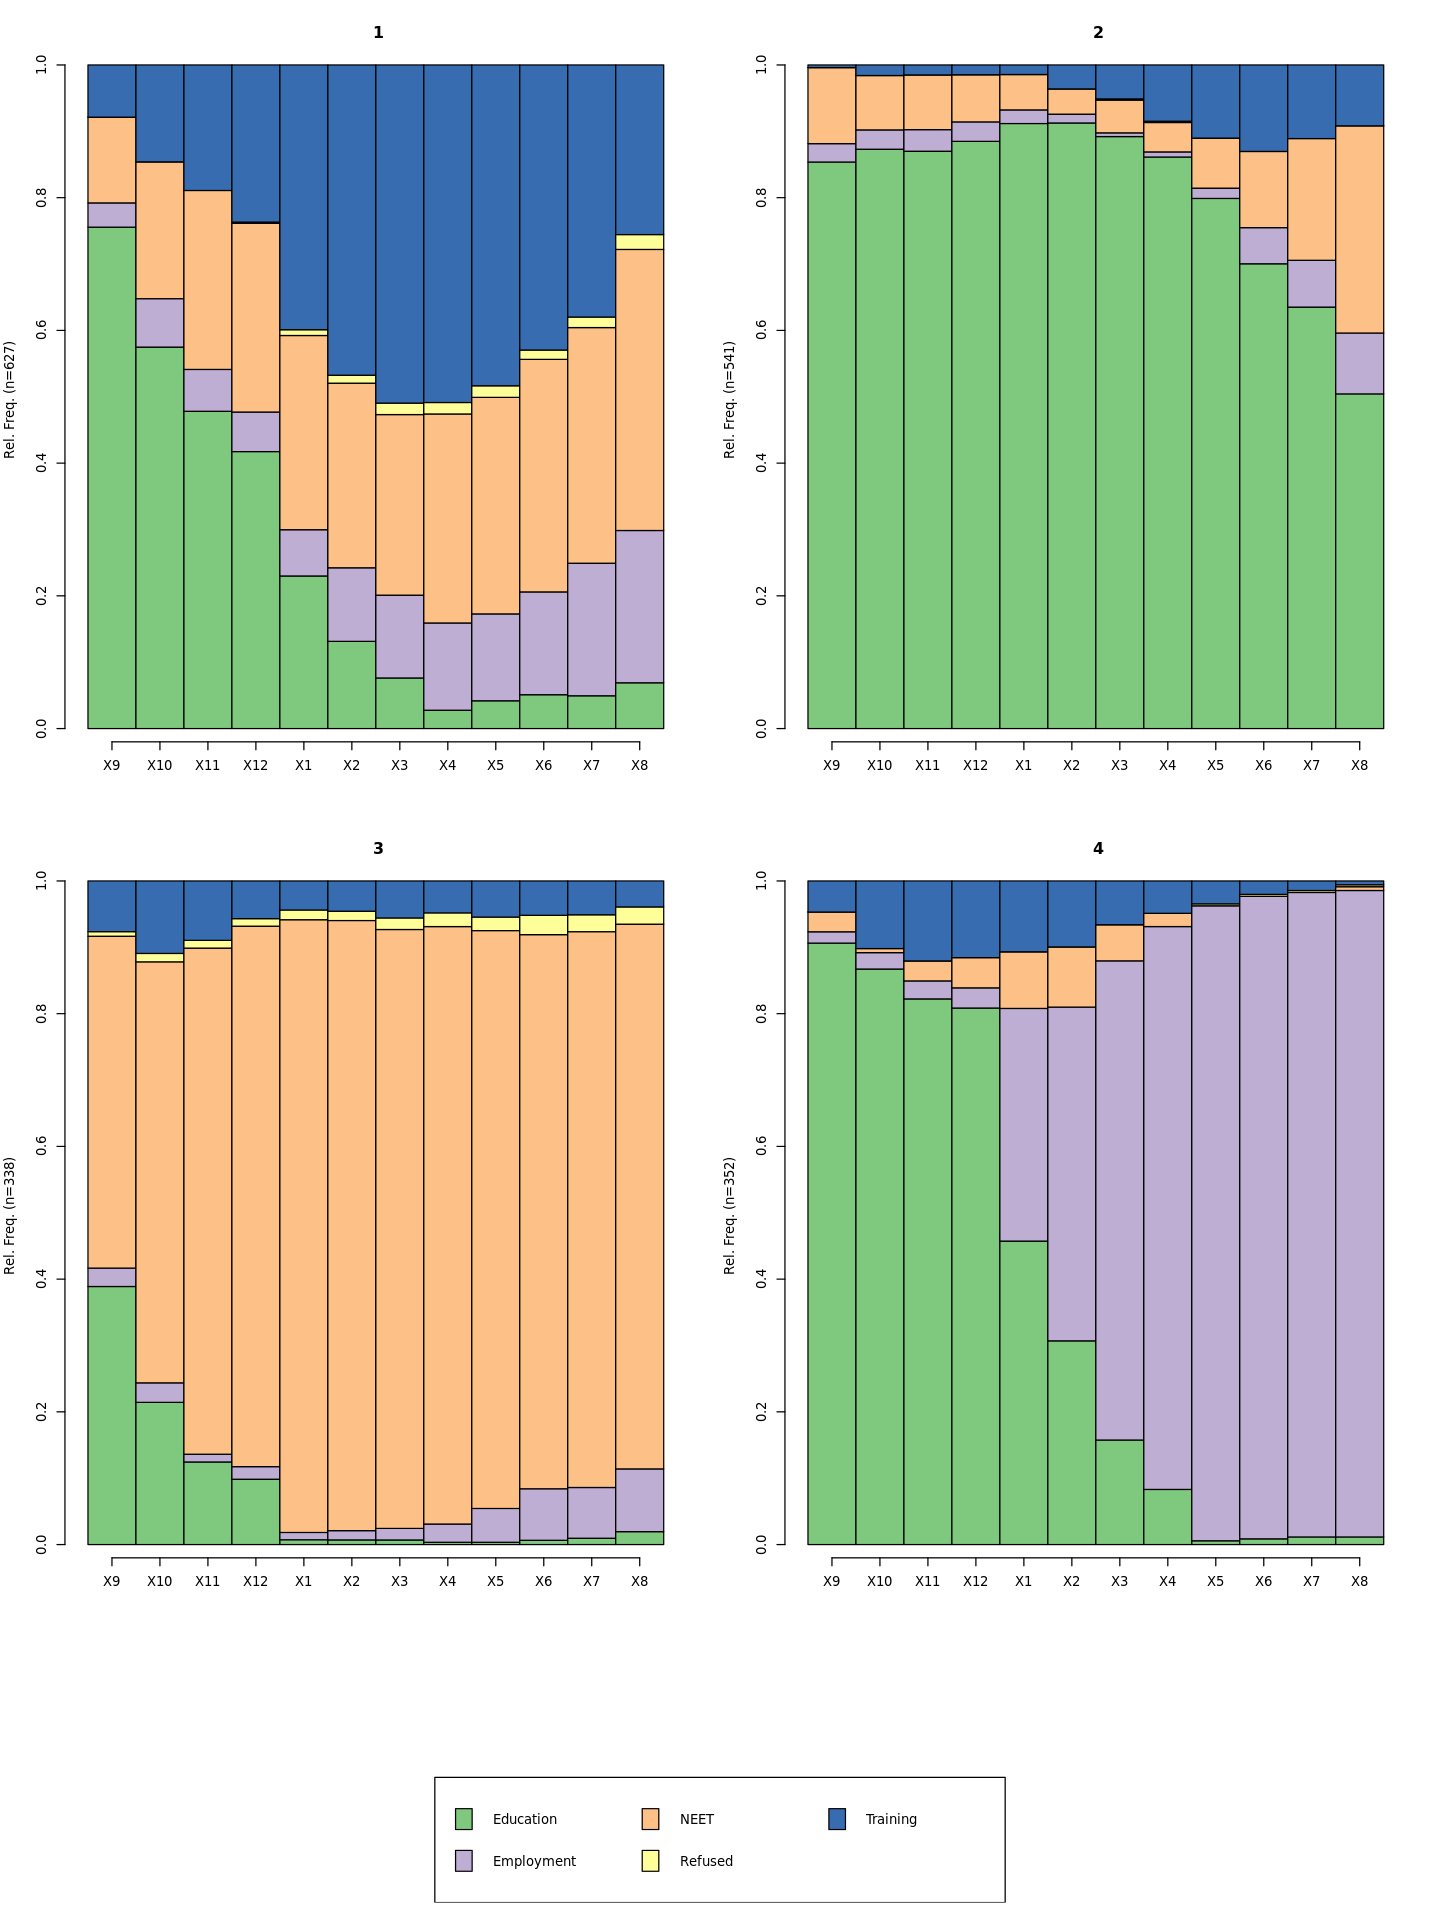

In [54]:
# Plot state distribution per cluster
seqdplot(destinations_seq.seq, group = clara_cluster$clustering)

In [36]:
# Get medoids (representative sequences for each cluster)
clara_cluster$medoids

,1,2,3,4,5,6,7,8,9,10,⋯,8677,8678,8679,8680,8681,8682,8683,8684,8685,8686
8686,0,0,3,0,1,0,0,0,1,1,⋯,0,6,1,14,4,14,13,1,0,0
6956,3,3,0,3,2,3,3,3,2,2,⋯,3,3,2,11,1,11,11,2,3,3
8661,1,1,2,1,0,1,1,1,0,0,⋯,1,5,0,13,3,13,12,0,1,1
1586,16,16,13,16,15,16,16,16,15,15,⋯,16,12,15,9,12,6,15,15,16,16
8472,2,2,1,2,1,2,2,2,1,1,⋯,2,4,1,12,2,12,11,1,2,2
1846,5,5,2,5,4,5,5,5,4,4,⋯,5,1,4,12,1,11,12,4,5,5
1775,13,13,11,13,12,13,13,13,12,12,⋯,13,13,12,12,12,12,0,12,13,13
6961,24,24,21,24,23,24,24,24,23,23,⋯,24,18,23,20,20,17,22,23,24,24
3864,8,8,7,8,7,8,8,8,7,7,⋯,8,9,7,14,8,12,10,7,8,8


In [37]:
# Get cluster assignments
cluster_labels <- clara_cluster$clustering

In [38]:
# Add cluster assignments to the original dataset
destinations_counts_cut$cluster <- cluster_labels

In [39]:
head(destinations_counts_cut)

,person_id,NCCIS_ACADYR,Intended_destination,X9,X10,X11,X12,X1,X2,X3,X4,X5,X6,X7,X8,cluster
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,1
2,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,1
3,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA,2
4,0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,1
5,001B7CEB7B4CC529920A0B9F5B83D1AC0019E5DC44B3FBB3CEF665C331C0C3B6,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA,3
6,001E539C263734CC355646811C93CF85B0C587D2EBA8B0D79290FDE8A75D6267,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,1


In [40]:
write.csv(destinations_counts_cut, "data/destinations_counts_cut.csv", row.names = FALSE)

In [51]:
destinations_seq |>
    filter(if_all(`9`:`8`, ~ . == "Education")) |>
    nrow()

[1] 6080

In [44]:
destinations_seq |>
    filter(if_all(`9`:`8`, ~ . == "Education" | is.na(.))) |>
    nrow()

[1] 14555

In [45]:
# drop all Edu
destinations_seq <- destinations_seq |>
    rowwise() |>
    mutate(edu_count = sum(str_starts(c_across(`9`:`8`), "Edu"), na.rm = TRUE)) |>
    filter(edu_count <= 11)

In [46]:
destinations_seq |>
    nrow()

[1] 11281

In [48]:
# drop where NA for sep and Edu all others
destinations_seq |>
  rowwise() |>
  filter((is.na(`9`) & if_all(`10`:`8`, ~ . == "Education"))) |>
    nrow()

[1] 1724

In [36]:
# drop where NA for sep and Edu all others
destinations_seq <- destinations_seq |>
  rowwise() |>
  filter(!(is.na(`9`) & if_all(`10`:`8`, ~ . == "Education")))

In [37]:
destinations_seq |>
    nrow()

[1] 6286

# NEET / EET / NA states

In [100]:
head(data)

,person_id,NCCIS_ACADYR,Intended_destination,X9,X10,X11,X12,X1,X2,X3,X4,X5,X6,X7,X8
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
2,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
3,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019,NA,Education,Education,Education,Education,Education,Education,NEET,NEET,NEET,NEET,NEET,NEET
4,0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education
5,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018,NA,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,NA
6,0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education,Education


In [104]:
simple_data <- data |>
  mutate(M9 = case_when(
    X9 %in% c('Education', 'Employment', 'Training') ~ 'EET',
    TRUE ~ X9),
  M10 = case_when(
    X10 %in% c('Education', 'Employment', 'Training') ~ 'EET',
    TRUE ~ X10),
  M11 = case_when(
    X11 %in% c('Education', 'Employment', 'Training') ~ 'EET',
    TRUE ~ X11),
  M12 = case_when(
    X12 %in% c('Education', 'Employment', 'Training') ~ 'EET',
    TRUE ~ X12),
  M1 = case_when(
    X1 %in% c('Education', 'Employment', 'Training') ~ 'EET',
    TRUE ~ X1),
  M2 = case_when(
    X2 %in% c('Education', 'Employment', 'Training') ~ 'EET',
    TRUE ~ X2),
  M3 = case_when(
    X3 %in% c('Education', 'Employment', 'Training') ~ 'EET',
    TRUE ~ X3),
  M4 = case_when(
    X4 %in% c('Education', 'Employment', 'Training') ~ 'EET',
    TRUE ~ X4),
  M5 = case_when(
    X5 %in% c('Education', 'Employment', 'Training') ~ 'EET',
    TRUE ~ X5),
  M6 = case_when(
    X6 %in% c('Education', 'Employment', 'Training') ~ 'EET',
    TRUE ~ X6),
  M7 = case_when(
    X7 %in% c('Education', 'Employment', 'Training') ~ 'EET',
    TRUE ~ X7),
  M8 = case_when(
    X8 %in% c('Education', 'Employment', 'Training') ~ 'EET',
    TRUE ~ X8)) |>
  select(-c(X9, X10, X11, X12, X1, X2, X3, X4, X5, X6, X7, X8))

In [106]:
head(simple_data)

,person_id,NCCIS_ACADYR,Intended_destination,M9,M10,M11,M12,M1,M2,M3,M4,M5,M6,M7,M8
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET
2,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET
3,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019,NA,EET,EET,EET,EET,EET,EET,NEET,NEET,NEET,NEET,NEET,NEET
4,0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019,NA,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET
5,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018,NA,NA,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,NA
6,0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018,NA,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET


#### add activity counts per row

In [108]:
simple_data_counts <- simple_data |>
    rowwise() |>
    mutate(
    EET = sum(c_across(`M9`:`M8`) == "EET", na.rm = TRUE),
    Refused = sum(c_across(`M9`:`M8`) == "Refused", na.rm = TRUE),
    # check starts with 
    NEET = sum(grepl("^NEET", c_across(`M9`:`M8`)), na.rm = TRUE),
    NA_count = sum(is.na(c_across(`M9`:`M8`)))
        ) |>
    ungroup()

In [109]:
head(simple_data_counts)

person_id,NCCIS_ACADYR,Intended_destination,M9,M10,M11,M12,M1,M2,M3,M4,M5,M6,M7,M8,EET,Refused,NEET,NA_count
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,12,0,0,0
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,12,0,0,0
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019,NA,EET,EET,EET,EET,EET,EET,NEET,NEET,NEET,NEET,NEET,NEET,6,0,6,0
0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019,NA,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,12,0,0,0
00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018,NA,NA,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,NA,10,0,0,2
0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018,NA,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,EET,12,0,0,0


#### Extract 'Steady EET' and non-NEET incomplete records

In [110]:
simple_data_counts_labelled <- simple_data_counts |>
    mutate(Label = case_when(
        NEET == 0 & Refused == 0 & NA_count <= 4 ~ 'Steady EET',
        NEET == 0 & Refused == 0 & NA_count >= 5 ~ 'DROP',
        TRUE ~ NA
    )
          )

In [111]:
simple_data_counts_labelled |>
    group_by(Label) |>
    tally()

Label,n
<chr>,<int>
DROP,476
Steady EET,15665
NA,1402


In [112]:
simple_data_counts_cut <- simple_data_counts_labelled |>
    filter(is.na(Label))

In [113]:
simple_data_counts_cut |>
    nrow()

[1] 1402

#### Find optimal K

In [114]:
# create a state sequence object from the status variables (columns 17 to 86)
# with missing TRUE treats missing values as a state
destinations_seq.seq <- seqdef(simple_data_counts_cut, 4:15, with.missing = TRUE)

 [>] found missing values ('NA') in sequence data

 [>] preparing 1402 sequences

 [>] coding void elements with '%' and missing values with '*'

 [>] 3 distinct states appear in the data: 

     1 = EET

     2 = NEET

     3 = Refused

 [>] state coding:

       [alphabet]  [label]  [long label] 

     1  EET         EET      EET

     2  NEET        NEET     NEET

     3  Refused     Refused  Refused

 [>] 1402 sequences in the data set

 [>] min/max sequence length: 1/12



In [115]:
options(repr.plot.width = 12, repr.plot.height = 10)

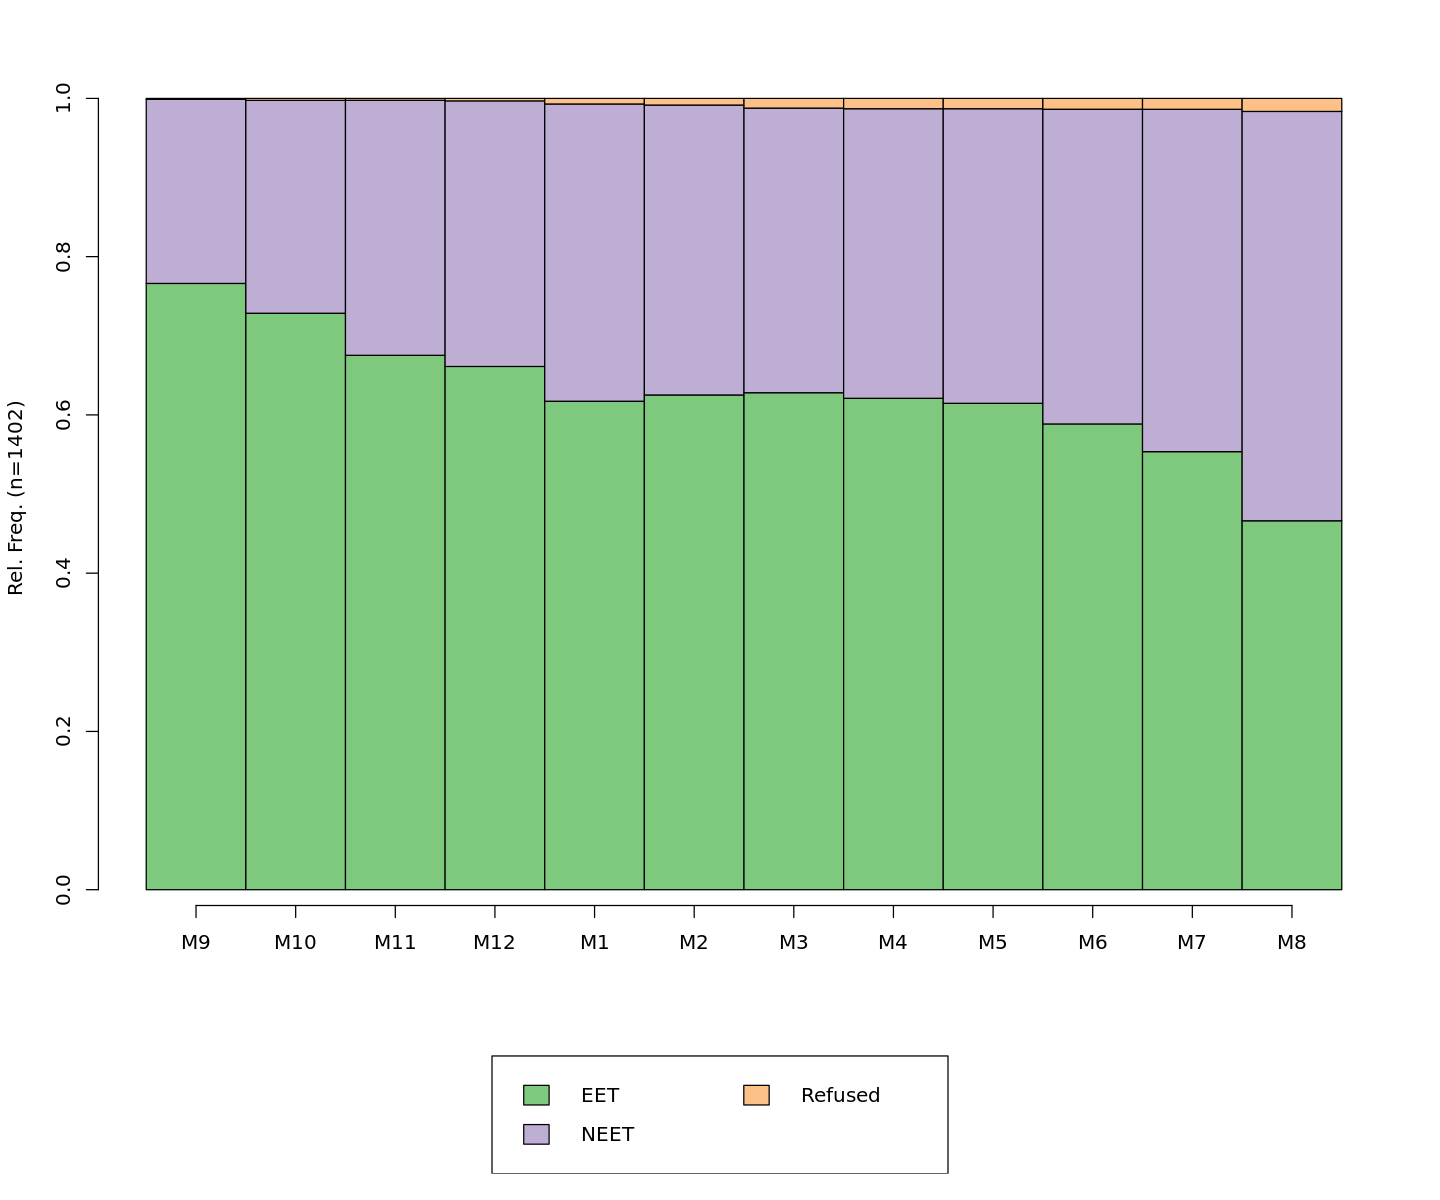

In [116]:
seqdplot(destinations_seq.seq)

In [118]:
# compute pairwise optimal matching (OM) distances 
destinations_seq.om <- seqdist(destinations_seq.seq, method = "OM", indel = 1, with.missing = TRUE, sm = "TRATE")

 [>] including missing values as an additional state

 [>] 1402 sequences with 4 distinct states

 [>] Computing sm with seqcost using  TRATE

 [>] creating substitution-cost matrix using transition rates ...

 [>] computing transition probabilities for states EET/NEET/Refused/* ...

 [>] 541 distinct  sequences 

 [>] min/max sequence lengths: 1/12

 [>] computing distances using the OM metric

 [>] elapsed time: 0.267 secs



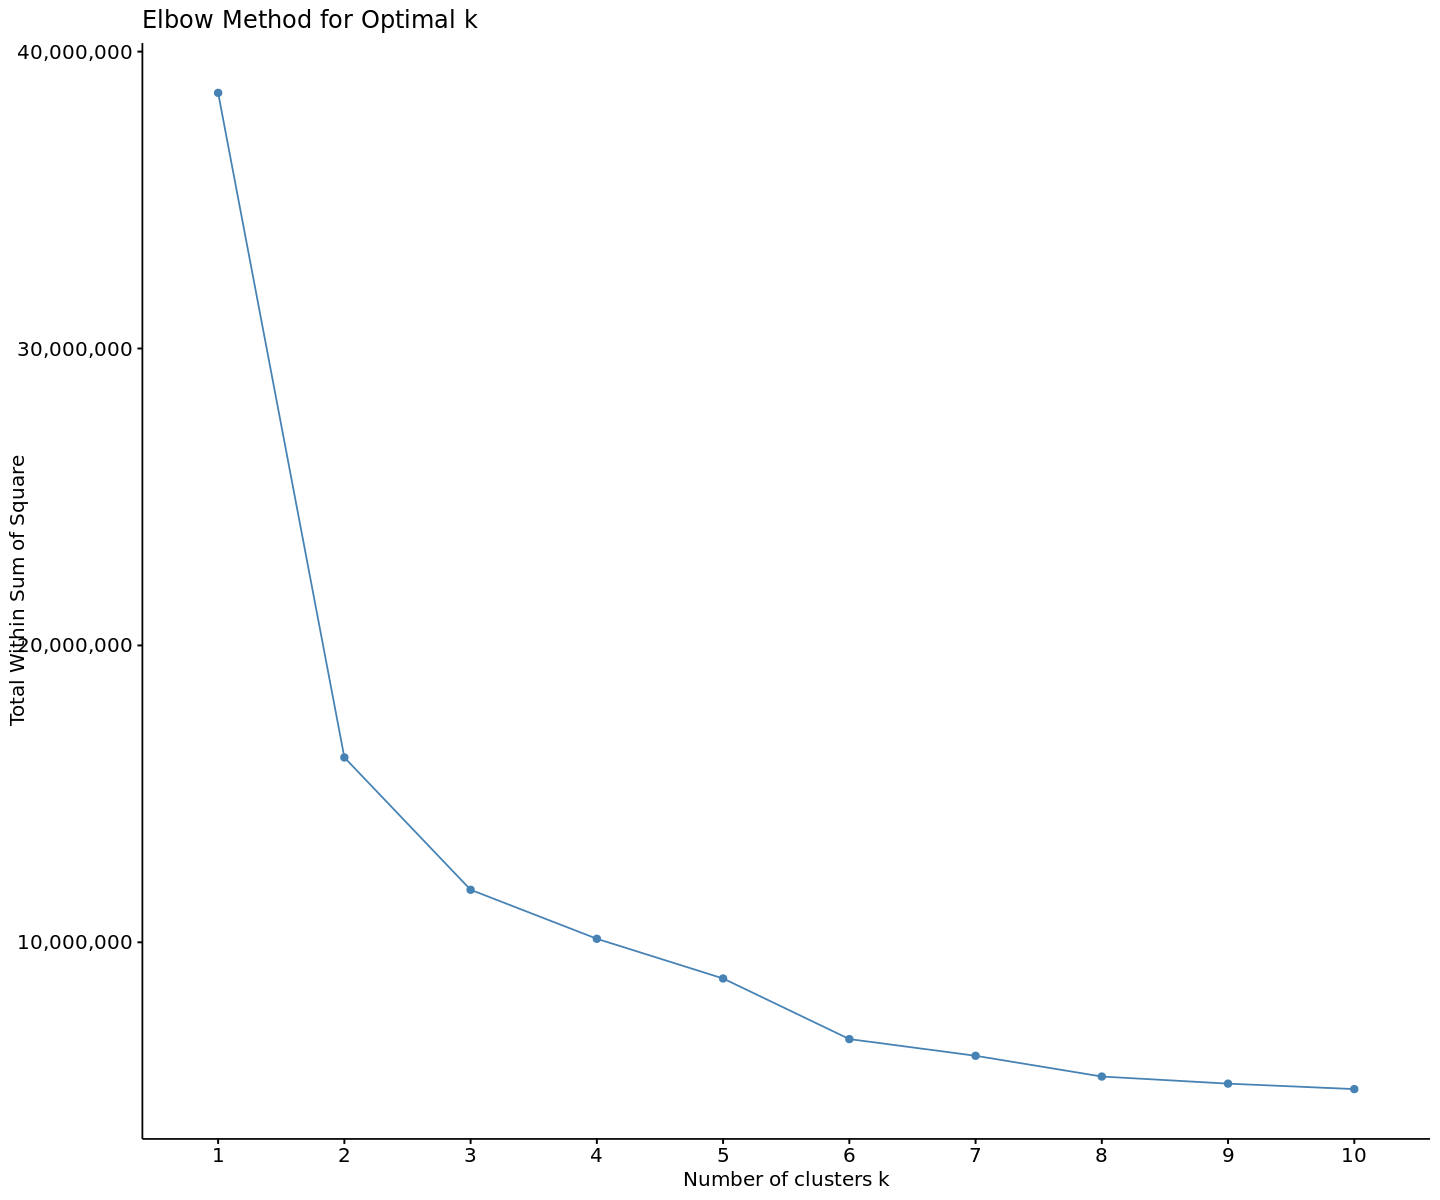

In [119]:
# Compute and plot WCSS (Within-cluster sum of squares) for different k
fviz_nbclust(destinations_seq.om, pam, method = "wss") +
  ggtitle("Elbow Method for Optimal k") +
  scale_y_continuous(labels = comma)

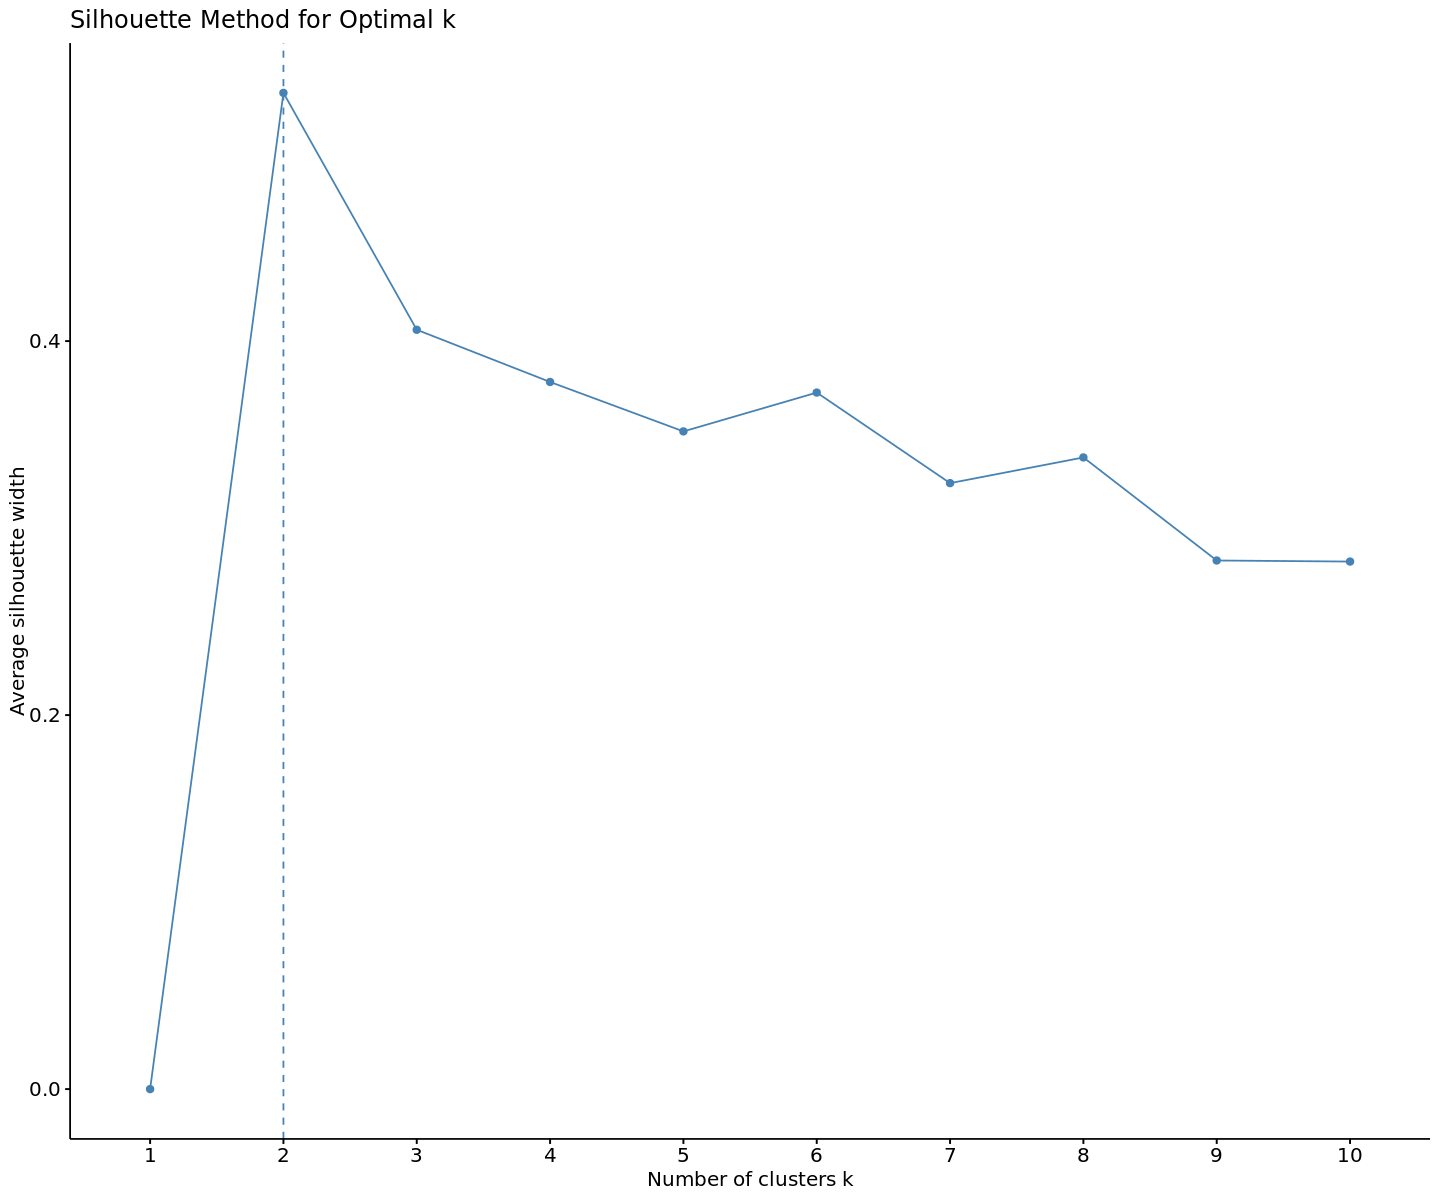

In [120]:
# Silhouette method to find optimal k (A higher average silhouette width suggests a better-defined clustering)
fviz_nbclust(destinations_seq.om, pam, method = "silhouette") +
  ggtitle("Silhouette Method for Optimal k")

#### PAM clustering

In [121]:
set.seed(123)
pam_cluster <- pam(destinations_seq.om, k = 3)

In [122]:
pam_cluster$clusinfo

size,max_diss,av_diss,diameter,separation
428,238.5242,105.68929,280.2691,30.5579
695,158.6711,70.68054,183.6777,32.7073
279,425.1946,112.36134,506.9458,30.5579


In [127]:
options(repr.plot.width = 12, repr.plot.height = 12)

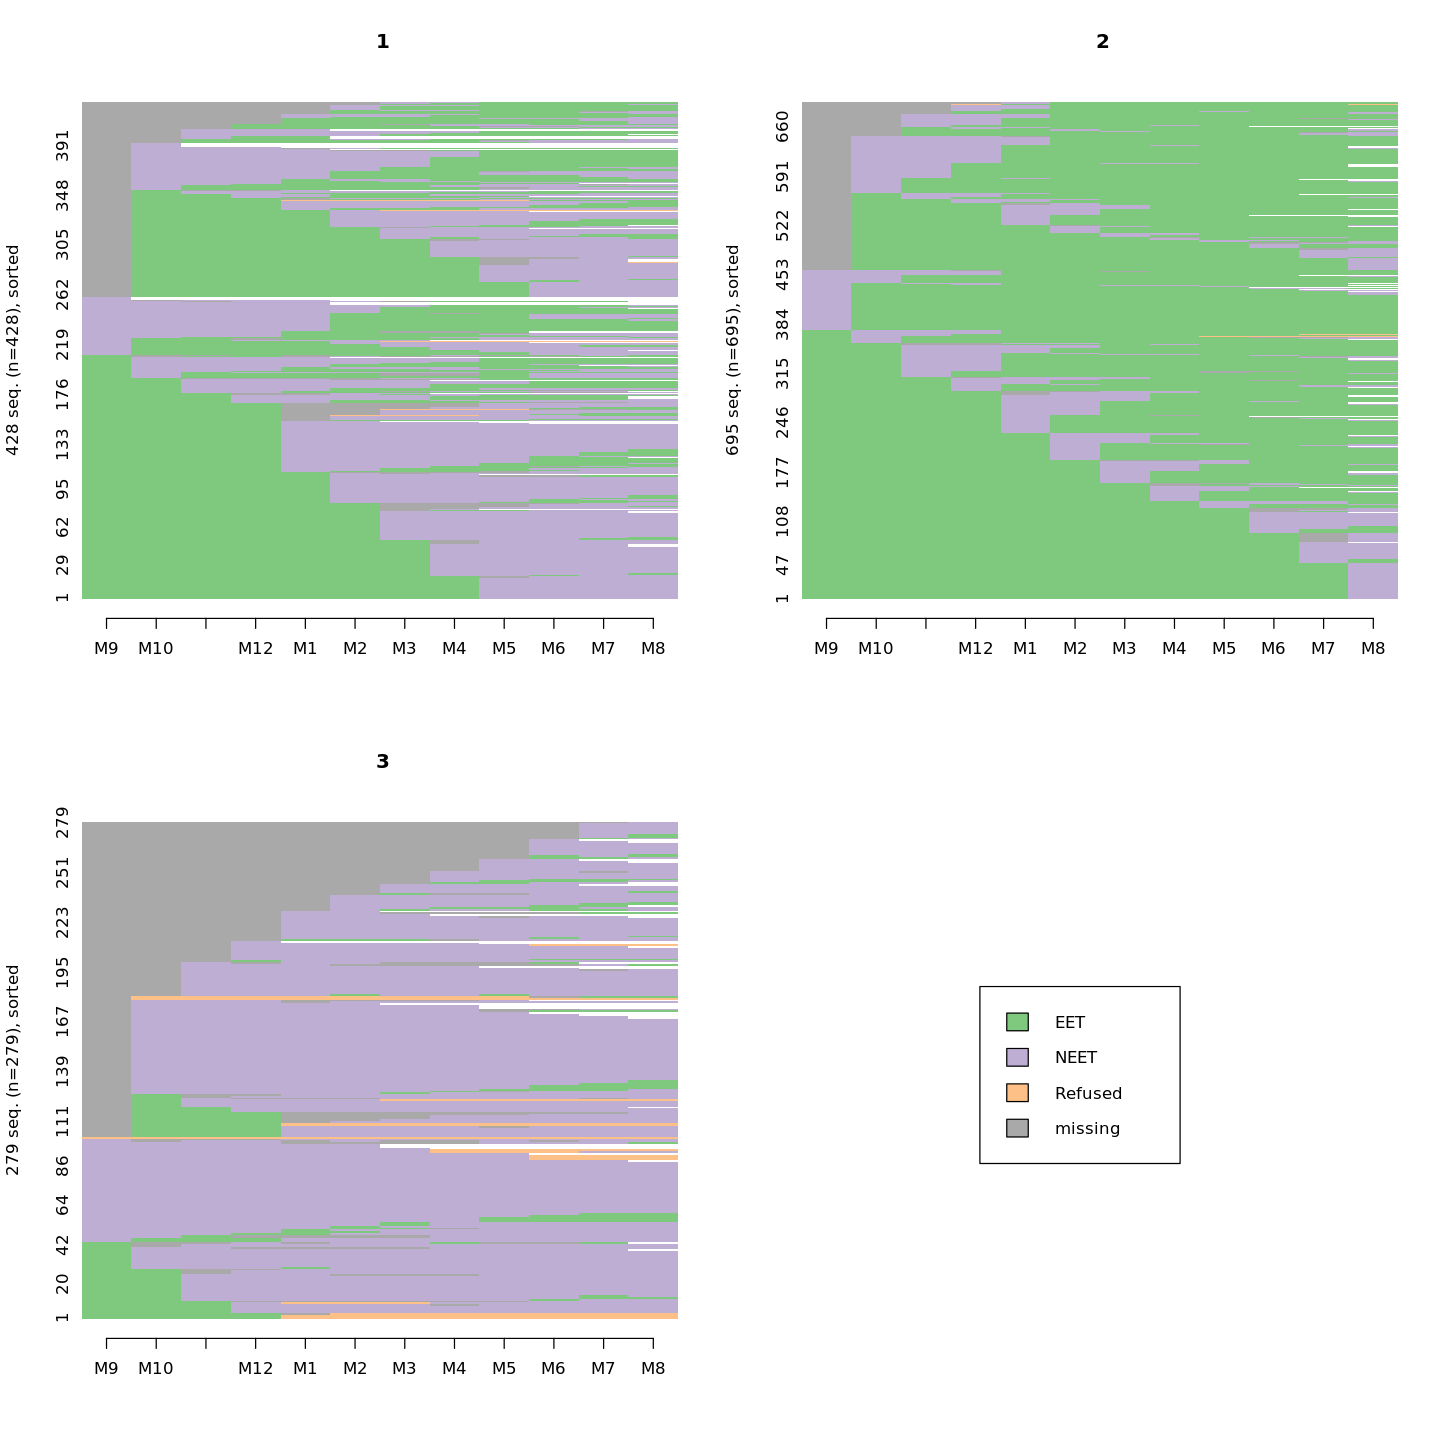

In [128]:
# Plot individual trajectories per cluster
seqIplot(destinations_seq.seq, group = pam_cluster$clustering, sortv = "from.start")

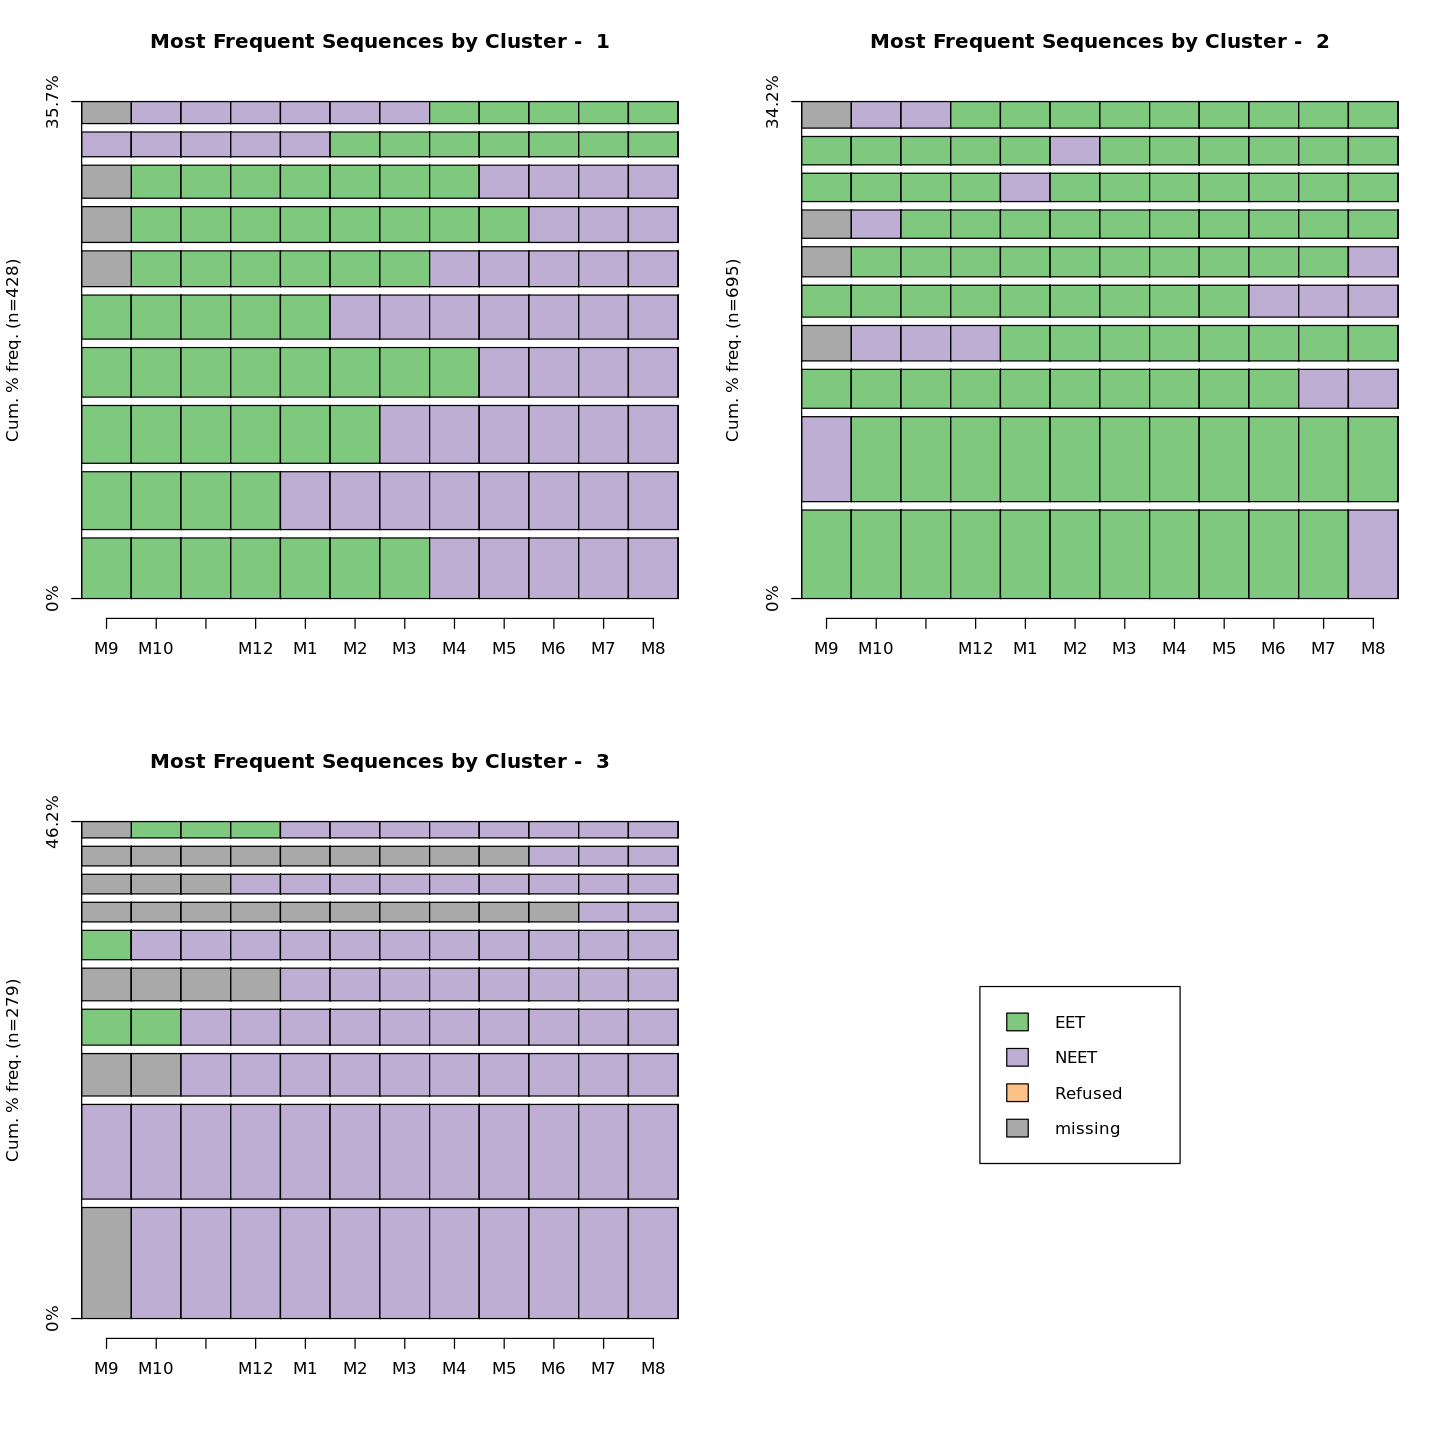

In [129]:
# Plot most frequent sequences per cluster
seqfplot(destinations_seq.seq, group = pam_cluster$clustering, 
         with.legend = TRUE, main = "Most Frequent Sequences by Cluster")

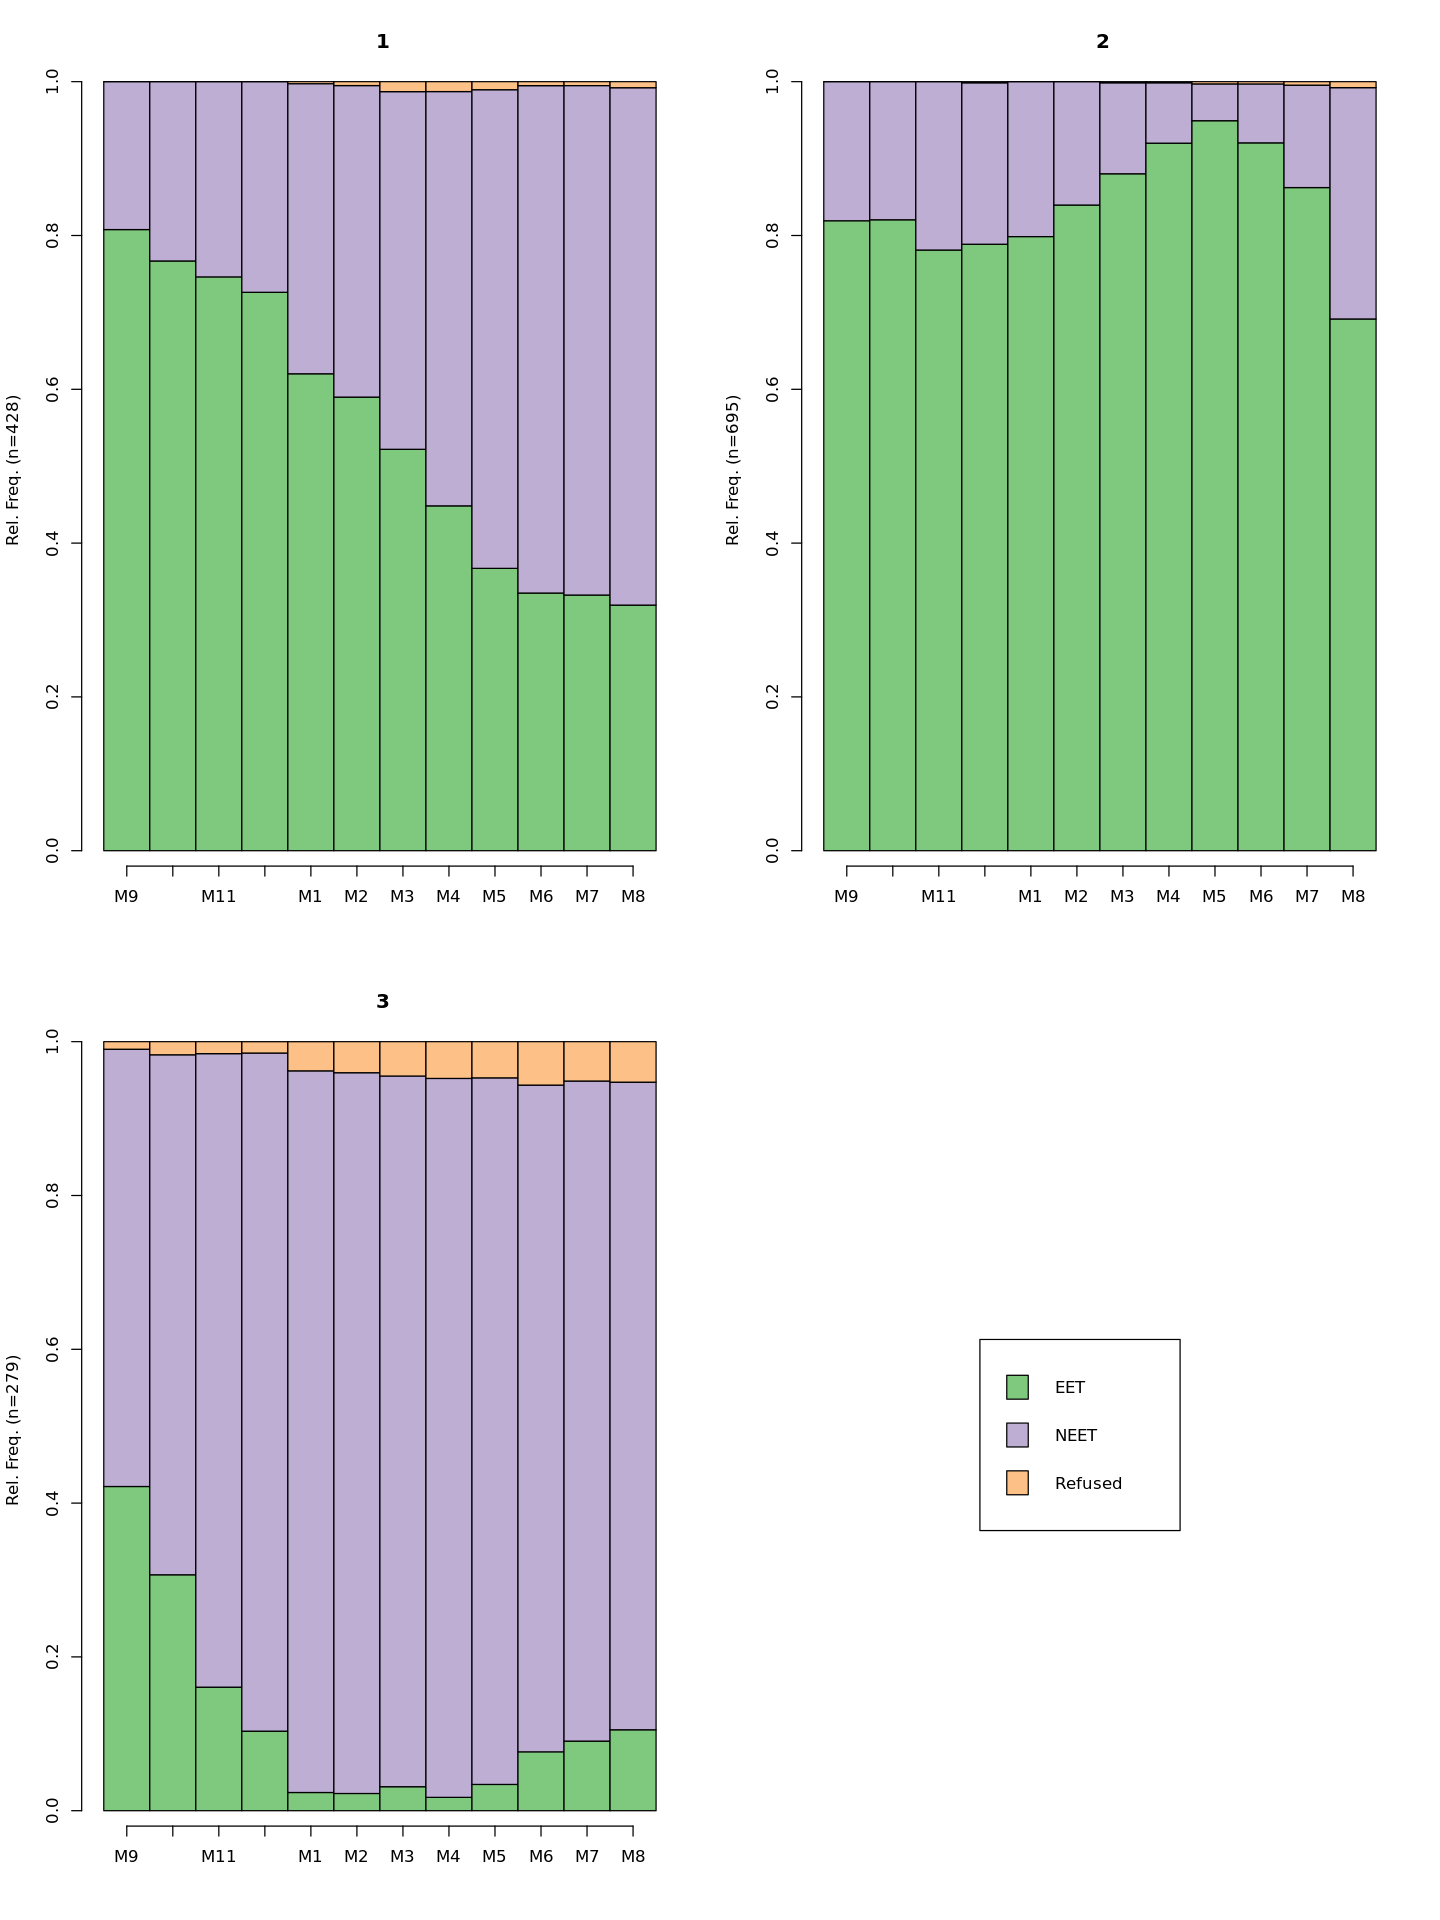

In [126]:
# Plot state distribution per cluster
seqdplot(destinations_seq.seq, group = pam_cluster$clustering)